# Import Statements

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
import pickle
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
from math import sqrt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from statistics import mean
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
import xgboost as xgb
import shap
from math import sqrt
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import plot_importance
from matplotlib import pyplot

/home/supadhyaya/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


# Define all functions

In [30]:
class EarlyStopping:
    def __init__(self, patience=10, delta=1e-4):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

In [31]:
def build_model(input_size, params):
    layers = []
    layers.append(nn.Linear(input_size, params['hidden_size1']))
    layers.append(nn.ReLU())
    layers.append(nn.Dropout(params['dropout1']))

    if params['n_layers'] > 1:
        layers.append(nn.Linear(params['hidden_size1'], params['hidden_size2']))
        layers.append(nn.ReLU())
        # Only add dropout2 if n_layers > 2
        if params['n_layers'] > 2:
            layers.append(nn.Dropout(params['dropout2']))

    if params['n_layers'] > 2:
        layers.append(nn.Linear(params['hidden_size2'], params['hidden_size3']))
        layers.append(nn.ReLU())

    # Output layer
    last_hidden = f"hidden_size{params['n_layers']}"
    layers.append(nn.Linear(params[last_hidden], 1))

    return nn.Sequential(*layers)

In [26]:
def objective(trial):
    #Hyperparametr space
    params = {
            'hidden_size1': trial.suggest_categorical('hidden_size1', [100, 200, 300]),
            #'hidden_size1': trial.suggest_int('hidden_size1', 64, 256, step=32),
            #'hidden_size2': trial.suggest_int('hidden_size2', 32, 128, step=16),
            #'hidden_size3': trial.suggest_int('hidden_size3', 32, 128, step=16),
            'dropout1': trial.suggest_float('dropout1', 0.01, 0.1),
            #'dropout2': trial.suggest_float('dropout2', 0.01, 0.1),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128]),
            'optimizer': trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD']),
            #'num_epochs': trial.suggest_categorical('num_epochs', [30, 50, 70]),
            #'patience': trial.suggest_int('patience', 5, 15),
            'num_epochs': 100,
            'patience': 10,
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True),
            'n_layers': trial.suggest_int('n_layers', 1, 3)
        }

        # Only sample hidden_size2 if n_layers > 1
    if params['n_layers'] > 1:
        params['hidden_size2'] = trial.suggest_categorical('hidden_size2', [50, 100, 150])
    else:
        params['hidden_size2'] = None
    
    # Only sample hidden_size3 and dropout2 if n_layers > 2
    if params['n_layers'] > 2:
        params['hidden_size3'] = trial.suggest_categorical('hidden_size3', [25, 50, 75])
        params['dropout2'] = trial.suggest_float('dropout2', 0.01, 0.1)
    else:
        params['hidden_size3'] = None
        params['dropout2'] = None
        
    # Build model
    model = build_model(X_train.shape[1], params).to(device)
    optimizer = getattr(optim, params['optimizer'])(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay']
    )
    loss_function = nn.MSELoss()
    early_stopping = EarlyStopping(patience=params['patience'])

    # Prepare data
    #X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    #y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    #X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    #y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)

    val_losses = []

    for epoch in range(params['num_epochs']):
        # Training
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = loss_function(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Validation (after each epoch)
        model.eval()
        with torch.no_grad():
            preds = model(X_val).cpu().numpy()
            true = y_val.cpu().numpy()
            val_loss = loss_function(torch.tensor(preds), y_val.cpu())
            val_losses.append(val_loss.item())

        avg_val_loss = np.mean(val_losses[-5:])  # average of last 5 epochs for stability
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    mse = mean_squared_error(true, preds)
    return mse  # Optuna tries to minimize this value



In [27]:
def complete_params(params):
    params = dict(params) 
    params.setdefault('num_epochs', 100)
    params.setdefault('patience', 10)
    return params

In [7]:
def cross_validate(X, y, best_params, n_splits, checkpoint_path='best_model_checkpoint.pth'):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_losses = []
    best_model_weights = None
    best_loss = float('inf')
    fold = 1

    for train, test in kf.split(X, y):
        print(f"Training fold {fold}")

        model = build_model(X.shape[1], best_params).to(device)
        lr = best_params.get('lr', 0.001)
        opt_name = best_params.get('optimizer', 'Adam')

        if opt_name == 'Adam':
            optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=best_params.get('weight_decay', 0.0))
        elif opt_name == 'SGD':
            optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=best_params.get('weight_decay', 0.0))
        elif opt_name == 'RMSprop':
            optimizer = optim.RMSprop(model.parameters(), lr=lr, weight_decay=best_params.get('weight_decay', 0.0))
        else:
            raise ValueError(f"Unsupported optimizer: {opt_name}")

        loss_fn = nn.MSELoss()
        patience = best_params.get('patience', 10)
        early_stopping_counter = 0
        best_val_loss = float('inf')

        train_dataset = torch.utils.data.TensorDataset(X[train], y[train])
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)

        # Validation data for this fold
        X_val = X[test].to(device)
        y_val = y[test].to(device)

        for epoch in range(best_params['num_epochs']):
            model.train()
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                optimizer.zero_grad()
                outputs = model(batch_X)
                loss = loss_fn(outputs, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            model.eval()
            with torch.no_grad():
                val_output = model(X_val)
                val_loss = loss_fn(val_output, y_val)
                val_loss_value = val_loss.item()
                #print(f"Fold {fold} Epoch {epoch+1} validation loss: {val_loss_value:.4f}")

                if val_loss_value < best_val_loss - 1e-6:
                    best_val_loss = val_loss_value
                    early_stopping_counter = 0
                    # Save the best model weights for this fold
                    best_fold_weights = model.state_dict()
                else:
                    early_stopping_counter += 1

                if early_stopping_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1} for fold {fold}")
                    break
                
        print(f"Fold {fold} validation loss: {best_val_loss:.4f}")
        fold_losses.append(best_val_loss)
        # Save the best model weights across all folds
        if best_val_loss < best_loss:
            best_loss = best_val_loss
            best_model_weights = best_fold_weights

        fold += 1

    average_val_loss = np.mean(fold_losses)
    print(f"\nAverage validation loss across all folds: {average_val_loss:.4f}")

    final_model = build_model(X.shape[1], best_params)
    final_model.load_state_dict(best_model_weights)

    checkpoint = {
        'model_state_dict': final_model.state_dict(),
        'best_params': best_params,
        'input_dim': X.shape[1]
    }
    torch.save(checkpoint, checkpoint_path)
    print(f"Checkpoint saved as '{checkpoint_path}'.")

    return final_model, average_val_loss


In [8]:
# Evaluation
def evaluate_on_holdout(X_holdout, y_holdout, best_model):
    # Prepare the data
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    X_holdout_tensor = torch.tensor(X_holdout, dtype=torch.float32).to(device)
    y_holdout_tensor = torch.tensor(y_holdout, dtype=torch.float32).view(-1, 1).to(device)
    
    best_model = best_model.to(device)
    best_model.eval()
    with torch.no_grad():
        predictions = best_model(X_holdout_tensor)
        
    # Loss
    loss_function = nn.MSELoss()
    holdout_loss = loss_function(predictions, y_holdout_tensor)
    
    # Convert to numpy
    y_true_np = y_holdout_tensor.cpu().numpy()
    y_pred_np = predictions.cpu().numpy()
    
    # Calculate metrics
    mse = mean_squared_error(y_true_np, y_pred_np)
    rmse = mse ** 0.5
    mae = mean_absolute_error(y_true_np, y_pred_np)
    r2 = r2_score(y_true_np, y_pred_np)
    
    # Store metrics neatly in a dictionary
    metrics = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "Holdout_Loss": holdout_loss.item()
    }
    
    # Print nicely
    print("\nEvaluation Metrics on Holdout Set:")
    for metric_name, value in metrics.items():
        print(f"{metric_name}: {value:.4f}")
    
    return predictions, metrics

# HOW TO USE - predictions, metrics = evaluate_on_holdout(X_holdout_b, y_holdout_b, best_model)

# PCA 

In [3]:
pca_full_train_b = pd.read_pickle("pickle_files/pca_full_training_bbd.pkl")

In [4]:
pca_full_train_b = pca_full_train_b.reset_index().set_index('Line')
pca_full_train_b = pca_full_train_b.drop(['index','new_line'], axis=1)
pca_full_train_b.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,54.12,4.0,0,0,0,1,0,1,0,59
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,66.00,1.6,0,1,0,0,0,1,0,41
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,49.00,3.0,0,0,1,0,0,1,0,43
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,90.00,0.0,0,0,1,0,0,1,0,42
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,70.00,1.8,0,1,0,0,0,1,0,30


## PC200

### All covariates

In [60]:
X_all = pd.concat([pca_full_train_b.iloc[:, :200], pca_full_train_b.iloc[:, -12:]], axis=1)
X_all = X_all.drop(['BBD'], axis=1)
X_all.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,10.06000,54.12,4.0,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,7.42000,66.00,1.6,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,9.45333,49.00,3.0,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,5.95333,90.00,0.0,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,6.08667,70.00,1.8,0,1,0,0,0,1,0


In [61]:
X_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s2095 to s2095
Columns: 211 entries, 1 to landrace
dtypes: float64(204), int64(7)
memory usage: 4.1+ MB


In [62]:
X_dupe = pd.concat([pca_full_train_b.iloc[:, :200], pca_full_train_b.iloc[:, -12:]], axis=1)
X_dupe = X_dupe.drop(['BBD'], axis=1)
X_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,10.06000,54.12,4.0,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,7.42000,66.00,1.6,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,9.45333,49.00,3.0,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,5.95333,90.00,0.0,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,6.08667,70.00,1.8,0,1,0,0,0,1,0


In [63]:
y_all = pca_full_train_b.iloc[:, 511:]
y_all.head()

,BBD
Line,
s2095,59
s678,41
s204,43
s640,42
s655,30


In [64]:
X_tensor = torch.tensor(X_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [65]:
#X_all = X_all.to_numpy()
#y_all = y_all.to_numpy()
#X_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)
#y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [66]:
print(X_tensor.shape)

torch.Size([2536, 211])


In [67]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [68]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-08-28 12:02:19,002] A new study created in memory with name: no-name-992b8134-d603-4dc9-a478-a66ee11c66b3
[W 2025-08-28 12:02:23,564] Trial 0 failed with parameters: {'hidden_size1': 200, 'dropout1': 0.06127617636700897, 'lr': 0.0024360230088635924, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 2.887987489327337e-05, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout2': 0.08381712498394425} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/supadhyaya/.local/lib/python3.10/site-packages/optuna/study/_optimize.py", line 197, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_3168286/106606552.py", line 62, in objective
    outputs = model(batch_X)
  File "/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py", line 1511, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/torch/nn/modules/module.py", line 1520, in 

KeyboardInterrupt: 

In [36]:
best_params = study.best_params

In [21]:
#def cross_validate(X, y, num_epochs, n_splits, batch_size, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_200_best_model_allfeats_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 41.6324
Training fold 2
Fold 2 validation loss: 46.9773
Training fold 3
Fold 3 validation loss: 77.3711
Training fold 4
Fold 4 validation loss: 40.9602
Training fold 5
Fold 5 validation loss: 64.7731
Training fold 6
Fold 6 validation loss: 65.2216
Training fold 7
Fold 7 validation loss: 44.1480
Training fold 8
Fold 8 validation loss: 71.6374
Training fold 9
Fold 9 validation loss: 40.8953
Training fold 10
Fold 10 validation loss: 59.3782

Average validation loss across all folds: 55.2995
Checkpoint saved as 'pca_200_best_model_allfeats_mlp_bbd.pth'.


In [22]:
best_mlp_model

Sequential(
  (0): Linear(in_features=211, out_features=200, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.05833926651244151, inplace=False)
  (3): Linear(in_features=200, out_features=50, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.04859566295873323, inplace=False)
  (6): Linear(in_features=50, out_features=25, bias=True)
  (7): ReLU()
  (8): Linear(in_features=25, out_features=1, bias=True)
)

In [69]:
pca_full_holdout_b = pd.read_pickle("pickle_files/pca_full_holdout_bbd.pkl")
pca_full_holdout_b = pca_full_holdout_b.reset_index().set_index('Line')
pca_full_holdout_b = pca_full_holdout_b.drop(['index','new_line'], axis=1)
pca_full_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,90.0,1.00000,0,1,0,0,0,0,1,42
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,200.4,1.40000,0,0,1,0,0,0,1,42
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,46.6,0.80000,0,1,0,0,0,1,0,32
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,49.8,4.66667,0,0,0,1,0,1,0,56
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,61.6,1.80000,0,1,0,0,0,1,0,32


In [70]:
X_holdout_b = pca_full_holdout_b.iloc[:, :511]
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [71]:
y_holdout_b = pca_full_holdout_b.iloc[:, 511:]
y_holdout_b.head()

,BBD
Line,
s143,42
s525,42
s2272,32
s2255,56
s1588,32


In [72]:
# Ensure both training and holdout datasets have the same columns
X_dupe, X_holdout_b = X_dupe.align(X_holdout_b, join='inner', axis=1)

In [73]:
X_holdout_b.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s143 to s1777
Columns: 211 entries, 1 to landrace
dtypes: float64(204), int64(7)
memory usage: 1.0+ MB


In [74]:
X_holdout_b = X_holdout_b.to_numpy()
y_holdout_b = y_holdout_b.to_numpy()

In [29]:
predictions, metrics = evaluate_on_holdout(X_holdout_b, y_holdout_b, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 57.4896
RMSE: 7.5822
MAE: 5.1625
R2: 0.6662
Holdout_Loss: 57.4896


In [27]:
pickle.dump(best_mlp_model, open("pca_200_best_model_allfeats_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 42 56.500347
1 42 51.18514
2 32 29.734055
3 56 56.72104
4 32 36.83659
5 48 42.424892


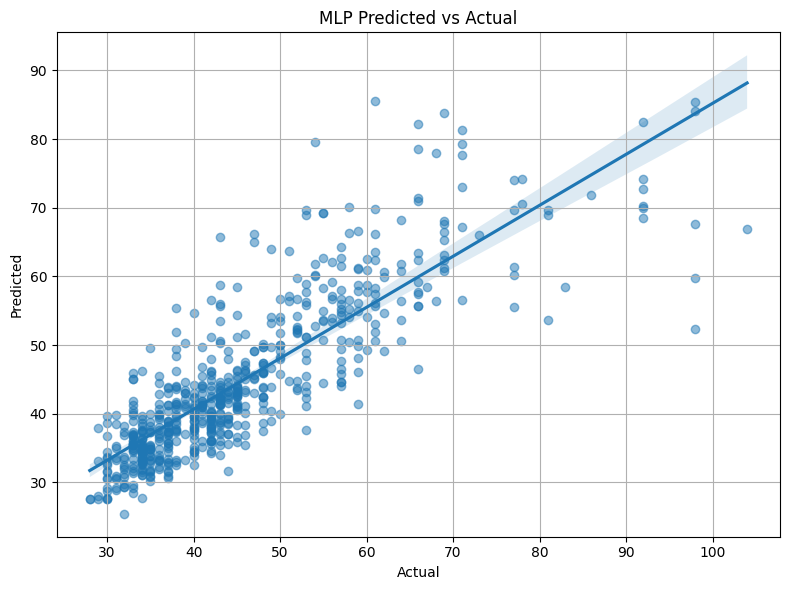

In [85]:
# Flatten y_holdout and predictions
y_holdout = y_holdout_b.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

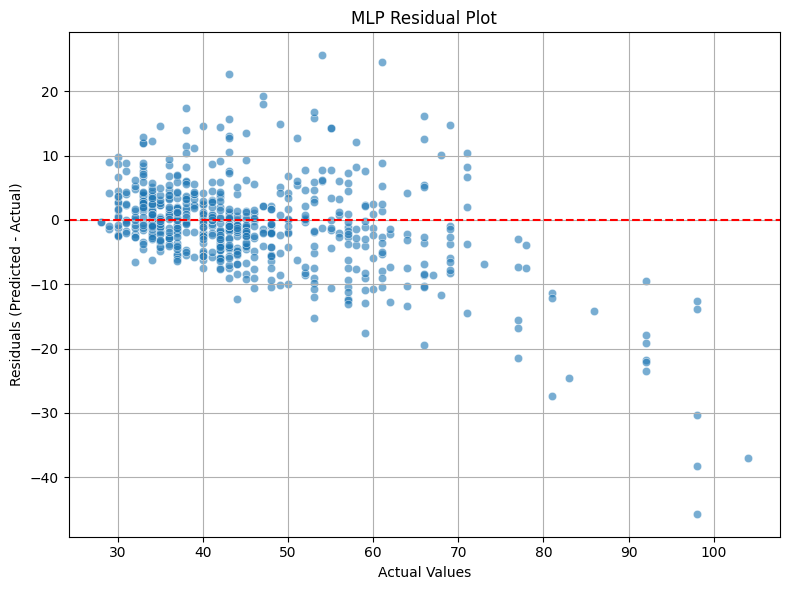

In [86]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only Location

In [90]:
pca_loc= X_dupe.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,-0.047794,0.025266,-0.001196,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.051694,0.007611,0.026473,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.029533,-0.009204,-0.021543,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,0.000290,0.000975,-0.025159,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.018123,0.015692,-0.035930,0,1,0,0,0,1,0


In [91]:
pca_loc_dupe = X_dupe.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,198,199,200,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,-0.047794,0.025266,-0.001196,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.051694,0.007611,0.026473,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.029533,-0.009204,-0.021543,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,0.000290,0.000975,-0.025159,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.018123,0.015692,-0.035930,0,1,0,0,0,1,0


In [92]:
X_tensor = torch.tensor(pca_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [93]:
print(X_tensor.shape)

torch.Size([2536, 207])


In [94]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [35]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-22 14:05:59,172] A new study created in memory with name: no-name-d17e0b25-0d67-49fa-92eb-c19c808c1d3a
[I 2025-05-22 14:06:00,173] Trial 0 finished with value: 95.99144744873047 and parameters: {'hidden_size1': 100, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout1': 0.08247593294497219, 'dropout2': 0.06080629356585615, 'lr': 0.00017485631540544184, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 6}. Best is trial 0 with value: 95.99144744873047.
[I 2025-05-22 14:06:01,777] Trial 1 finished with value: 1850.2366943359375 and parameters: {'hidden_size1': 300, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.03389391639020066, 'dropout2': 0.051136004906879605, 'lr': 0.0034043970877556153, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 14}. Best is trial 0 with value: 95.99144744873047.
[I 2025-05-22 14:06:04,836] Trial 2 finished with value: 50.53853988647461 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden

Early stopping at epoch 51


[I 2025-05-22 14:06:30,949] Trial 11 finished with value: 33.76910400390625 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.06347933108322981, 'dropout2': 0.07001194945161061, 'lr': 0.00054819907055063, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 9}. Best is trial 10 with value: 33.41274642944336.


Early stopping at epoch 54


[I 2025-05-22 14:06:34,072] Trial 12 finished with value: 33.58785629272461 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.06104936999794007, 'dropout2': 0.0785304009152582, 'lr': 0.0006556717296942186, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 11}. Best is trial 10 with value: 33.41274642944336.


...

Early stopping at epoch 25


[I 2025-05-22 14:08:09,956] Trial 45 finished with value: 34.94234085083008 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.034034774677370504, 'dropout2': 0.08168927563248608, 'lr': 0.0005033806337355883, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 10}. Best is trial 23 with value: 32.090354919433594.
[I 2025-05-22 14:08:11,172] Trial 46 finished with value: 36.60240936279297 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout1': 0.09968404619570345, 'dropout2': 0.0956238227526287, 'lr': 0.005279899152252036, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 6}. Best is trial 23 with value: 32.090354919433594.


Early stopping at epoch 20


[I 2025-05-22 14:08:14,971] Trial 47 finished with value: 1756.5093994140625 and parameters: {'hidden_size1': 300, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout1': 0.04724040767062677, 'dropout2': 0.08364611012781835, 'lr': 0.0012392864390822877, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 14}. Best is trial 23 with value: 32.090354919433594.
[I 2025-05-22 14:08:18,264] Trial 48 finished with value: 33.821136474609375 and parameters: {'hidden_size1': 300, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout1': 0.043628982243005446, 'dropout2': 0.09094779321441633, 'lr': 0.0009298380692719293, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 13}. Best is trial 23 with value: 32.090354919433594.
[I 2025-05-22 14:08:20,752] Trial 49 finished with value: 41.645599365234375 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout1': 0.06818072406821682, 'dropout2': 0.05690241110099337, 'lr': 0.0003114218819375154, 'b

Best hyperparameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.059248674775240574, 'dropout2': 0.09920261754656115, 'lr': 0.000325987545187101, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 15}


In [37]:
best_params = study.best_params

In [38]:
#def cross_validate(X, y, best_params, n_splits, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_200_best_model_onlyloc_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 34.2484
Training fold 2
Fold 2 validation loss: 46.5956
Training fold 3
Fold 3 validation loss: 38.6377
Training fold 4
Fold 4 validation loss: 51.4456
Training fold 5
Fold 5 validation loss: 38.7849
Training fold 6
Fold 6 validation loss: 42.9612
Training fold 7
Fold 7 validation loss: 46.9003
Training fold 8
Fold 8 validation loss: 48.1189
Training fold 9
Fold 9 validation loss: 40.3682
Training fold 10
Fold 10 validation loss: 50.3470

Average validation loss across all folds: 43.8408
Checkpoint saved as 'pca_200_best_model_onlyloc_mlp_bbd.pth'.


In [82]:
X_holdout_b = pca_full_holdout_b.iloc[:, :511]
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [83]:
y_holdout_b = pca_full_holdout_b.iloc[:, 511:]
y_holdout_b.head()

,BBD
Line,
s143,42
s525,42
s2272,32
s2255,56
s1588,32


In [84]:
# Ensure both training and holdout datasets have the same columns
pca_loc_dupe, X_holdout_b = pca_loc_dupe.align(X_holdout_b, join='inner', axis=1)

In [85]:
X_holdout_b.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s143 to s1777
Columns: 207 entries, 1 to landrace
dtypes: float64(200), int64(7)
memory usage: 1.0+ MB


In [86]:
X_holdout_b = X_holdout_b.to_numpy()
y_holdout_b = y_holdout_b.to_numpy()

In [44]:
predictions, metrics = evaluate_on_holdout(X_holdout_b, y_holdout_b, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 55.7944
RMSE: 7.4696
MAE: 4.9555
R2: 0.6760
Holdout_Loss: 55.7944


In [45]:
pickle.dump(best_mlp_model, open("pca_200_best_model_onlyloc_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 42 58.43962
1 42 40.88152
2 32 28.646214
3 56 61.727257
4 32 39.9918
5 48 45.77981


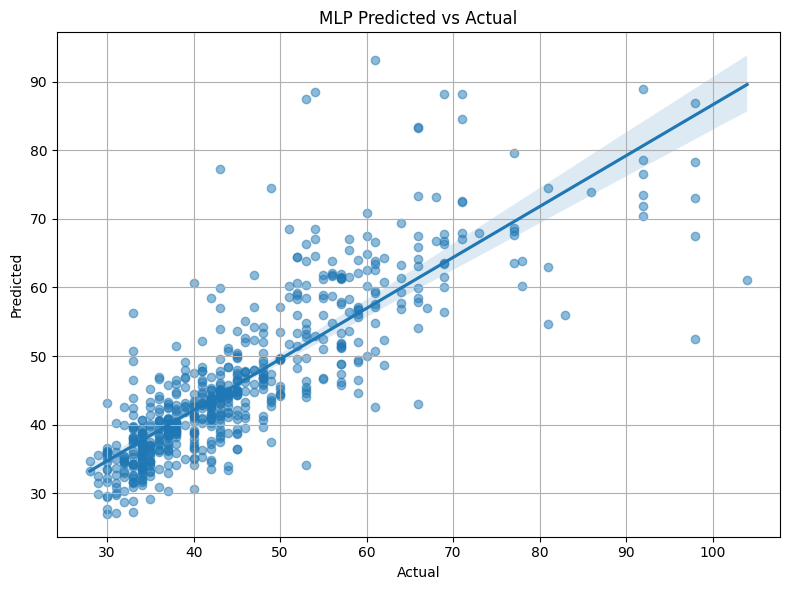

In [46]:
# Flatten y_holdout and predictions
y_holdout = y_holdout_b.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

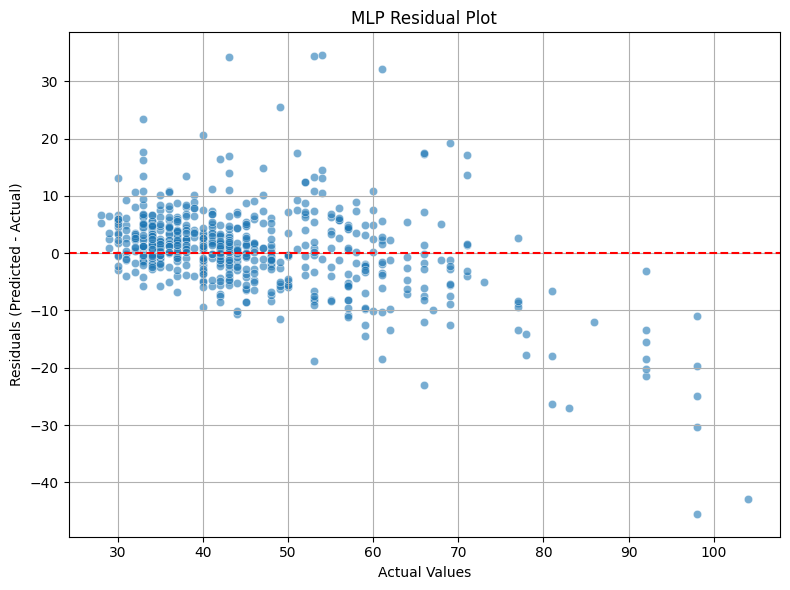

In [47]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

In [75]:
# Load checkpoint
checkpoint = torch.load("pca_200_best_model_onlyloc_mlp_bbd.pth", map_location=device)

# Rebuild model architecture
model = build_model(checkpoint['input_dim'], checkpoint['best_params']).to(device)

# Load model weights
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

Sequential(
  (0): Linear(in_features=207, out_features=100, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.0322243232043296, inplace=False)
  (3): Linear(in_features=100, out_features=150, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.027527443986327053, inplace=False)
  (6): Linear(in_features=150, out_features=50, bias=True)
  (7): ReLU()
  (8): Linear(in_features=50, out_features=1, bias=True)
)

In [95]:
background = X_train[:100].to(device).to(torch.float32)
test_data = torch.tensor(X_holdout_b[:50], dtype=torch.float32).to(device)

In [96]:
print("Background shape:", background.shape)
print("Test data shape:", test_data.shape)

Background shape: torch.Size([100, 207])
Test data shape: torch.Size([50, 207])


In [97]:
explainer = shap.DeepExplainer(model, background)
shap_values = explainer.shap_values(test_data)

<Figure size 640x480 with 0 Axes>

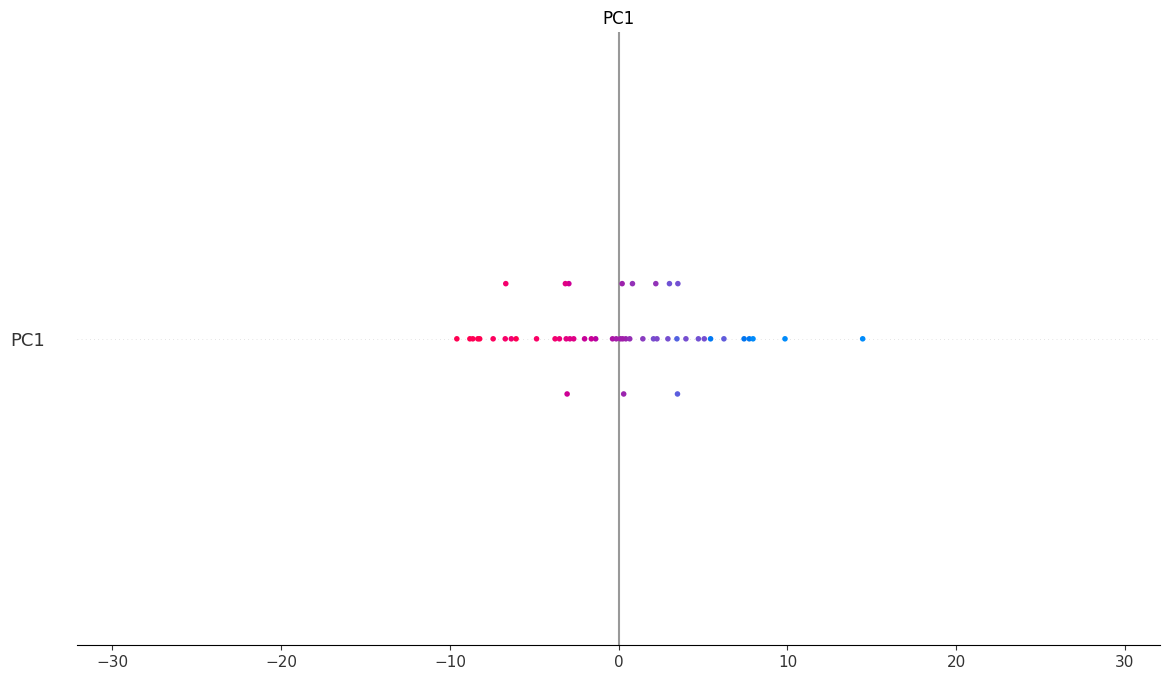

In [101]:
shap.summary_plot(
    shap_values,
    X_holdout_b[:50],
    feature_names=[f"PC{i+1}" for i in range(checkpoint["input_dim"])]
)

(207, 1)


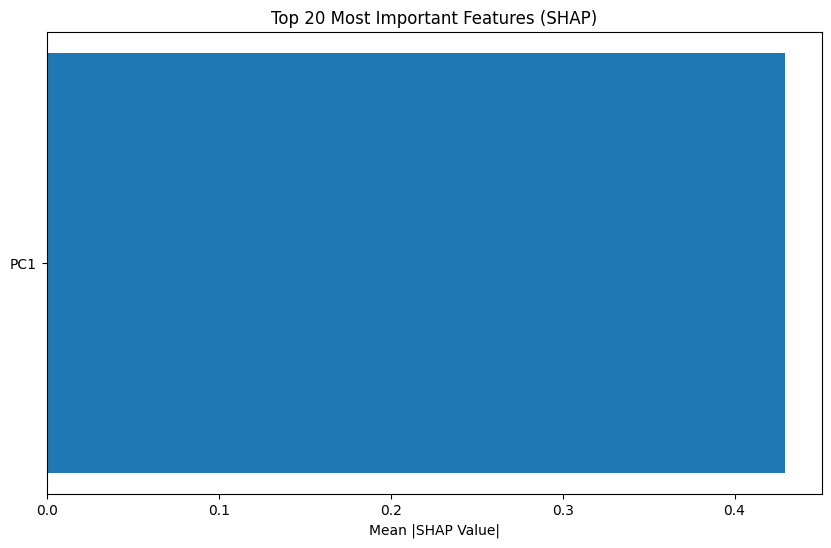

In [103]:
# If shap_values is a list of length 1 (common for single-output regression)
shap_array = shap_values[0]  # extract the array
print(shap_array.shape)  # should be (num_samples, num_features)

# Compute mean absolute SHAP values per feature
shap_importance = np.abs(shap_array).mean(axis=0)

# Create a DataFrame
importance_df = pd.DataFrame({
    "feature": [f"PC{i+1}" for i in range(shap_array.shape[1])],
    "importance": shap_importance
}).sort_values(by="importance", ascending=False)

# Plot top 20 features
plt.figure(figsize=(10,6))
plt.barh(importance_df["feature"][:20][::-1], importance_df["importance"][:20][::-1])
plt.title("Top 20 Most Important Features (SHAP)")
plt.xlabel("Mean |SHAP Value|")
plt.show()

### Only PCs

In [48]:
only_pca= pd.concat([pca_full_train_b.iloc[:, :200], pca_full_train_b.iloc[:, -3:]], axis=1)
only_pca= only_pca.drop(['BBD'], axis=1)
only_pca.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,0.001748,0.049728,-0.004468,0.013603,0.004783,-0.047794,0.025266,-0.001196,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.003405,-0.035944,-0.020534,-0.005262,-0.004323,-0.051694,0.007611,0.026473,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.022575,0.000761,0.009345,-0.009807,0.022334,-0.029533,-0.009204,-0.021543,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,-0.009625,-0.005164,0.002213,-0.000575,0.027361,0.000290,0.000975,-0.025159,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.036281,-0.008460,0.006966,-0.063939,-0.035466,-0.018123,0.015692,-0.035930,1,0


In [49]:
only_pca_dupe = pd.concat([pca_full_train_b.iloc[:, :200], pca_full_train_b.iloc[:, -3:]], axis=1)
only_pca_dupe = only_pca_dupe .drop(['BBD'], axis=1)
only_pca_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,193,194,195,196,197,198,199,200,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,0.001748,0.049728,-0.004468,0.013603,0.004783,-0.047794,0.025266,-0.001196,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.003405,-0.035944,-0.020534,-0.005262,-0.004323,-0.051694,0.007611,0.026473,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.022575,0.000761,0.009345,-0.009807,0.022334,-0.029533,-0.009204,-0.021543,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,-0.009625,-0.005164,0.002213,-0.000575,0.027361,0.000290,0.000975,-0.025159,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.036281,-0.008460,0.006966,-0.063939,-0.035466,-0.018123,0.015692,-0.035930,1,0


In [50]:
# Convert to tensor and move to GPU if available
X_tensor = torch.tensor(only_pca.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [51]:
print(X_tensor.shape)

torch.Size([2536, 202])


In [52]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [53]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-22 14:12:57,558] A new study created in memory with name: no-name-3f44eb7f-8d16-4ef2-ae54-c423d6908c34
[I 2025-05-22 14:12:59,811] Trial 0 finished with value: 553.1928100585938 and parameters: {'hidden_size1': 100, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.018068397740568808, 'dropout2': 0.023645409914504166, 'lr': 0.003988408168642788, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 7}. Best is trial 0 with value: 553.1928100585938.
[I 2025-05-22 14:13:00,868] Trial 1 finished with value: 181.52432250976562 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.0747073035139216, 'dropout2': 0.08404848610195459, 'lr': 0.00021111374236829666, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 8}. Best is trial 1 with value: 181.52432250976562.
[I 2025-05-22 14:13:02,186] Trial 2 finished with value: 173.671875 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 2

Early stopping at epoch 22


[I 2025-05-22 14:13:03,813] Trial 3 finished with value: 2280.20263671875 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout1': 0.05486010208550447, 'dropout2': 0.04358991283863438, 'lr': 0.0011276631301459933, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 10}. Best is trial 2 with value: 173.671875.
[I 2025-05-22 14:13:04,872] Trial 4 finished with value: 169.18228149414062 and parameters: {'hidden_size1': 100, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.028696827433367406, 'dropout2': 0.027144887250606847, 'lr': 0.001924661394822868, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 10}. Best is trial 4 with value: 169.18228149414062.
[I 2025-05-22 14:13:06,249] Trial 5 finished with value: 195.0334930419922 and parameters: {'hidden_size1': 300, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout1': 0.040629908686357394, 'dropout2': 0.032519412121171244, 'lr': 0.0041994770314938154, 'batch_size': 

Early stopping at epoch 23


[I 2025-05-22 14:13:08,540] Trial 6 finished with value: 180.6676788330078 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.022648856036383634, 'dropout2': 0.03412495280078266, 'lr': 0.002352296658238367, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 6}. Best is trial 4 with value: 169.18228149414062.


...

Early stopping at epoch 30


[I 2025-05-22 14:15:21,662] Trial 46 finished with value: 171.50405883789062 and parameters: {'hidden_size1': 300, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout1': 0.01116142722995652, 'dropout2': 0.056014630716002364, 'lr': 0.001223788453275639, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 11}. Best is trial 41 with value: 168.52183532714844.


Early stopping at epoch 44


[I 2025-05-22 14:15:23,444] Trial 47 finished with value: 171.3135223388672 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout1': 0.029078894201292043, 'dropout2': 0.03389578137134301, 'lr': 0.0002427536108436124, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 12}. Best is trial 41 with value: 168.52183532714844.
[I 2025-05-22 14:15:26,741] Trial 48 finished with value: 167.40431213378906 and parameters: {'hidden_size1': 100, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout1': 0.019268702824102896, 'dropout2': 0.05948631772142843, 'lr': 0.0007851758389033375, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 9}. Best is trial 48 with value: 167.40431213378906.
[I 2025-05-22 14:15:27,769] Trial 49 finished with value: 170.36773681640625 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.014900782295165936, 'dropout2': 0.052709395985250256, 'lr': 0.0007762553628990584

Best hyperparameters: {'hidden_size1': 100, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout1': 0.019268702824102896, 'dropout2': 0.05948631772142843, 'lr': 0.0007851758389033375, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 9}


In [54]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, best_params, n_splits, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='"pca_200_best_model_onlypcs_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 167.7687
Training fold 2
Fold 2 validation loss: 152.5630
Training fold 3
Fold 3 validation loss: 165.6274
Training fold 4
Fold 4 validation loss: 169.5733
Training fold 5
Fold 5 validation loss: 139.6580
Training fold 6
Fold 6 validation loss: 155.8805
Training fold 7
Fold 7 validation loss: 177.6566
Training fold 8
Fold 8 validation loss: 142.5486
Training fold 9
Fold 9 validation loss: 156.1702
Training fold 10
Fold 10 validation loss: 174.4522

Average validation loss across all folds: 160.1899
Checkpoint saved as '"pca_200_best_model_onlypcs_mlp_bbd.pth'.


In [55]:
best_mlp_model

Sequential(
  (0): Linear(in_features=202, out_features=100, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.019268702824102896, inplace=False)
  (3): Linear(in_features=100, out_features=150, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.05948631772142843, inplace=False)
  (6): Linear(in_features=150, out_features=25, bias=True)
  (7): ReLU()
  (8): Linear(in_features=25, out_features=1, bias=True)
)

In [56]:
pca_full_holdout_b = pd.read_pickle("pickle_files/pca_full_holdout_bbd.pkl")
pca_full_holdout_b = pca_full_holdout_b.reset_index().set_index('Line')
pca_full_holdout_b = pca_full_holdout_b.drop(['index','new_line'], axis=1)
pca_full_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,90.0,1.00000,0,1,0,0,0,0,1,42
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,200.4,1.40000,0,0,1,0,0,0,1,42
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,46.6,0.80000,0,1,0,0,0,1,0,32
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,49.8,4.66667,0,0,0,1,0,1,0,56
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,61.6,1.80000,0,1,0,0,0,1,0,32


In [57]:
X_holdout_b = pca_full_holdout_b.iloc[:, :511]
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [58]:
y_holdout_b = pca_full_holdout_b.iloc[:, 511:]
y_holdout_b.head()

,BBD
Line,
s143,42
s525,42
s2272,32
s2255,56
s1588,32


In [59]:
# Ensure both training and holdout datasets have the same columns
only_pca_dupe, X_holdout_b =only_pca_dupe.align(X_holdout_b, join='inner', axis=1)

In [60]:
X_holdout_b.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s143 to s1777
Columns: 202 entries, 1 to landrace
dtypes: float64(200), int64(2)
memory usage: 1005.5+ KB


In [61]:
X_holdout_b = X_holdout_b.to_numpy()
y_holdout_b = y_holdout_b.to_numpy()

In [62]:
predictions, metrics = evaluate_on_holdout(X_holdout_b, y_holdout_b, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 161.9984
RMSE: 12.7279
MAE: 9.4904
R2: 0.0594
Holdout_Loss: 161.9984


In [62]:
pickle.dump(best_mlp_model, open("pca_200_best_model_onlypcs_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

## PC500 

In [184]:
# 1. Define a training function for Optuna to optimize parameters
def objective(trial):
    # Suggest hyperparameters
    params = {
            'hidden_size1': trial.suggest_int('hidden_size1', 64, 256, step=32),
            'hidden_size2': trial.suggest_int('hidden_size2', 32, 128, step=16),
            'hidden_size3': trial.suggest_int('hidden_size3', 16, 64, step=8),
            'dropout1': trial.suggest_float('dropout1', 0.01, 0.1),
            'dropout2': trial.suggest_float('dropout2', 0.01, 0.1),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128]),
            'optimizer': trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD']),
            'num_epochs': trial.suggest_categorical('num_epochs', [30, 50, 70]),
            'patience': trial.suggest_int('patience', 5, 15),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
        }
    # Build model
    model = build_model(X_train.shape[1], params).to(device)
    optimizer = getattr(optim, params['optimizer'])(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay']
    )
    loss_function = nn.MSELoss()
    early_stopping = EarlyStopping(patience=params['patience'])

    # Prepare data
    #X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    #y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    #X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    #y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)

    val_losses = []  # <-- Initialize here

    for epoch in range(params['num_epochs']):
        # Training
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = loss_function(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Validation (after each epoch)
        model.eval()
        with torch.no_grad():
            preds = model(X_val).cpu().numpy()
            true = y_val.cpu().numpy()
            val_loss = loss_function(torch.tensor(preds), y_val.cpu())
            val_losses.append(val_loss.item())

        avg_val_loss = np.mean(val_losses[-5:])  # average of last 5 epochs for stability
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    mse = mean_squared_error(true, preds)
    return mse  # Optuna minimizes this

    #HOW TO USE - create study and then optimise

### All covariates

In [167]:
y_all = pca_full_train_b.iloc[:, 511:]
y_all.head()

,BBD
Line,
s2095,59
s678,41
s204,43
s640,42
s655,30


In [168]:
X_all = pca_full_train_b.iloc[:, 0:511]
X_all.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,10.06000,54.12,4.0,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,7.42000,66.00,1.6,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,9.45333,49.00,3.0,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,5.95333,90.00,0.0,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,6.08667,70.00,1.8,0,1,0,0,0,1,0


In [169]:
X_all_dupe = pca_full_train_b.iloc[:, 0:511]
X_all_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,10.06000,54.12,4.0,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,7.42000,66.00,1.6,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,9.45333,49.00,3.0,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,5.95333,90.00,0.0,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,6.08667,70.00,1.8,0,1,0,0,0,1,0


In [170]:
X_tensor = torch.tensor(X_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [171]:
print(X_tensor.shape)

torch.Size([2536, 511])


In [172]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [173]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-22 15:24:29,264] A new study created in memory with name: no-name-1ffd6166-4da1-48f1-87a4-6e7a112b1a5a
[I 2025-05-22 15:24:30,761] Trial 0 finished with value: 94.91352081298828 and parameters: {'hidden_size1': 224, 'hidden_size2': 32, 'hidden_size3': 16, 'dropout1': 0.06399521096490315, 'dropout2': 0.031022099833418235, 'lr': 0.006286794700718758, 'batch_size': 64, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 7}. Best is trial 0 with value: 94.91352081298828.


Early stopping at epoch 26


[I 2025-05-22 15:24:32,409] Trial 1 finished with value: 176.04518127441406 and parameters: {'hidden_size1': 64, 'hidden_size2': 64, 'hidden_size3': 56, 'dropout1': 0.08536210237477286, 'dropout2': 0.012783964399874597, 'lr': 0.00547898134381995, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 13}. Best is trial 0 with value: 94.91352081298828.
[I 2025-05-22 15:24:34,115] Trial 2 finished with value: 114.22527313232422 and parameters: {'hidden_size1': 64, 'hidden_size2': 32, 'hidden_size3': 40, 'dropout1': 0.017141428190093542, 'dropout2': 0.07105993115041628, 'lr': 0.00019636857829060124, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 15}. Best is trial 0 with value: 94.91352081298828.
[I 2025-05-22 15:24:41,814] Trial 3 finished with value: 73.94866180419922 and parameters: {'hidden_size1': 128, 'hidden_size2': 96, 'hidden_size3': 32, 'dropout1': 0.08542285256049124, 'dropout2': 0.010972815647915291, 'lr': 0.00012441361149500448, 'batch_

Early stopping at epoch 55


[I 2025-05-22 15:24:52,679] Trial 5 finished with value: 66.91944122314453 and parameters: {'hidden_size1': 256, 'hidden_size2': 112, 'hidden_size3': 48, 'dropout1': 0.06718755360305365, 'dropout2': 0.07664338038284677, 'lr': 0.00010750891515917151, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 6}. Best is trial 5 with value: 66.91944122314453.
[I 2025-05-22 15:24:54,497] Trial 6 finished with value: 55.101810455322266 and parameters: {'hidden_size1': 128, 'hidden_size2': 64, 'hidden_size3': 56, 'dropout1': 0.019924876442213392, 'dropout2': 0.07331312087809912, 'lr': 0.003109422220593088, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 10}. Best is trial 6 with value: 55.101810455322266.
[I 2025-05-22 15:24:56,198] Trial 7 finished with value: 88.60728454589844 and parameters: {'hidden_size1': 224, 'hidden_size2': 64, 'hidden_size3': 16, 'dropout1': 0.014031960474591529, 'dropout2': 0.07317015418273795, 'lr': 0.0030345521823457113, 'batch_siz

...

Early stopping at epoch 65


[I 2025-05-22 15:27:15,939] Trial 48 finished with value: 47.52103805541992 and parameters: {'hidden_size1': 224, 'hidden_size2': 32, 'hidden_size3': 24, 'dropout1': 0.09561204538973758, 'dropout2': 0.0289289116005214, 'lr': 0.0018543435932105356, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 12}. Best is trial 41 with value: 43.26431655883789.


Early stopping at epoch 53


[I 2025-05-22 15:27:18,249] Trial 49 finished with value: 274.1188659667969 and parameters: {'hidden_size1': 224, 'hidden_size2': 48, 'hidden_size3': 16, 'dropout1': 0.08605004610302679, 'dropout2': 0.024089907314998854, 'lr': 0.0012428621744797821, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 11}. Best is trial 41 with value: 43.26431655883789.


Best hyperparameters: {'hidden_size1': 160, 'hidden_size2': 64, 'hidden_size3': 64, 'dropout1': 0.06733733171973794, 'dropout2': 0.03589932385303889, 'lr': 0.0034065518365703714, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 6}


In [176]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_500_best_model_allfeats_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 47.8537
Training fold 2
Fold 2 validation loss: 43.5166
Training fold 3
Fold 3 validation loss: 39.0578
Training fold 4
Fold 4 validation loss: 53.7105
Training fold 5
Fold 5 validation loss: 71.1733
Training fold 6
Fold 6 validation loss: 62.0900
Training fold 7
Fold 7 validation loss: 41.0854
Training fold 8
Fold 8 validation loss: 45.0002
Training fold 9
Fold 9 validation loss: 39.1059
Training fold 10
Fold 10 validation loss: 46.6642

Average validation loss across all folds: 48.9258
Checkpoint saved as 'pca_500_best_model_allfeats_mlp_bbd.pth'.


In [71]:
best_mlp_model

Sequential(
  (0): Linear(in_features=511, out_features=200, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.03360383282304379, inplace=False)
  (3): Linear(in_features=200, out_features=150, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.09228675507256358, inplace=False)
  (6): Linear(in_features=150, out_features=50, bias=True)
  (7): ReLU()
  (8): Linear(in_features=50, out_features=1, bias=True)
)

In [178]:
X_holdout_b = pca_full_holdout_b.iloc[:, 0:511]
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [179]:
y_holdout_b = pca_full_holdout_b.iloc[:, 511:]
y_holdout_b.head()

,BBD
Line,
s143,42
s525,42
s2272,32
s2255,56
s1588,32


In [180]:
# Ensure both training and holdout datasets have the same columns
X_all_dupe, X_holdout_b = X_all_dupe.align(X_holdout_b, join='inner', axis=1)

In [181]:
X_holdout_b.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s143 to s1777
Columns: 511 entries, 1 to landrace
dtypes: float64(504), int64(7)
memory usage: 2.5+ MB


In [182]:
X_holdout_b = X_holdout_b.to_numpy()
y_holdout_b = y_holdout_b.to_numpy()

In [183]:
predictions, metrics = evaluate_on_holdout(X_holdout_b, y_holdout_b, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 53.0339
RMSE: 7.2824
MAE: 4.8053
R2: 0.6921
Holdout_Loss: 53.0339


In [78]:
pickle.dump(best_mlp_model, open("pca_500_best_model_allfeats_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 42 47.170403
1 42 52.310883
2 32 32.816578
3 56 59.86022
4 32 39.68322
5 48 49.596004


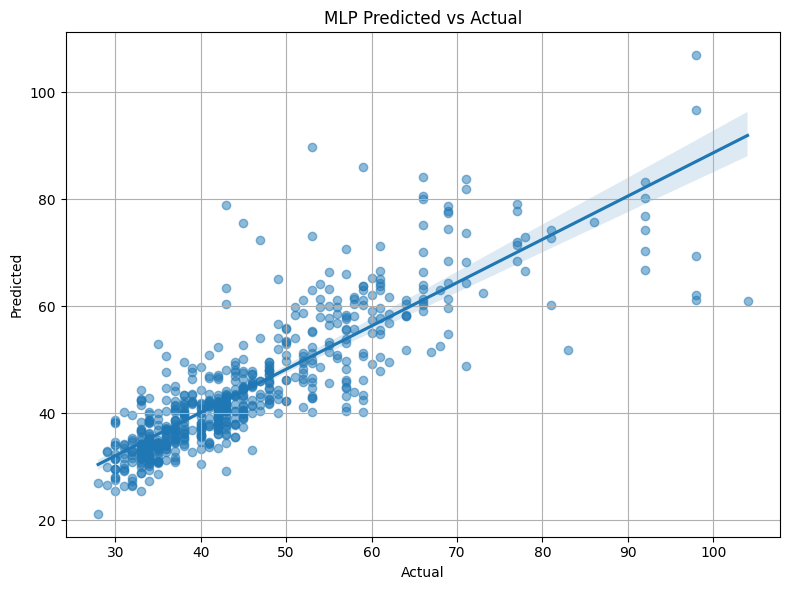

In [79]:
# Flatten y_holdout and predictions
y_holdout = y_holdout_b.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

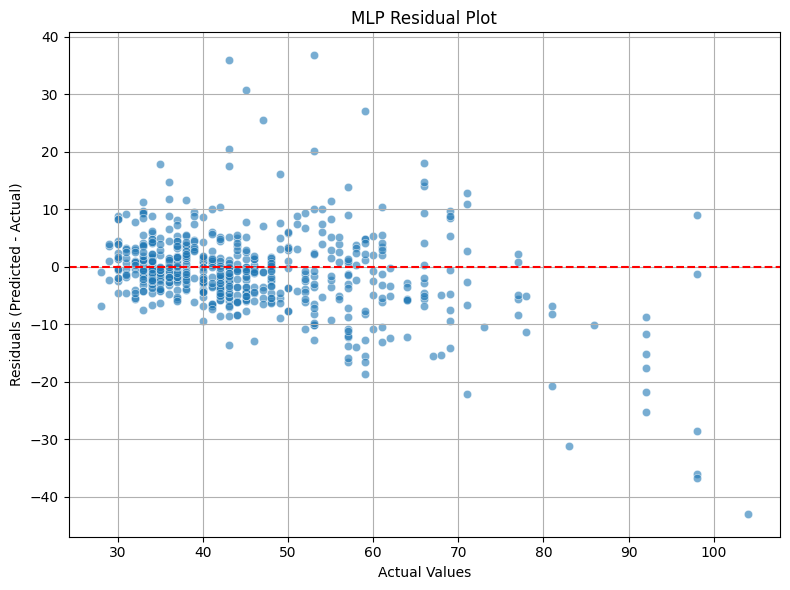

In [80]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [81]:
pca_loc= X_all_dupe.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc.head()

,1,2,3,4,5,6,7,8,9,10,...,498,499,500,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,0.010562,-0.020318,0.010057,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,0.056979,0.020866,0.000859,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.015515,-0.018886,0.011926,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,-0.017881,-0.002570,0.001820,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.006503,-0.019643,-0.008418,0,1,0,0,0,1,0


In [82]:
pca_loc_dupe = X_all_dupe.drop(['VBN', 'LL', 'LW', 'PLH'], axis=1)
pca_loc_dupe .head()

,1,2,3,4,5,6,7,8,9,10,...,498,499,500,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,0.010562,-0.020318,0.010057,0,0,0,1,0,1,0
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,0.056979,0.020866,0.000859,0,1,0,0,0,1,0
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,-0.015515,-0.018886,0.011926,0,0,1,0,0,1,0
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,-0.017881,-0.002570,0.001820,0,0,1,0,0,1,0
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.006503,-0.019643,-0.008418,0,1,0,0,0,1,0


In [83]:
y = pca_full_train_b.iloc[:, 511:]
y.head()

,BBD
Line,
s2095,59
s678,41
s204,43
s640,42
s655,30


In [84]:
X_tensor = torch.tensor(pca_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [85]:
print(X_tensor.shape)

torch.Size([2536, 507])


In [86]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [88]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-22 14:31:54,407] A new study created in memory with name: no-name-68c1a051-c846-4a53-ae67-81771edbbaf5
[I 2025-05-22 14:31:57,496] Trial 0 finished with value: 60.021507263183594 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.04855435976420697, 'dropout2': 0.08931478149344303, 'lr': 0.00408377062009755, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 13}. Best is trial 0 with value: 60.021507263183594.


Early stopping at epoch 32


[I 2025-05-22 14:32:04,110] Trial 1 finished with value: 2147.127197265625 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout1': 0.03240982502726976, 'dropout2': 0.08165973640344039, 'lr': 0.00037770018048431897, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 9}. Best is trial 0 with value: 60.021507263183594.
[I 2025-05-22 14:32:05,986] Trial 2 finished with value: 47.523719787597656 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.015374029832647218, 'dropout2': 0.09226272614004323, 'lr': 0.003976343911154411, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 5}. Best is trial 2 with value: 47.523719787597656.


Early stopping at epoch 19


[I 2025-05-22 14:32:08,596] Trial 3 finished with value: 113.13971710205078 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.09784504927838912, 'dropout2': 0.050604878332177666, 'lr': 0.004161745507132422, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 13}. Best is trial 2 with value: 47.523719787597656.
[I 2025-05-22 14:32:09,777] Trial 4 finished with value: 63.84309005737305 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.09630732932550133, 'dropout2': 0.0628914134427867, 'lr': 0.0033293215476464474, 'batch_size': 64, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 8}. Best is trial 2 with value: 47.523719787597656.


...

Early stopping at epoch 39


[I 2025-05-22 14:33:38,750] Trial 45 finished with value: 54.20391845703125 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout1': 0.032191980591339694, 'dropout2': 0.017233201152243274, 'lr': 0.0004064991141058133, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 8}. Best is trial 21 with value: 38.05556869506836.
[I 2025-05-22 14:33:43,650] Trial 46 finished with value: 861.5385131835938 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout1': 0.03693944280829384, 'dropout2': 0.025334760539759933, 'lr': 0.0013218461535880173, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 14}. Best is trial 21 with value: 38.05556869506836.
[I 2025-05-22 14:33:45,221] Trial 47 finished with value: 40.81768035888672 and parameters: {'hidden_size1': 300, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.07262566534741001, 'dropout2': 0.03870378359109887, 'lr': 0.0009479558831463171, 'batc

Early stopping at epoch 43


[I 2025-05-22 14:33:49,216] Trial 48 finished with value: 39.8726921081543 and parameters: {'hidden_size1': 300, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.07265535705799965, 'dropout2': 0.03743956906722804, 'lr': 0.0001833427689614178, 'batch_size': 64, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 13}. Best is trial 21 with value: 38.05556869506836.
[I 2025-05-22 14:33:53,216] Trial 49 finished with value: 52.228599548339844 and parameters: {'hidden_size1': 300, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.0832207875133311, 'dropout2': 0.04037232064117367, 'lr': 0.00010636857603483666, 'batch_size': 64, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 13}. Best is trial 21 with value: 38.05556869506836.


Best hyperparameters: {'hidden_size1': 300, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.04400073872323959, 'dropout2': 0.019566585602632074, 'lr': 0.0005724700143503998, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 9}


In [89]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_500_best_model_onlyloc_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 40.3512
Training fold 2
Fold 2 validation loss: 39.8439
Training fold 3
Fold 3 validation loss: 38.9897
Training fold 4
Fold 4 validation loss: 45.5185
Training fold 5
Fold 5 validation loss: 38.8084
Training fold 6
Fold 6 validation loss: 64.8432
Training fold 7
Fold 7 validation loss: 53.9936
Training fold 8
Fold 8 validation loss: 46.3094
Training fold 9
Fold 9 validation loss: 47.0230
Training fold 10
Fold 10 validation loss: 55.3970

Average validation loss across all folds: 47.1078
Checkpoint saved as 'pca_500_best_model_onlyloc_mlp_bbd.pth'.


In [90]:
pca_full_holdout_b = pd.read_pickle("pickle_files/pca_full_holdout_bbd.pkl")
pca_full_holdout_b = pca_full_holdout_b.reset_index().set_index('Line')
pca_full_holdout_b = pca_full_holdout_b.drop(['index','new_line'], axis=1)
pca_full_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,90.0,1.00000,0,1,0,0,0,0,1,42
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,200.4,1.40000,0,0,1,0,0,0,1,42
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,46.6,0.80000,0,1,0,0,0,1,0,32
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,49.8,4.66667,0,0,0,1,0,1,0,56
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,61.6,1.80000,0,1,0,0,0,1,0,32


In [91]:
X_holdout_b = pca_full_holdout_b.iloc[:, :511]
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [92]:
y_holdout_b = pca_full_holdout_b.iloc[:, 511:]
y_holdout_b.head()

,BBD
Line,
s143,42
s525,42
s2272,32
s2255,56
s1588,32


In [93]:
# Ensure both training and holdout datasets have the same columns
pca_loc_dupe, X_holdout_b = pca_loc_dupe.align(X_holdout_b, join='inner', axis=1)

In [94]:
X_holdout_b.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s143 to s1777
Columns: 507 entries, 1 to landrace
dtypes: float64(500), int64(7)
memory usage: 2.5+ MB


In [95]:
X_holdout_b = X_holdout_b.to_numpy()
y_holdout_b = y_holdout_b.to_numpy()

In [96]:
predictions, metrics = evaluate_on_holdout(X_holdout_b, y_holdout_b, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 60.3906
RMSE: 7.7711
MAE: 4.9324
R2: 0.6493
Holdout_Loss: 60.3906


In [97]:
pickle.dump(best_mlp_model, open("'pca_500_best_model_onlyloc_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 42 49.283653
1 42 37.36292
2 32 27.543869
3 56 73.53956
4 32 44.92973
5 48 48.334515


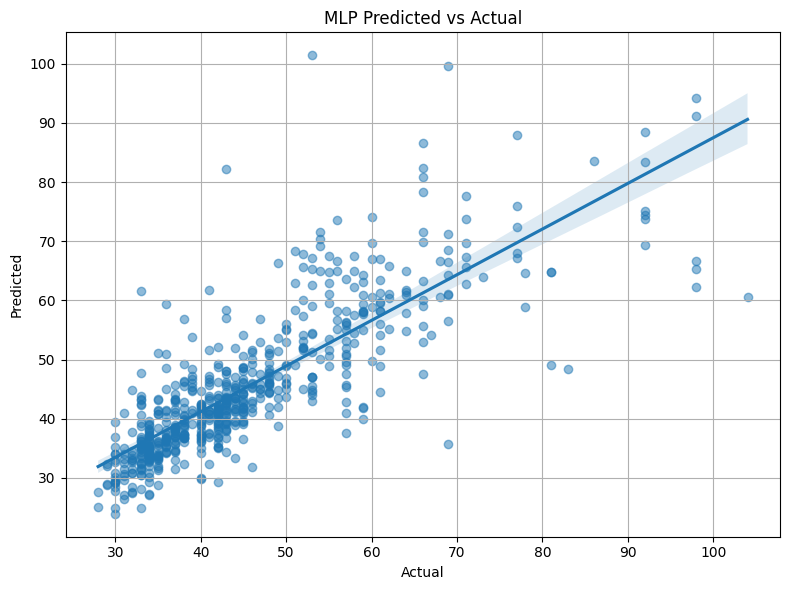

In [98]:
# Flatten y_holdout and predictions
y_holdout = y_holdout_b.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

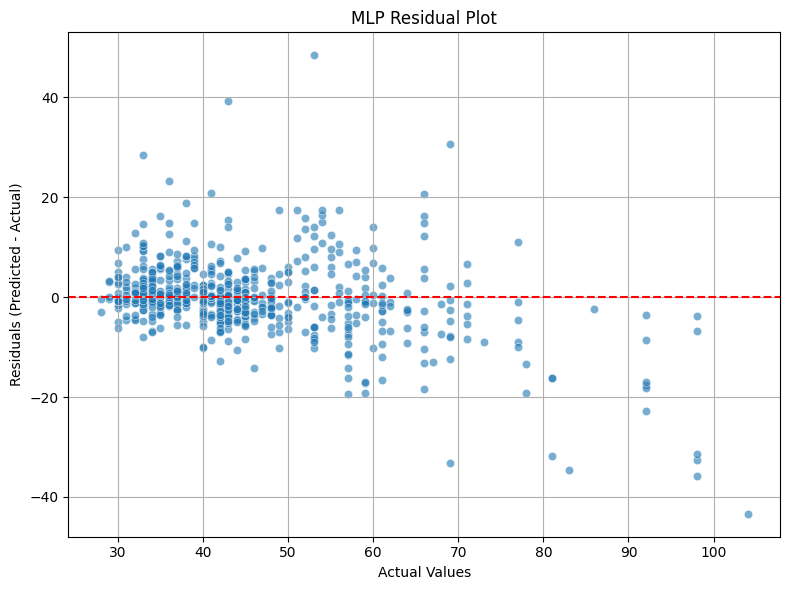

In [99]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [100]:
y = pca_full_train_b.iloc[:, 511:]
y.head()

,BBD
Line,
s2095,59
s678,41
s204,43
s640,42
s655,30


In [101]:
pca_only =  pca_full_train_b.iloc[:, :500]
pca_only.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,0.036188,-0.077684,-0.104369,0.027982,0.055085,-0.011344,0.058702,0.010562,-0.020318,0.010057
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.049191,-0.017708,0.011400,-0.044449,-0.030079,-0.031201,0.065441,0.056979,0.020866,0.000859
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,0.019115,0.019405,-0.015551,-0.003208,0.005062,-0.002142,0.020824,-0.015515,-0.018886,0.011926
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,0.007118,-0.003867,-0.004491,0.003115,-0.000937,-0.008987,-0.003813,-0.017881,-0.002570,0.001820
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.001331,-0.036815,0.004882,-0.035451,-0.020030,0.027865,-0.004135,-0.006503,-0.019643,-0.008418


In [102]:
pca_only_dupe =  pca_full_train_b.iloc[:, :500]
pca_only_dupe.head()

,1,2,3,4,5,6,7,8,9,10,...,491,492,493,494,495,496,497,498,499,500
Line,,,,,,,,,,,,,,,,,,,,,
s2095,0.017340,-0.020218,0.019666,0.033417,-0.063391,0.042125,0.031735,-0.026025,-0.046962,0.001267,...,0.036188,-0.077684,-0.104369,0.027982,0.055085,-0.011344,0.058702,0.010562,-0.020318,0.010057
s678,-0.022135,-0.034205,0.021256,-0.013309,0.002044,-0.052923,-0.017031,0.012516,-0.069667,0.031756,...,-0.049191,-0.017708,0.011400,-0.044449,-0.030079,-0.031201,0.065441,0.056979,0.020866,0.000859
s204,-0.014441,-0.056226,0.004910,0.013886,0.009820,-0.007866,-0.012849,0.009389,0.024924,-0.009769,...,0.019115,0.019405,-0.015551,-0.003208,0.005062,-0.002142,0.020824,-0.015515,-0.018886,0.011926
s640,-0.004530,-0.047364,-0.016644,-0.027917,0.054883,0.058457,0.010945,0.022753,0.013283,-0.030061,...,0.007118,-0.003867,-0.004491,0.003115,-0.000937,-0.008987,-0.003813,-0.017881,-0.002570,0.001820
s655,0.008859,-0.035491,-0.047550,0.003503,0.012936,-0.011286,0.024005,0.040773,-0.023275,0.014986,...,-0.001331,-0.036815,0.004882,-0.035451,-0.020030,0.027865,-0.004135,-0.006503,-0.019643,-0.008418


In [103]:
X_tensor = torch.tensor(pca_only.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [104]:
print(X_tensor.shape)

torch.Size([2536, 500])


In [105]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [107]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-22 14:35:54,463] A new study created in memory with name: no-name-d5cd7f75-22a5-4349-8036-0b3b68be5426
[I 2025-05-22 14:35:57,038] Trial 0 finished with value: 245.41368103027344 and parameters: {'hidden_size1': 100, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout1': 0.013161720074881107, 'dropout2': 0.03721645673565498, 'lr': 0.005037339570163408, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 14}. Best is trial 0 with value: 245.41368103027344.


Early stopping at epoch 25


[I 2025-05-22 14:35:59,554] Trial 1 finished with value: 207.71299743652344 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout1': 0.06295199269419817, 'dropout2': 0.08682708204011644, 'lr': 0.0003243414952063409, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 9}. Best is trial 1 with value: 207.71299743652344.


Early stopping at epoch 23


[I 2025-05-22 14:36:02,489] Trial 2 finished with value: 2369.778076171875 and parameters: {'hidden_size1': 300, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.09180263473623834, 'dropout2': 0.02642354657332624, 'lr': 0.000200465937735129, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 6}. Best is trial 1 with value: 207.71299743652344.
[I 2025-05-22 14:36:04,242] Trial 3 finished with value: 205.00128173828125 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.05307735006111221, 'dropout2': 0.04058233516996661, 'lr': 0.00019954274891148974, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 9}. Best is trial 3 with value: 205.00128173828125.


...

Early stopping at epoch 29


[I 2025-05-22 14:37:46,986] Trial 48 finished with value: 202.5106658935547 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout1': 0.08662533786579722, 'dropout2': 0.010338180072958357, 'lr': 0.00012524588416158947, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 12}. Best is trial 23 with value: 199.67832946777344.


Early stopping at epoch 33


[I 2025-05-22 14:37:48,811] Trial 49 finished with value: 202.08648681640625 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout1': 0.025393092932367693, 'dropout2': 0.024030923152413362, 'lr': 0.00010013755195735282, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 11}. Best is trial 23 with value: 199.67832946777344.


Best hyperparameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout1': 0.02550361970540916, 'dropout2': 0.0269883269168818, 'lr': 0.00014720796278706533, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 11}


In [108]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='pca_500_best_model_onlypcs_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 207.7067
Training fold 2
Fold 2 validation loss: 171.7913
Training fold 3
Fold 3 validation loss: 191.1753
Training fold 4
Fold 4 validation loss: 204.1246
Training fold 5
Fold 5 validation loss: 176.3754
Training fold 6
Fold 6 validation loss: 193.2537
Training fold 7
Fold 7 validation loss: 220.4691
Training fold 8
Fold 8 validation loss: 164.8135
Training fold 9
Fold 9 validation loss: 180.3994
Training fold 10
Fold 10 validation loss: 195.9499

Average validation loss across all folds: 190.6059
Checkpoint saved as 'pca_500_best_model_onlypcs_mlp_bbd.pth'.


In [109]:
pca_full_holdout_b = pd.read_pickle("pickle_files/pca_full_holdout_bbd.pkl")
pca_full_holdout_b = pca_full_holdout_b.reset_index().set_index('Line')
pca_full_holdout_b = pca_full_holdout_b.drop(['index','new_line'], axis=1)
pca_full_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,90.0,1.00000,0,1,0,0,0,0,1,42
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,200.4,1.40000,0,0,1,0,0,0,1,42
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,46.6,0.80000,0,1,0,0,0,1,0,32
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,49.8,4.66667,0,0,0,1,0,1,0,56
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,61.6,1.80000,0,1,0,0,0,1,0,32


In [110]:
X_holdout_b = pca_full_holdout_b.iloc[:, :511]
X_holdout_b.head()

,1,2,3,4,5,6,7,8,9,10,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s143,-0.037623,0.016473,0.012063,0.031293,-0.019840,0.004062,0.007396,0.031284,0.017870,0.009386,...,7.44000,90.0,1.00000,0,1,0,0,0,0,1
s525,-0.037034,0.020906,-0.019172,0.007481,0.004287,-0.002993,0.016178,0.006353,0.004342,-0.014619,...,6.52000,200.4,1.40000,0,0,1,0,0,0,1
s2272,0.022259,0.027293,0.020253,-0.061115,0.003677,-0.009608,-0.029379,-0.013829,0.019218,0.000583,...,6.72667,46.6,0.80000,0,1,0,0,0,1,0
s2255,0.024638,0.012919,0.025665,-0.028113,0.003097,-0.029669,-0.018720,0.009785,-0.014827,0.038961,...,5.53333,49.8,4.66667,0,0,0,1,0,1,0
s1588,0.013591,0.007612,0.008863,-0.028182,-0.014488,-0.018064,-0.011339,0.003779,-0.046108,0.035115,...,6.07333,61.6,1.80000,0,1,0,0,0,1,0


In [111]:
y_holdout_b = pca_full_holdout_b.iloc[:, 511:]
y_holdout_b.head()

,BBD
Line,
s143,42
s525,42
s2272,32
s2255,56
s1588,32


In [112]:
# Ensure both training and holdout datasets have the same columns
pca_only_dupe, X_holdout_b = pca_only_dupe.align(X_holdout_b, join='inner', axis=1)

In [113]:
X_holdout_b.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s143 to s1777
Columns: 500 entries, 1 to 500
dtypes: float64(500)
memory usage: 2.4+ MB


In [114]:
X_holdout_b = X_holdout_b.to_numpy()
y_holdout_b = y_holdout_b.to_numpy()

In [115]:
predictions, metrics = evaluate_on_holdout(X_holdout_b, y_holdout_b, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 188.5630
RMSE: 13.7318
MAE: 10.1319
R2: -0.0949
Holdout_Loss: 188.5630


In [116]:
pickle.dump(best_mlp_model, open("'pca_500_best_model_onlypcs_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 42 69.84075
1 42 47.412533
2 32 41.489452
3 56 53.00754
4 32 45.64963
5 48 52.063763


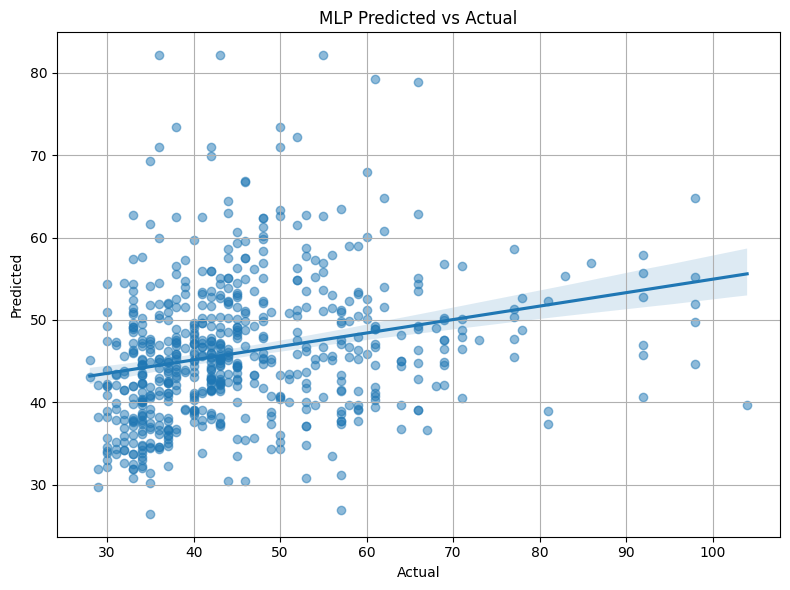

In [117]:
# Flatten y_holdout and predictions
y_holdout = y_holdout_b.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

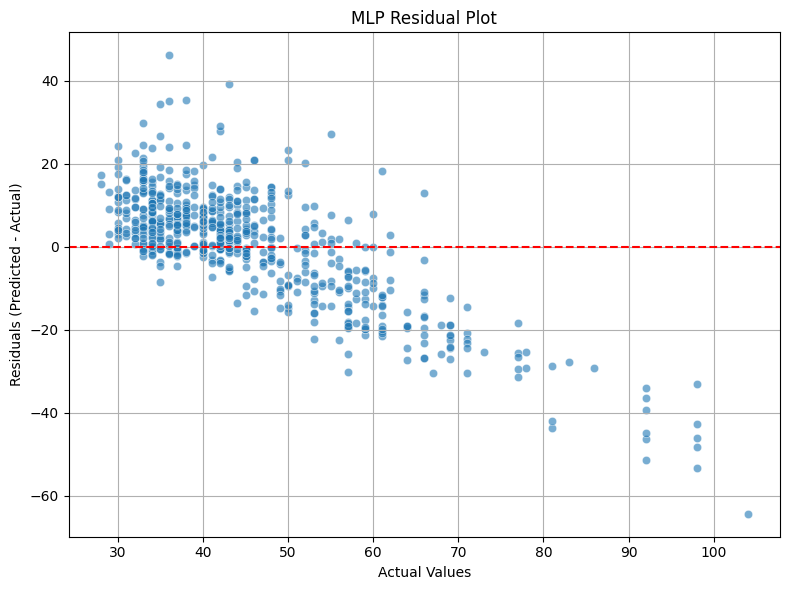

In [118]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

# GWAS

## GWAS top 1%

In [8]:
# 1. Define a training function for Optuna to optimize parameters
def objective(trial):
    # Suggest hyperparameters
    params = {
            'hidden_size1': trial.suggest_categorical('hidden_size1', [100, 200, 300]),
            'hidden_size2': trial.suggest_categorical('hidden_size2', [50, 100, 150]),
            'hidden_size3': trial.suggest_categorical('hidden_size3', [25, 50, 75]),
            'dropout1': trial.suggest_float('dropout1', 0.01, 0.1),
            'dropout2': trial.suggest_float('dropout2', 0.01, 0.1),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128]),
            'optimizer': trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD']),
            'num_epochs': trial.suggest_categorical('num_epochs', [30, 50, 70]),
            'patience': trial.suggest_int('patience', 5, 15),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
        }
    # Build model
    model = build_model(X_train.shape[1], params).to(device)
    optimizer = getattr(optim, params['optimizer'])(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay']
    )
    loss_function = nn.MSELoss()
    early_stopping = EarlyStopping(patience=params['patience'])

    # Prepare data
    #X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    #y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    #X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    #y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)

    val_losses = []  # <-- Initialize here

    for epoch in range(params['num_epochs']):
        # Training
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = loss_function(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Validation (after each epoch)
        model.eval()
        with torch.no_grad():
            preds = model(X_val).cpu().numpy()
            true = y_val.cpu().numpy()
            val_loss = loss_function(torch.tensor(preds), y_val.cpu())
            val_losses.append(val_loss.item())

        avg_val_loss = np.mean(val_losses[-5:])  # average of last 5 epochs for stability
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    mse = mean_squared_error(true, preds)
    return mse  # Optuna minimizes this

    #HOW TO USE - create study and then optimise

### All covariates

In [9]:
gwas_data = pd.read_pickle("pickle_files/GWAS_top1percent_bbd_data.pkl")
gwas_data.head()

,Chr1_131286,Chr1_132416,Chr1_249303,Chr1_360737,Chr1_898070,Chr1_1073992,Chr1_1167769,Chr1_2450278,Chr1_2547160,Chr1_3514585,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,2,0,1,2,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,0,0,0,0,2,0,1,2,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,0,0,0,0,2,0,1,2,...,116.000,3.40000,0,0,1,0,0,0,1,43
s101,0,0,0,0,0,0,1,2,0,0,...,58.000,2.60000,0,0,0,0,1,0,1,53
s1014,0,0,0,0,0,2,2,0,1,2,...,111.733,8.66667,1,0,0,0,0,0,1,77


In [214]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 2524 entries, Chr1_131286 to BBD
dtypes: float64(4), int64(2520)
memory usage: 48.9+ MB


In [215]:
gwas_y = gwas_data.iloc[:, 2523:]
gwas_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s101,53
s1014,77


In [216]:
gwas_all= gwas_data.drop(['BBD'], axis=1)
gwas_all.head()

,Chr1_131286,Chr1_132416,Chr1_249303,Chr1_360737,Chr1_898070,Chr1_1073992,Chr1_1167769,Chr1_2450278,Chr1_2547160,Chr1_3514585,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,2,0,1,2,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,0,0,0,0,2,0,1,2,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,0,0,0,0,2,0,1,2,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s101,0,0,0,0,0,0,1,2,0,0,...,9.97400,58.000,2.60000,0,0,0,0,1,0,1
s1014,0,0,0,0,0,2,2,0,1,2,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1


In [217]:
gwas_all_dupe= gwas_data.drop(['BBD'], axis=1)
gwas_all_dupe.head()

,Chr1_131286,Chr1_132416,Chr1_249303,Chr1_360737,Chr1_898070,Chr1_1073992,Chr1_1167769,Chr1_2450278,Chr1_2547160,Chr1_3514585,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,2,0,1,2,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,0,0,0,0,2,0,1,2,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,0,0,0,0,2,0,1,2,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s101,0,0,0,0,0,0,1,2,0,0,...,9.97400,58.000,2.60000,0,0,0,0,1,0,1
s1014,0,0,0,0,0,2,2,0,1,2,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1


In [218]:
X_tensor = torch.tensor(gwas_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [219]:
print(X_tensor.shape)

torch.Size([2536, 2523])


In [220]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [221]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-22 15:46:34,928] A new study created in memory with name: no-name-318aa6f4-e66a-420a-9922-8474e1fe31f8
[I 2025-05-22 15:46:42,042] Trial 0 finished with value: 95.27478790283203 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout1': 0.079537738446419, 'dropout2': 0.027952434258436736, 'lr': 0.002050529324269762, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 9, 'weight_decay': 0.00984894410920913}. Best is trial 0 with value: 95.27478790283203.
[I 2025-05-22 15:46:47,305] Trial 1 finished with value: 95.12694549560547 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout1': 0.05068537066602443, 'dropout2': 0.06334484472626604, 'lr': 0.0028031562981645705, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 6, 'weight_decay': 3.365687471415687e-05}. Best is trial 1 with value: 95.12694549560547.
[I 2025-05-22 15:46:48,342] Trial 2 finished with value: 98.94158935546875 a

Early stopping at epoch 25


[I 2025-05-22 15:46:53,180] Trial 4 finished with value: 65.3254165649414 and parameters: {'hidden_size1': 100, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.030626339556525925, 'dropout2': 0.0393660025967375, 'lr': 0.00010367831701086831, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 8, 'weight_decay': 0.003421316171060597}. Best is trial 4 with value: 65.3254165649414.
[I 2025-05-22 15:46:55,510] Trial 5 finished with value: 995.2730102539062 and parameters: {'hidden_size1': 300, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.0879683590838868, 'dropout2': 0.022679410014370585, 'lr': 0.0006823610499749703, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 7, 'weight_decay': 3.401563393662253e-05}. Best is trial 4 with value: 65.3254165649414.
[I 2025-05-22 15:47:00,583] Trial 6 finished with value: 160.79823303222656 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'hidden_size3': 25, 'dropout1': 0.04868745997349201, 

Early stopping at epoch 52


[I 2025-05-22 15:47:07,429] Trial 8 finished with value: 77.80831909179688 and parameters: {'hidden_size1': 100, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout1': 0.05019799549309137, 'dropout2': 0.0637157577705204, 'lr': 0.00046148727823786673, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 11, 'weight_decay': 0.006739006712558856}. Best is trial 7 with value: 65.16521453857422.
[I 2025-05-22 15:47:13,770] Trial 9 finished with value: 72.06614685058594 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout1': 0.09549862839680491, 'dropout2': 0.09243525430292511, 'lr': 0.007461141380727127, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 9, 'weight_decay': 0.0011904111199014657}. Best is trial 7 with value: 65.16521453857422.


...

Early stopping at epoch 45


[I 2025-05-22 15:49:47,588] Trial 39 finished with value: 620.8949584960938 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout1': 0.019128777882305915, 'dropout2': 0.07972977508637745, 'lr': 0.0004991073039340013, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 10, 'weight_decay': 6.486339030016706e-05}. Best is trial 17 with value: 50.83681869506836.
[I 2025-05-22 15:49:50,126] Trial 40 finished with value: 85.68807983398438 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.054473293152500296, 'dropout2': 0.08838246522046092, 'lr': 0.0006645778186292441, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 12, 'weight_decay': 0.00038638824500966917}. Best is trial 17 with value: 50.83681869506836.


Early stopping at epoch 24


[I 2025-05-22 15:49:57,950] Trial 41 finished with value: 53.64834976196289 and parameters: {'hidden_size1': 100, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout1': 0.035219668434687705, 'dropout2': 0.0735700442475633, 'lr': 0.00022620600926191197, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 15, 'weight_decay': 0.0007618884044010885}. Best is trial 17 with value: 50.83681869506836.
[I 2025-05-22 15:50:05,774] Trial 42 finished with value: 53.28810501098633 and parameters: {'hidden_size1': 100, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout1': 0.033385022983066275, 'dropout2': 0.07344703879840693, 'lr': 0.00024132510045993418, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 15, 'weight_decay': 0.0007903577421883126}. Best is trial 17 with value: 50.83681869506836.
[I 2025-05-22 15:50:13,603] Trial 43 finished with value: 57.56174850463867 and parameters: {'hidden_size1': 100, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout1': 0.029596

Best hyperparameters: {'hidden_size1': 100, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout1': 0.03957670771156902, 'dropout2': 0.08111615231160041, 'lr': 0.0003578024675579861, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 15, 'weight_decay': 0.0005663606360408281}


In [222]:
#Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top1_best_model_allfeats_mlp_bbd_test.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 68.0295
Training fold 2
Fold 2 validation loss: 58.5705
Training fold 3
Fold 3 validation loss: 63.0803
Training fold 4
Fold 4 validation loss: 68.6898
Training fold 5
Fold 5 validation loss: 85.0826
Training fold 6
Fold 6 validation loss: 75.3723
Training fold 7
Fold 7 validation loss: 78.2333
Training fold 8
Fold 8 validation loss: 54.4806
Training fold 9
Fold 9 validation loss: 60.1363
Training fold 10
Fold 10 validation loss: 63.4363

Average validation loss across all folds: 67.5112
Checkpoint saved as 'gwas_top1_best_model_allfeats_mlp_bbd_test.pth'.


In [200]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [201]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [202]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [203]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [204]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [205]:
X_holdout.head()

,Chr1_131286,Chr1_132416,Chr1_249303,Chr1_360737,Chr1_898070,Chr1_1073992,Chr1_1167769,Chr1_2450278,Chr1_2547160,Chr1_3514585,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,2,2,0,1,2,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,0,0,0,0,1,2,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,0,0,0,0,1,2,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,1,0,0,0,2,2,2,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,1,1,0,0,0,2,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [206]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 2523 entries, Chr1_131286 to landrace
dtypes: float64(4), int64(2519)
memory usage: 12.2+ MB


In [207]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [208]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 71.7543
RMSE: 8.4708
MAE: 5.7895
R2: 0.6270
Holdout_Loss: 71.7543


In [209]:
pickle.dump(best_mlp_model, open("gwas_top1_best_model_allfeats_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 42 41.529778
1 42 49.950043
2 32 69.99987
3 56 60.656986
4 32 39.710827
5 48 39.10576


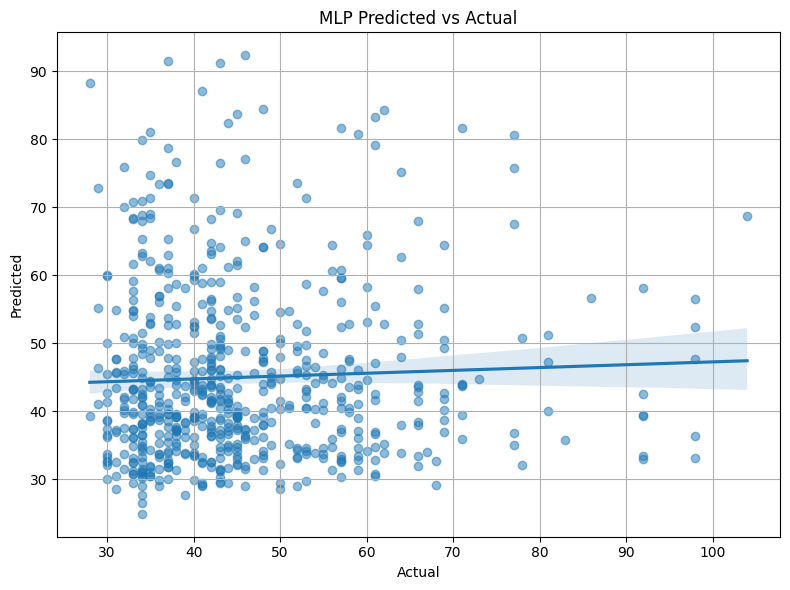

In [210]:
# Flatten y_holdout and predictions
y_holdout = y_holdout_b.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

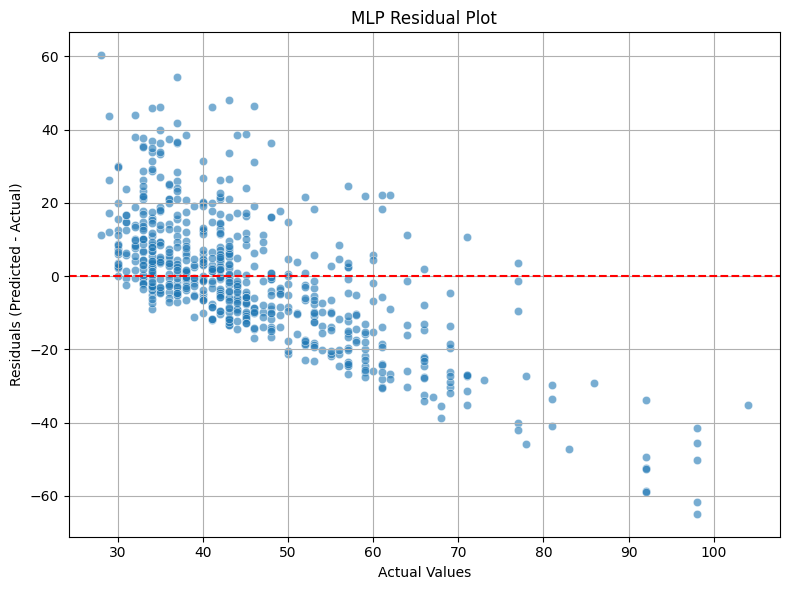

In [211]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [223]:
gwas_loc= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc.head()

,Chr1_131286,Chr1_132416,Chr1_249303,Chr1_360737,Chr1_898070,Chr1_1073992,Chr1_1167769,Chr1_2450278,Chr1_2547160,Chr1_3514585,...,Chr20_49306170,Chr20_51594636,Chr20_52108115,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,2,0,1,2,...,1,1,2,1,0,0,0,0,0,1
s100,0,0,0,0,0,0,2,0,1,2,...,1,1,2,0,1,0,0,0,0,1
s100,0,0,0,0,0,0,2,0,1,2,...,1,1,2,0,0,1,0,0,0,1
s101,0,0,0,0,0,0,1,2,0,0,...,1,1,0,0,0,0,0,1,0,1
s1014,0,0,0,0,0,2,2,0,1,2,...,0,0,0,1,0,0,0,0,0,1


In [224]:
gwas_loc_dupe= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc_dupe.head()

,Chr1_131286,Chr1_132416,Chr1_249303,Chr1_360737,Chr1_898070,Chr1_1073992,Chr1_1167769,Chr1_2450278,Chr1_2547160,Chr1_3514585,...,Chr20_49306170,Chr20_51594636,Chr20_52108115,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,2,0,1,2,...,1,1,2,1,0,0,0,0,0,1
s100,0,0,0,0,0,0,2,0,1,2,...,1,1,2,0,1,0,0,0,0,1
s100,0,0,0,0,0,0,2,0,1,2,...,1,1,2,0,0,1,0,0,0,1
s101,0,0,0,0,0,0,1,2,0,0,...,1,1,0,0,0,0,0,1,0,1
s1014,0,0,0,0,0,2,2,0,1,2,...,0,0,0,1,0,0,0,0,0,1


In [225]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 2519 entries, Chr1_131286 to landrace
dtypes: int64(2519)
memory usage: 48.8+ MB


In [226]:
gwas_y = gwas_data.iloc[:, 2523:]
gwas_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s101,53
s1014,77


In [227]:
X_tensor = torch.tensor(gwas_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [228]:
print(X_tensor.shape)

torch.Size([2536, 2519])


In [229]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [230]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-22 15:53:52,002] A new study created in memory with name: no-name-1ab42de2-3866-4fe3-8bad-e388738b878c
[I 2025-05-22 15:53:59,903] Trial 0 finished with value: 54.1500129699707 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout1': 0.011040526713025264, 'dropout2': 0.08299912593437699, 'lr': 0.0005061205966306113, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 11, 'weight_decay': 3.963265743192409e-05}. Best is trial 0 with value: 54.1500129699707.
[I 2025-05-22 15:54:01,589] Trial 1 finished with value: 1578.5435791015625 and parameters: {'hidden_size1': 300, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout1': 0.03095746831700759, 'dropout2': 0.033019845066183426, 'lr': 0.0012204946621893317, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 8, 'weight_decay': 0.0033190934611848537}. Best is trial 0 with value: 54.1500129699707.
[I 2025-05-22 15:54:02,357] Trial 2 finished with value: 203.127456665

Early stopping at epoch 22


[I 2025-05-22 15:54:03,001] Trial 3 finished with value: 126.03254699707031 and parameters: {'hidden_size1': 300, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout1': 0.08048578685919765, 'dropout2': 0.053259762268749074, 'lr': 0.0006418219388953193, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 5, 'weight_decay': 0.004730165854028754}. Best is trial 0 with value: 54.1500129699707.


Early stopping at epoch 6


[I 2025-05-22 15:54:03,702] Trial 4 finished with value: 134.25064086914062 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout1': 0.03661992073330001, 'dropout2': 0.04237424474726575, 'lr': 0.00047410290491926654, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 10, 'weight_decay': 5.409688962882653e-05}. Best is trial 0 with value: 54.1500129699707.


...

Early stopping at epoch 27


[I 2025-05-22 15:56:23,537] Trial 39 finished with value: 46.134002685546875 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout1': 0.08954971805660557, 'dropout2': 0.04558421625400431, 'lr': 0.0012632805806688575, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 9, 'weight_decay': 0.001032027077209821}. Best is trial 33 with value: 38.18703079223633.
[I 2025-05-22 15:56:24,695] Trial 40 finished with value: 84.01567077636719 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout1': 0.0948507433220432, 'dropout2': 0.03490444203712403, 'lr': 0.0003963005385488561, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 7, 'weight_decay': 0.006531625240149081}. Best is trial 33 with value: 38.18703079223633.
[I 2025-05-22 15:56:29,225] Trial 41 finished with value: 36.418792724609375 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.07855997355

Early stopping at epoch 6


[I 2025-05-22 15:56:46,690] Trial 45 finished with value: 33.83302307128906 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.07400945052702392, 'dropout2': 0.01588039735943025, 'lr': 0.00017960124638941377, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 7, 'weight_decay': 0.0009151329307659062}. Best is trial 45 with value: 33.83302307128906.
[I 2025-05-22 15:56:54,696] Trial 46 finished with value: 38.40985107421875 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout1': 0.08858984081725416, 'dropout2': 0.02165829807016159, 'lr': 0.00017255263305736938, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 7, 'weight_decay': 0.00013378428353983497}. Best is trial 45 with value: 33.83302307128906.
[I 2025-05-22 15:57:02,902] Trial 47 finished with value: 37.439231872558594 and parameters: {'hidden_size1': 200, 'hidden_size2': 150, 'hidden_size3': 75, 'dropout1': 0.0883502

Early stopping at epoch 14
Best hyperparameters: {'hidden_size1': 200, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout1': 0.07400945052702392, 'dropout2': 0.01588039735943025, 'lr': 0.00017960124638941377, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 7, 'weight_decay': 0.0009151329307659062}


In [231]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top1_best_model_onlyloc_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 40.4679
Training fold 2
Fold 2 validation loss: 41.7707
Training fold 3
Fold 3 validation loss: 44.7134
Training fold 4
Fold 4 validation loss: 59.8232
Training fold 5
Fold 5 validation loss: 48.7091
Training fold 6
Fold 6 validation loss: 60.6039
Training fold 7
Fold 7 validation loss: 57.7367
Training fold 8
Fold 8 validation loss: 46.4053
Training fold 9
Fold 9 validation loss: 47.0719
Training fold 10
Fold 10 validation loss: 45.2347

Average validation loss across all folds: 49.2537
Checkpoint saved as 'gwas_top1_best_model_onlyloc_mlp_bbd.pth'.


In [232]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [233]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [234]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [235]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [236]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [237]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 2519 entries, Chr1_131286 to landrace
dtypes: int64(2519)
memory usage: 12.2+ MB


In [238]:
X_holdout.head()

,Chr1_131286,Chr1_132416,Chr1_249303,Chr1_360737,Chr1_898070,Chr1_1073992,Chr1_1167769,Chr1_2450278,Chr1_2547160,Chr1_3514585,...,Chr20_49306170,Chr20_51594636,Chr20_52108115,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,2,2,0,1,2,...,0,0,0,0,0,1,0,0,0,1
s101,0,0,0,0,0,0,1,2,0,0,...,1,1,0,1,0,0,0,0,0,1
s101,0,0,0,0,0,0,1,2,0,0,...,1,1,0,0,0,0,1,0,0,1
s1026,1,0,0,0,2,2,2,0,0,0,...,0,2,0,0,0,0,0,1,0,1
s1030,1,1,0,0,0,2,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1


In [239]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [241]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 66.4187
RMSE: 8.1498
MAE: 5.5789
R2: 0.6548
Holdout_Loss: 66.4187


In [242]:
pickle.dump(best_mlp_model, open("'gwas_top1_best_model_onlyloc_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 42 40.269722
1 42 58.297554
2 32 74.171844
3 56 57.670433
4 32 38.37602
5 48 40.446045


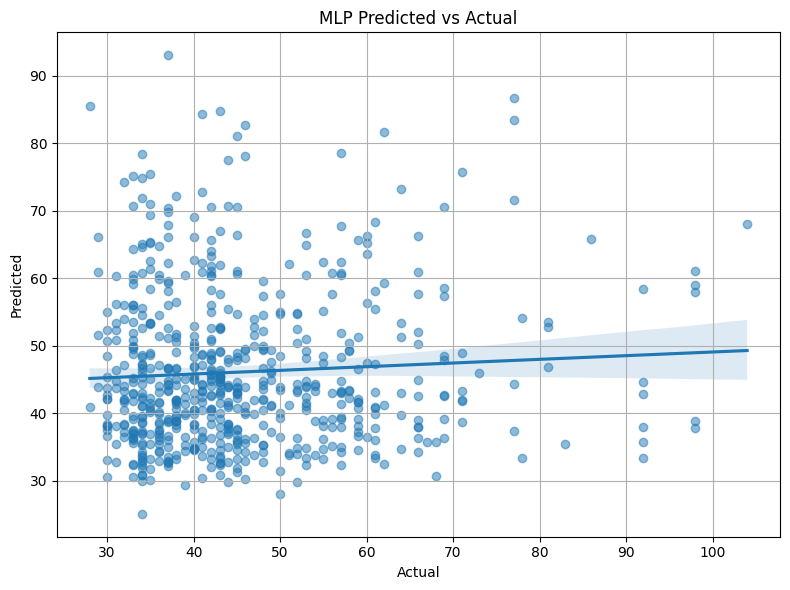

In [243]:
# Flatten y_holdout and predictions
y_holdout = y_holdout_b.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

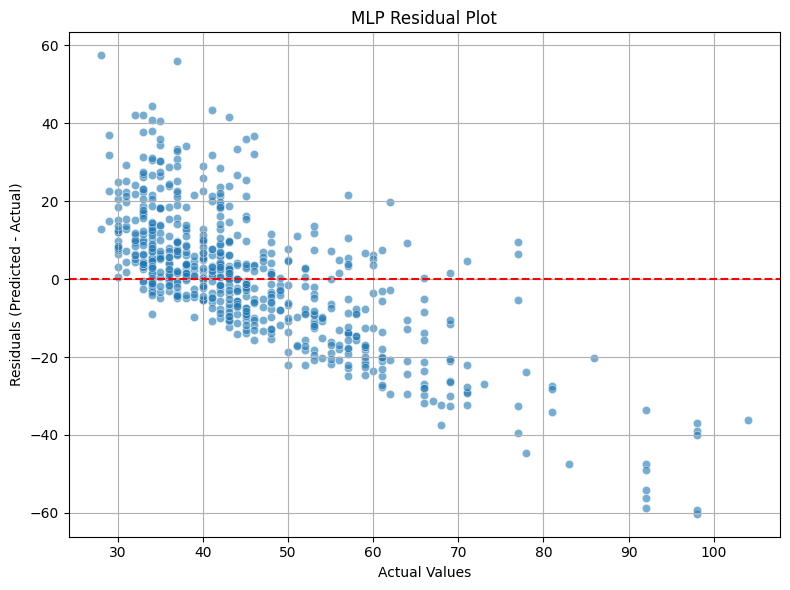

In [244]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [10]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 2524 entries, Chr1_131286 to BBD
dtypes: float64(4), int64(2520)
memory usage: 48.9+ MB


In [11]:
gwas_snps = gwas_data.iloc[:, 0:2512]
gwas_snps.head()

,Chr1_131286,Chr1_132416,Chr1_249303,Chr1_360737,Chr1_898070,Chr1_1073992,Chr1_1167769,Chr1_2450278,Chr1_2547160,Chr1_3514585,...,Chr20_46034351,Chr20_46061949,Chr20_46173715,Chr20_47083417,Chr20_47470601,Chr20_48641652,Chr20_49262341,Chr20_49306170,Chr20_51594636,Chr20_52108115
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,2,0,1,2,...,0,0,0,0,0,2,0,1,1,2
s100,0,0,0,0,0,0,2,0,1,2,...,0,0,0,0,0,2,0,1,1,2
s100,0,0,0,0,0,0,2,0,1,2,...,0,0,0,0,0,2,0,1,1,2
s101,0,0,0,0,0,0,1,2,0,0,...,0,0,0,0,0,0,0,1,1,0
s1014,0,0,0,0,0,2,2,0,1,2,...,2,0,0,0,0,0,0,0,0,0


In [12]:
gwas_snps_dupe = gwas_data.iloc[:, 0:2512]
gwas_snps_dupe.head()

,Chr1_131286,Chr1_132416,Chr1_249303,Chr1_360737,Chr1_898070,Chr1_1073992,Chr1_1167769,Chr1_2450278,Chr1_2547160,Chr1_3514585,...,Chr20_46034351,Chr20_46061949,Chr20_46173715,Chr20_47083417,Chr20_47470601,Chr20_48641652,Chr20_49262341,Chr20_49306170,Chr20_51594636,Chr20_52108115
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,2,0,1,2,...,0,0,0,0,0,2,0,1,1,2
s100,0,0,0,0,0,0,2,0,1,2,...,0,0,0,0,0,2,0,1,1,2
s100,0,0,0,0,0,0,2,0,1,2,...,0,0,0,0,0,2,0,1,1,2
s101,0,0,0,0,0,0,1,2,0,0,...,0,0,0,0,0,0,0,1,1,0
s1014,0,0,0,0,0,2,2,0,1,2,...,2,0,0,0,0,0,0,0,0,0


In [13]:
gwas_y = gwas_data.iloc[:, 2523:]
gwas_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s101,53
s1014,77


In [14]:
X_tensor = torch.tensor(gwas_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [15]:
print(X_tensor.shape)

torch.Size([2536, 2512])


In [16]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [17]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-22 16:23:48,480] A new study created in memory with name: no-name-ebd37c28-2f53-4e7d-bf8e-2432e1c752f4
[I 2025-05-22 16:23:52,996] Trial 0 finished with value: 153.5504913330078 and parameters: {'hidden_size1': 100, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout1': 0.06643111795937892, 'dropout2': 0.020136851362263043, 'lr': 0.0002716561188778978, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 13, 'weight_decay': 0.004828612186134076}. Best is trial 0 with value: 153.5504913330078.


Early stopping at epoch 21


[I 2025-05-22 16:23:53,509] Trial 1 finished with value: 166.90830993652344 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout1': 0.043937064323445844, 'dropout2': 0.03569791622578909, 'lr': 0.00038193556663038695, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 5, 'weight_decay': 9.410745411484818e-05}. Best is trial 0 with value: 153.5504913330078.


Early stopping at epoch 15


[I 2025-05-22 16:23:54,492] Trial 2 finished with value: 2173.520263671875 and parameters: {'hidden_size1': 100, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout1': 0.013789632445619858, 'dropout2': 0.03430882531077291, 'lr': 0.00032086026312997095, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 12, 'weight_decay': 0.0002476218480615753}. Best is trial 0 with value: 153.5504913330078.
[I 2025-05-22 16:23:56,575] Trial 3 finished with value: 164.16860961914062 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'hidden_size3': 75, 'dropout1': 0.021839621460396228, 'dropout2': 0.06627810779211181, 'lr': 0.0009641928305976919, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 13, 'weight_decay': 1.952403983436294e-05}. Best is trial 0 with value: 153.5504913330078.


...

Early stopping at epoch 32


[I 2025-05-22 16:26:40,242] Trial 46 finished with value: 130.9831085205078 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.08510268420229927, 'dropout2': 0.08262120272789693, 'lr': 0.005462419537666098, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 9, 'weight_decay': 0.0008926921011015022}. Best is trial 32 with value: 128.93966674804688.
[I 2025-05-22 16:26:45,182] Trial 47 finished with value: 129.10694885253906 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.0925692124470931, 'dropout2': 0.07752316786718265, 'lr': 0.003994988163097711, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 7, 'weight_decay': 0.0003111071906154782}. Best is trial 32 with value: 128.93966674804688.
[I 2025-05-22 16:26:47,256] Trial 48 finished with value: 170.00613403320312 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout1': 0.094103002505711

Early stopping at epoch 20


[I 2025-05-22 16:26:50,230] Trial 49 finished with value: 129.5373992919922 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.08928928754562132, 'dropout2': 0.04558408542107849, 'lr': 0.007405898901870219, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 6, 'weight_decay': 0.0026572992134497007}. Best is trial 32 with value: 128.93966674804688.


Best hyperparameters: {'hidden_size1': 200, 'hidden_size2': 50, 'hidden_size3': 25, 'dropout1': 0.07972932086710656, 'dropout2': 0.09046130632934613, 'lr': 0.003743832499312792, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 8, 'weight_decay': 0.00445009293116306}


In [18]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top1_best_model_onlysnps_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 184.9530
Training fold 2
Fold 2 validation loss: 209.9149
Training fold 3
Fold 3 validation loss: 207.6921
Training fold 4
Fold 4 validation loss: 241.2464
Training fold 5
Fold 5 validation loss: 189.5978
Training fold 6
Fold 6 validation loss: 255.3397
Training fold 7
Fold 7 validation loss: 243.9576
Training fold 8
Fold 8 validation loss: 226.1208
Training fold 9
Fold 9 validation loss: 202.0996
Training fold 10
Fold 10 validation loss: 211.5933

Average validation loss across all folds: 217.2515
Checkpoint saved as 'gwas_top1_best_model_onlysnps_mlp_bbd.pth'.


In [19]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [20]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [21]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [22]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [23]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [24]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 254.1486
RMSE: 15.9420
MAE: 11.7436
R2: -0.3210
Holdout_Loss: 254.1486


In [25]:
pickle.dump(best_mlp_model, open("gwas_top1_best_model_onlysnps_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

## Top 5% SNPs

In [120]:
# Build model with best hyperparameters
def build_model(input_size, params):
    return nn.Sequential(
        nn.Linear(input_size, params['hidden_size1']),
        nn.ReLU(),
        nn.Dropout(params['dropout1']),
        nn.Linear(params['hidden_size1'], params['hidden_size2']),
        nn.ReLU(),
        nn.Linear(params['hidden_size2'], 1)
    )
    return nn.Sequential(*layers)

In [121]:
# 1. Define a training function for Optuna to optimize parameters
def objective(trial):
    # Suggest hyperparameters
    params = {
            'hidden_size1': trial.suggest_categorical('hidden_size1', [100, 200, 300]),
            'hidden_size2': trial.suggest_categorical('hidden_size2', [25, 50, 100]),
            #'hidden_size3': trial.suggest_categorical('hidden_size3', [25, 50, 75]),
            #'hidden_size1': trial.suggest_int('hidden_size1', 64, 256, step=32),
            #'hidden_size2': trial.suggest_int('hidden_size2', 32, 128, step=16),
            #'hidden_size3': trial.suggest_int('hidden_size3', 32, 128, step=16),
            'dropout1': trial.suggest_float('dropout1', 0.01, 0.1),
            #'dropout2': trial.suggest_float('dropout2', 0.01, 0.1),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128]),
            'optimizer': trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD']),
            'num_epochs': trial.suggest_categorical('num_epochs', [30, 50, 70]),
            'patience': trial.suggest_int('patience', 5, 15),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
        }
    # Build model
    model = build_model(X_train.shape[1], params).to(device)
    optimizer = getattr(optim, params['optimizer'])(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay']
    )
    loss_function = nn.MSELoss()
    early_stopping = EarlyStopping(patience=params['patience'])

    # Prepare data
    #X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    #y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    #X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    #y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)

    val_losses = []  # <-- Initialize here

    for epoch in range(params['num_epochs']):
        # Training
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = loss_function(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Validation (after each epoch)
        model.eval()
        with torch.no_grad():
            preds = model(X_val).cpu().numpy()
            true = y_val.cpu().numpy()
            val_loss = loss_function(torch.tensor(preds), y_val.cpu())
            val_losses.append(val_loss.item())

        avg_val_loss = np.mean(val_losses[-5:])  # average of last 5 epochs for stability
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    mse = mean_squared_error(true, preds)
    return mse  # Optuna minimizes this

    #HOW TO USE - create study and then optimise

### All covariates

In [122]:
gwas_data = pd.read_pickle("pickle_files/GWAS_top5percent_bbd_data.pkl")
gwas_data.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,0,0,0,0,0,0,0,2,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,0,0,0,0,0,0,0,2,...,116.000,3.40000,0,0,1,0,0,0,1,43
s101,1,0,0,0,0,0,1,0,0,0,...,58.000,2.60000,0,0,0,0,1,0,1,53
s1014,0,0,0,0,0,0,0,0,0,1,...,111.733,8.66667,1,0,0,0,0,0,1,77


In [123]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 12573 entries, Chr1_124994 to BBD
dtypes: float64(4), int64(12569)
memory usage: 243.3+ MB


In [124]:
gwas_y = gwas_data.iloc[:, 12572:]
gwas_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s101,53
s1014,77


In [125]:
gwas_all= gwas_data.drop(['BBD'], axis=1)
gwas_all.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s101,1,0,0,0,0,0,1,0,0,0,...,9.97400,58.000,2.60000,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,1,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1


In [126]:
gwas_all_dupe= gwas_data.drop(['BBD'], axis=1)
gwas_all_dupe.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s101,1,0,0,0,0,0,1,0,0,0,...,9.97400,58.000,2.60000,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,1,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1


In [127]:
X_tensor = torch.tensor(gwas_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [128]:
print(X_tensor.shape)

torch.Size([2536, 12572])


In [129]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [130]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-23 11:49:39,545] A new study created in memory with name: no-name-8fd2c8e7-81b6-46aa-befd-595cbade4383
[I 2025-05-23 11:49:40,132] Trial 0 finished with value: 125.10358428955078 and parameters: {'hidden_size1': 100, 'hidden_size2': 25, 'dropout1': 0.08630429547357224, 'lr': 0.0012333442873691744, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 5, 'weight_decay': 0.00010710942756888476}. Best is trial 0 with value: 125.10358428955078.


Early stopping at epoch 11


[I 2025-05-23 11:49:40,631] Trial 1 finished with value: 130.88418579101562 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'dropout1': 0.01960961579478042, 'lr': 0.002808981339937309, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 7, 'weight_decay': 0.000632010741235935}. Best is trial 0 with value: 125.10358428955078.


Early stopping at epoch 16


[I 2025-05-23 11:49:42,123] Trial 2 finished with value: 113.13243865966797 and parameters: {'hidden_size1': 100, 'hidden_size2': 100, 'dropout1': 0.013998424508321158, 'lr': 0.0009760736063502679, 'batch_size': 64, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 14, 'weight_decay': 0.0009786870599838226}. Best is trial 2 with value: 113.13243865966797.
[I 2025-05-23 11:49:43,790] Trial 3 finished with value: 112.7115707397461 and parameters: {'hidden_size1': 100, 'hidden_size2': 100, 'dropout1': 0.013814193193793999, 'lr': 0.0008929170719829653, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 6, 'weight_decay': 0.004085698721572085}. Best is trial 3 with value: 112.7115707397461.


...

Early stopping at epoch 18


[I 2025-05-23 11:51:54,875] Trial 48 finished with value: 98.18622589111328 and parameters: {'hidden_size1': 300, 'hidden_size2': 25, 'dropout1': 0.0371265545927658, 'lr': 0.0007028717827953053, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 13, 'weight_decay': 0.0007245977718134382}. Best is trial 26 with value: 87.6638412475586.


Early stopping at epoch 36


[I 2025-05-23 11:51:55,852] Trial 49 finished with value: 120.25186920166016 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.022606249420337864, 'lr': 0.002315728633430445, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 11, 'weight_decay': 0.007573331467862751}. Best is trial 26 with value: 87.6638412475586.


Early stopping at epoch 30
Best hyperparameters: {'hidden_size1': 300, 'hidden_size2': 25, 'dropout1': 0.046639013602764075, 'lr': 0.0003531798679406801, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 12, 'weight_decay': 0.0007710578617687192}


In [136]:
#Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top5_best_model_allfeats_mlp_bbd_test.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 87.3118
Training fold 2
Early stopping at epoch 16 for fold 2
Fold 2 validation loss: 113.1847
Training fold 3
Early stopping at epoch 15 for fold 3
Fold 3 validation loss: 108.9948
Training fold 4
Early stopping at epoch 15 for fold 4
Fold 4 validation loss: 124.9121
Training fold 5
Fold 5 validation loss: 94.2159
Training fold 6
Early stopping at epoch 36 for fold 6
Fold 6 validation loss: 129.0333
Training fold 7
Early stopping at epoch 44 for fold 7
Fold 7 validation loss: 115.6379
Training fold 8
Fold 8 validation loss: 88.3072
Training fold 9
Fold 9 validation loss: 90.7188
Training fold 10
Fold 10 validation loss: 85.9257

Average validation loss across all folds: 103.8242
Checkpoint saved as 'gwas_top5_best_model_allfeats_mlp_bbd_test.pth'.


In [137]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [138]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [139]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [140]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [141]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [142]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 12572 entries, Chr1_124994 to landrace
dtypes: float64(4), int64(12568)
memory usage: 60.8+ MB


In [143]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [144]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 122.7757
RMSE: 11.0804
MAE: 7.6466
R2: 0.3618
Holdout_Loss: 122.7757


In [145]:
pickle.dump(best_mlp_model, open("gwas_top5_best_model_allfeats_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 45 55.078903
1 39 63.559875
2 62 73.72518
3 47 81.35379
4 42 42.096718
5 40 42.02786


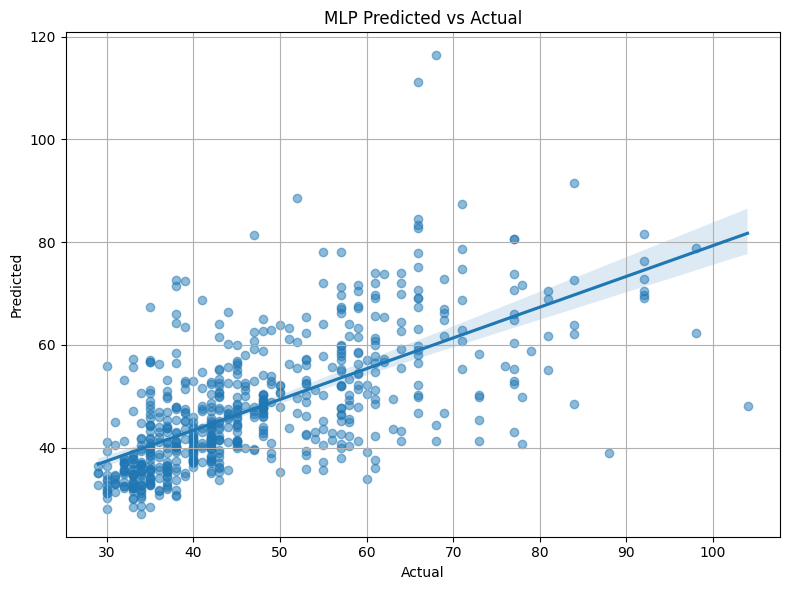

In [146]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

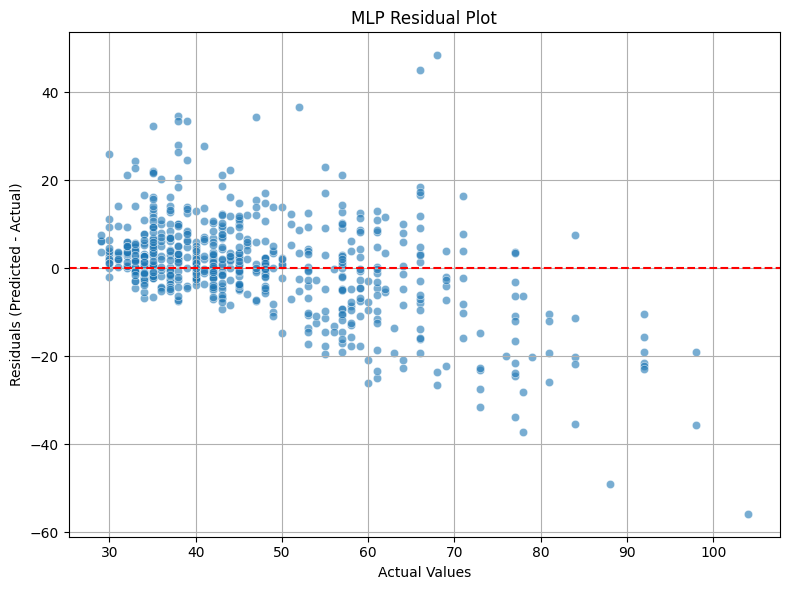

In [147]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [107]:
gwas_loc= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,Chr20_51977670,Chr20_52108115,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,0,2,1,1,0,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,0,2,1,0,1,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,0,2,1,0,0,1,0,0,0,1
s101,1,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1


In [108]:
gwas_loc_dupe= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc_dupe.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,Chr20_51977670,Chr20_52108115,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,0,2,1,1,0,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,0,2,1,0,1,0,0,0,0,1
s100,0,0,0,0,0,0,0,0,0,2,...,0,2,1,0,0,1,0,0,0,1
s101,1,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,1,...,0,0,0,1,0,0,0,0,0,1


In [109]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 12568 entries, Chr1_124994 to landrace
dtypes: int64(12568)
memory usage: 243.2+ MB


In [110]:
gwas_y = gwas_data.iloc[:, 12572:]
gwas_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s101,53
s1014,77


In [111]:
X_tensor = torch.tensor(gwas_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [112]:
print(X_tensor.shape)

torch.Size([2536, 12568])


In [113]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [121]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-22 17:30:20,177] A new study created in memory with name: no-name-4d7705d2-a4f3-4f9a-b598-97750c8d1895
[I 2025-05-22 17:30:24,387] Trial 0 finished with value: 123.0932388305664 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'dropout1': 0.050280775964927936, 'lr': 0.00473003873777632, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 10, 'weight_decay': 0.0033220610771212723}. Best is trial 0 with value: 123.0932388305664.


Early stopping at epoch 48


[I 2025-05-22 17:30:25,912] Trial 1 finished with value: 123.94509887695312 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'dropout1': 0.03167131330873057, 'lr': 0.008210047087572512, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 9, 'weight_decay': 0.0002258598319917401}. Best is trial 0 with value: 123.0932388305664.
[I 2025-05-22 17:30:28,509] Trial 2 finished with value: 1401.002197265625 and parameters: {'hidden_size1': 100, 'hidden_size2': 100, 'dropout1': 0.07363004406117203, 'lr': 0.0002706973154318343, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 8, 'weight_decay': 0.0003148987196569036}. Best is trial 0 with value: 123.0932388305664.
[I 2025-05-22 17:30:30,031] Trial 3 finished with value: 2123.77783203125 and parameters: {'hidden_size1': 200, 'hidden_size2': 25, 'dropout1': 0.08023640547943395, 'lr': 0.00011785943316590234, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 15, 'weight_decay': 3.39866

Early stopping at epoch 19


[I 2025-05-22 17:30:41,528] Trial 10 finished with value: 129.3689422607422 and parameters: {'hidden_size1': 300, 'hidden_size2': 25, 'dropout1': 0.05141299948147753, 'lr': 0.0012725698218843007, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 7, 'weight_decay': 0.006053427205130098}. Best is trial 0 with value: 123.0932388305664.


...

Early stopping at epoch 13


[I 2025-05-22 17:31:57,467] Trial 48 finished with value: 123.92582702636719 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'dropout1': 0.06409477842783051, 'lr': 0.008475771969385034, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 7, 'weight_decay': 7.374041362219996e-05}. Best is trial 25 with value: 121.04270935058594.


Early stopping at epoch 51


[I 2025-05-22 17:32:03,493] Trial 49 finished with value: 129.58433532714844 and parameters: {'hidden_size1': 100, 'hidden_size2': 100, 'dropout1': 0.05483306858143051, 'lr': 0.000990457242482203, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 11, 'weight_decay': 2.383643308857167e-05}. Best is trial 25 with value: 121.04270935058594.


Best hyperparameters: {'hidden_size1': 200, 'hidden_size2': 50, 'dropout1': 0.06718523290860283, 'lr': 0.00734592011737965, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 11, 'weight_decay': 1.9930046436667853e-05}


In [122]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top5_best_model_onlyloc_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 113.9651
Training fold 2
Fold 2 validation loss: 154.2385
Training fold 3
Fold 3 validation loss: 147.7258
Training fold 4
Fold 4 validation loss: 164.6105
Training fold 5
Fold 5 validation loss: 117.4083
Training fold 6
Fold 6 validation loss: 175.2470
Training fold 7
Fold 7 validation loss: 149.8608
Training fold 8
Fold 8 validation loss: 147.9938
Training fold 9
Fold 9 validation loss: 130.2578
Training fold 10
Fold 10 validation loss: 137.1749

Average validation loss across all folds: 143.8483
Checkpoint saved as 'gwas_top5_best_model_onlyloc_mlp_bbd.pth'.


In [123]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [124]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [125]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [126]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 12568 entries, Chr1_124994 to landrace
dtypes: int64(12568)
memory usage: 60.8+ MB


In [127]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [128]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 153.2555
RMSE: 12.3796
MAE: 8.6477
R2: 0.2034
Holdout_Loss: 153.2556


In [129]:
pickle.dump(best_mlp_model, open("'gwas_top5_best_model_onlyloc_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 45 55.480446
1 39 59.242935
2 62 56.97025
3 47 70.92013
4 42 38.4382
5 40 41.764175


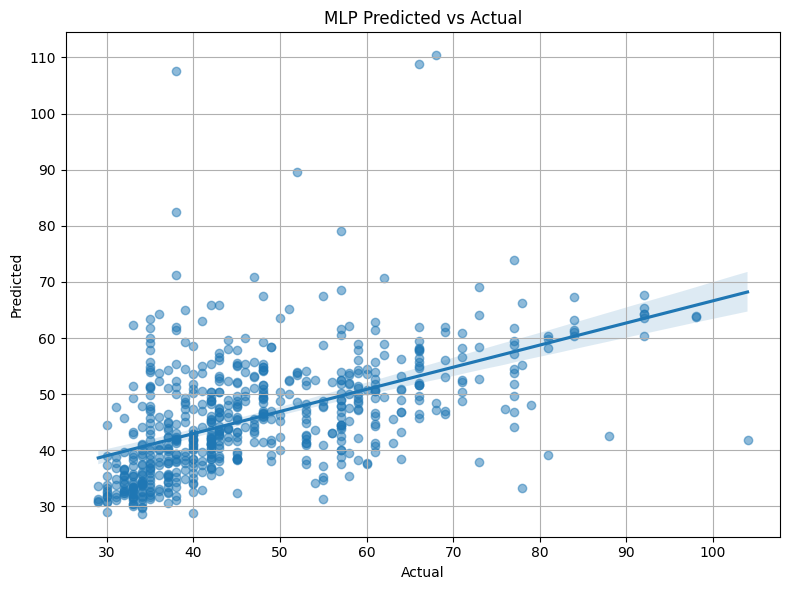

In [130]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

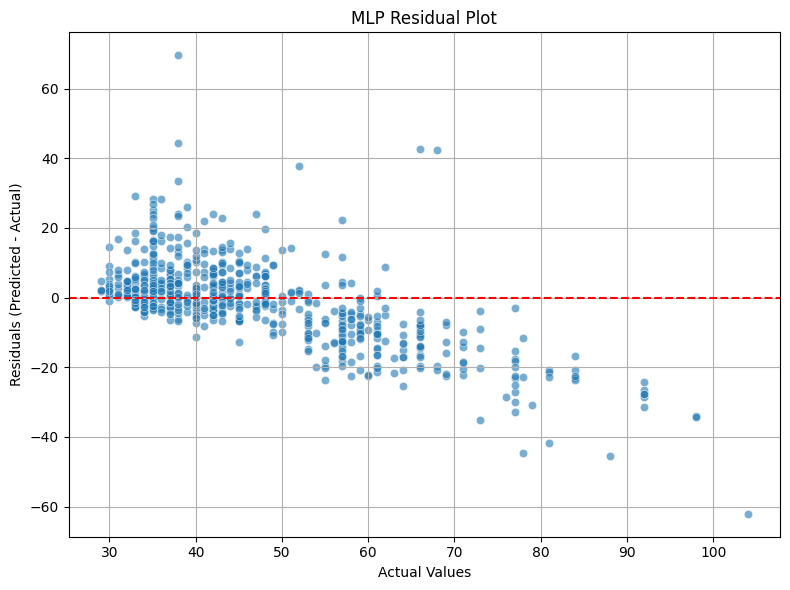

In [131]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [132]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 12573 entries, Chr1_124994 to BBD
dtypes: float64(4), int64(12569)
memory usage: 243.3+ MB


In [135]:
gwas_snps = gwas_data.iloc[:, 0:12561]
gwas_snps.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,Chr20_51494122,Chr20_51594636,Chr20_51666785,Chr20_51684283,Chr20_51840551,Chr20_51859725,Chr20_51891017,Chr20_51977670,Chr20_52108115,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,2,1,0,2,0,0,0,0,2,1
s100,0,0,0,0,0,0,0,0,0,2,...,2,1,0,2,0,0,0,0,2,1
s100,0,0,0,0,0,0,0,0,0,2,...,2,1,0,2,0,0,0,0,2,1
s101,1,0,0,0,0,0,1,0,0,0,...,2,1,1,2,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [136]:
gwas_snps_dupe = gwas_data.iloc[:, 0:12561]
gwas_snps_dupe.head()

,Chr1_124994,Chr1_131286,Chr1_131374,Chr1_132094,Chr1_132416,Chr1_171769,Chr1_212835,Chr1_237460,Chr1_249303,Chr1_345210,...,Chr20_51494122,Chr20_51594636,Chr20_51666785,Chr20_51684283,Chr20_51840551,Chr20_51859725,Chr20_51891017,Chr20_51977670,Chr20_52108115,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,0,0,0,0,0,2,...,2,1,0,2,0,0,0,0,2,1
s100,0,0,0,0,0,0,0,0,0,2,...,2,1,0,2,0,0,0,0,2,1
s100,0,0,0,0,0,0,0,0,0,2,...,2,1,0,2,0,0,0,0,2,1
s101,1,0,0,0,0,0,1,0,0,0,...,2,1,1,2,0,1,0,0,0,1
s1014,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [137]:
gwas_y = gwas_data.iloc[:, 12572:]
gwas_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s101,53
s1014,77


In [138]:
X_tensor = torch.tensor(gwas_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [139]:
print(X_tensor.shape)

torch.Size([2536, 12561])


In [140]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [141]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-22 17:33:57,916] A new study created in memory with name: no-name-7486e87d-78a7-4621-8a32-89e6eeca29a5
[I 2025-05-22 17:33:59,024] Trial 0 finished with value: 202.71148681640625 and parameters: {'hidden_size1': 300, 'hidden_size2': 50, 'dropout1': 0.04763649724958004, 'lr': 0.0023050117945029687, 'batch_size': 64, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 8, 'weight_decay': 0.0024886241647223474}. Best is trial 0 with value: 202.71148681640625.


Early stopping at epoch 21


[I 2025-05-22 17:33:59,964] Trial 1 finished with value: 198.60951232910156 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'dropout1': 0.09476217392177687, 'lr': 0.003444332070041673, 'batch_size': 64, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 14, 'weight_decay': 0.0005478502608347887}. Best is trial 1 with value: 198.60951232910156.


Early stopping at epoch 18


[I 2025-05-22 17:34:00,469] Trial 2 finished with value: 151.90179443359375 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'dropout1': 0.037031467268075935, 'lr': 0.0039203413764408, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 5, 'weight_decay': 0.0005770823895094155}. Best is trial 2 with value: 151.90179443359375.


...

Early stopping at epoch 15


[I 2025-05-22 17:35:20,269] Trial 47 finished with value: 339.7118835449219 and parameters: {'hidden_size1': 100, 'hidden_size2': 100, 'dropout1': 0.020884009536398324, 'lr': 0.0003220970575736173, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 10, 'weight_decay': 1.3648318204413179e-05}. Best is trial 43 with value: 132.80975341796875.
[I 2025-05-22 17:35:21,025] Trial 48 finished with value: 130.0536651611328 and parameters: {'hidden_size1': 100, 'hidden_size2': 25, 'dropout1': 0.015209022094856034, 'lr': 0.00019942353871204292, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 7, 'weight_decay': 4.20237671712669e-05}. Best is trial 48 with value: 130.0536651611328.


Early stopping at epoch 23


[I 2025-05-22 17:35:21,596] Trial 49 finished with value: 134.27674865722656 and parameters: {'hidden_size1': 100, 'hidden_size2': 25, 'dropout1': 0.05860512464213768, 'lr': 0.00022711947699781922, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 7, 'weight_decay': 8.351551205907521e-05}. Best is trial 48 with value: 130.0536651611328.


Early stopping at epoch 18
Best hyperparameters: {'hidden_size1': 100, 'hidden_size2': 25, 'dropout1': 0.015209022094856034, 'lr': 0.00019942353871204292, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 7, 'weight_decay': 4.20237671712669e-05}


In [142]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top5_best_model_onlysnps_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 167.2417
Training fold 2
Fold 2 validation loss: 217.8420
Training fold 3
Fold 3 validation loss: 204.5912
Training fold 4
Fold 4 validation loss: 206.8784
Training fold 5
Fold 5 validation loss: 195.3042
Training fold 6
Fold 6 validation loss: 237.6617
Training fold 7
Fold 7 validation loss: 207.0595
Training fold 8
Fold 8 validation loss: 194.2518
Training fold 9
Fold 9 validation loss: 188.3734
Training fold 10
Fold 10 validation loss: 198.1508

Average validation loss across all folds: 201.7355
Checkpoint saved as 'gwas_top5_best_model_onlysnps_mlp_bbd.pth'.


In [143]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [144]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [146]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [147]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [148]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 239.2325
RMSE: 15.4671
MAE: 11.4700
R2: -0.2435
Holdout_Loss: 239.2325


In [149]:
pickle.dump(best_mlp_model, open("gwas_top5_best_model_onlysnps_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 45 54.01437
1 39 50.365093
2 62 50.365093
3 47 70.85473
4 42 39.042187
5 40 41.793972


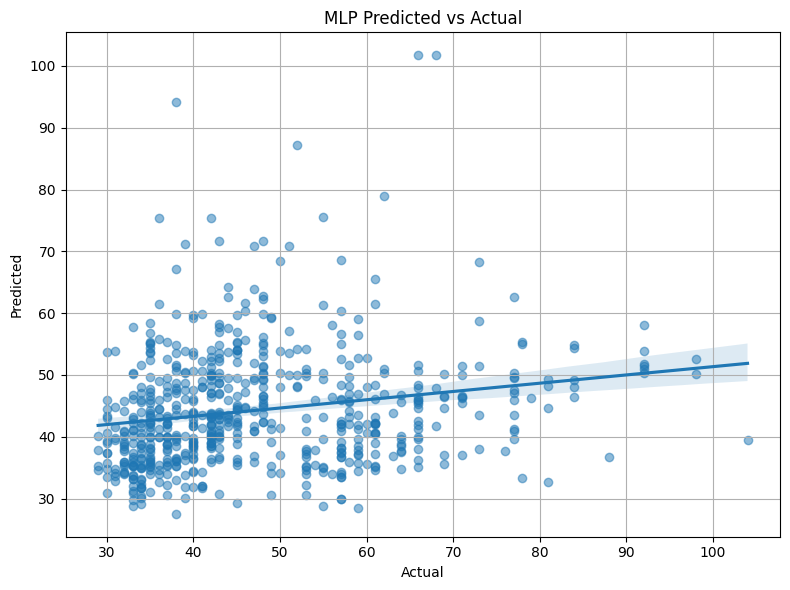

In [151]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

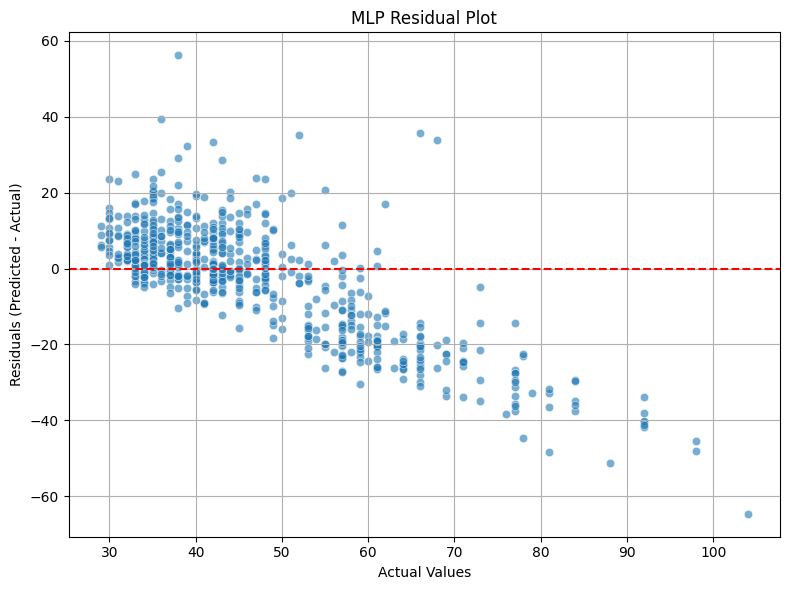

In [152]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

## Top 10% SNPs

In [148]:
gwas_data = pd.read_pickle("pickle_files/GWAS_top10percent_bbd_data.pkl")
gwas_data.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,1,1,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,0,1,1,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,0,1,1,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s101,0,0,0,0,0,1,0,0,0,0,...,58.000,2.60000,0,0,0,0,1,0,1,53
s1014,0,0,0,0,0,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77


In [149]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 25135 entries, Chr1_24345 to BBD
dtypes: float64(4), int64(25131)
memory usage: 486.3+ MB


In [150]:
gwas_y = gwas_data.iloc[:, 25134:]
gwas_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s101,53
s1014,77


In [151]:
# Build model with best hyperparameters
def build_model(input_size, params):
    return nn.Sequential(
        nn.Linear(input_size, params['hidden_size1']),
        nn.ReLU(),
        nn.Dropout(params['dropout1']),
        nn.Linear(params['hidden_size1'], params['hidden_size2']),
        nn.ReLU(),
        nn.Linear(params['hidden_size2'], 1)
    )
    return nn.Sequential(*layers)

In [152]:
# 1. Define a training function for Optuna to optimize parameters
def objective(trial):
    # Suggest hyperparameters
    params = {
            'hidden_size1': trial.suggest_categorical('hidden_size1', [100, 200, 300]),
            'hidden_size2': trial.suggest_categorical('hidden_size2', [25, 50, 100]),
            #'hidden_size3': trial.suggest_categorical('hidden_size3', [25, 50, 75]),
            #'hidden_size1': trial.suggest_int('hidden_size1', 64, 256, step=32),
            #'hidden_size2': trial.suggest_int('hidden_size2', 32, 128, step=16),
            #'hidden_size3': trial.suggest_int('hidden_size3', 32, 128, step=16),
            'dropout1': trial.suggest_float('dropout1', 0.01, 0.1),
            #'dropout2': trial.suggest_float('dropout2', 0.01, 0.1),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128]),
            'optimizer': trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD']),
            'num_epochs': trial.suggest_categorical('num_epochs', [30, 50, 70]),
            'patience': trial.suggest_int('patience', 5, 15),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
        }
    # Build model
    model = build_model(X_train.shape[1], params).to(device)
    optimizer = getattr(optim, params['optimizer'])(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay']
    )
    loss_function = nn.MSELoss()
    early_stopping = EarlyStopping(patience=params['patience'])

    # Prepare data
    #X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    #y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    #X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    #y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)

    val_losses = []  # <-- Initialize here

    for epoch in range(params['num_epochs']):
        # Training
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = loss_function(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Validation (after each epoch)
        model.eval()
        with torch.no_grad():
            preds = model(X_val).cpu().numpy()
            true = y_val.cpu().numpy()
            val_loss = loss_function(torch.tensor(preds), y_val.cpu())
            val_losses.append(val_loss.item())

        avg_val_loss = np.mean(val_losses[-5:])  # average of last 5 epochs for stability
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    mse = mean_squared_error(true, preds)
    return mse  # Optuna minimizes this

    #HOW TO USE - create study and then optimise

### All covariates

In [153]:
gwas_all= gwas_data.drop(['BBD'], axis=1)
gwas_all.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,1,1,0,0,0,0,0,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,9.97400,58.000,2.60000,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1


In [154]:
gwas_all_dupe= gwas_data.drop(['BBD'], axis=1)
gwas_all_dupe.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,1,1,0,0,0,0,0,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,9.97400,58.000,2.60000,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1


In [155]:
X_tensor = torch.tensor(gwas_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [156]:
print(X_tensor.shape)

torch.Size([2536, 25134])


In [157]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [158]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-23 11:59:29,699] A new study created in memory with name: no-name-0a142f35-0121-400d-8c75-8aebe9dbdf31
[I 2025-05-23 11:59:33,327] Trial 0 finished with value: 113.96367645263672 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'dropout1': 0.01645328774404576, 'lr': 0.0009826449130799, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 7, 'weight_decay': 0.0022282759633926214}. Best is trial 0 with value: 113.96367645263672.


Early stopping at epoch 26


[I 2025-05-23 11:59:33,667] Trial 1 finished with value: 131.9110565185547 and parameters: {'hidden_size1': 200, 'hidden_size2': 25, 'dropout1': 0.027119121348475612, 'lr': 0.001025935189833454, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 7, 'weight_decay': 0.0030739633154066785}. Best is trial 0 with value: 113.96367645263672.


Early stopping at epoch 10


[I 2025-05-23 11:59:34,610] Trial 2 finished with value: 1801.7490234375 and parameters: {'hidden_size1': 300, 'hidden_size2': 25, 'dropout1': 0.05213905744857748, 'lr': 0.00046270799016491406, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 6, 'weight_decay': 0.00010984154304742436}. Best is trial 0 with value: 113.96367645263672.
[I 2025-05-23 11:59:35,080] Trial 3 finished with value: 153.52125549316406 and parameters: {'hidden_size1': 100, 'hidden_size2': 100, 'dropout1': 0.07412042268477284, 'lr': 0.0007199494360423512, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 7, 'weight_decay': 4.263781648092768e-05}. Best is trial 0 with value: 113.96367645263672.


...

Early stopping at epoch 63


[I 2025-05-23 12:01:23,418] Trial 42 finished with value: 93.14168548583984 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.07217164604285656, 'lr': 0.005255430800798591, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 13, 'weight_decay': 0.00118163013148874}. Best is trial 42 with value: 93.14168548583984.
[I 2025-05-23 12:01:26,850] Trial 43 finished with value: 96.14190673828125 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.07009128050256425, 'lr': 0.005383565965772991, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 12, 'weight_decay': 0.0012470468393449914}. Best is trial 42 with value: 93.14168548583984.
[I 2025-05-23 12:01:30,308] Trial 44 finished with value: 94.68265533447266 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'dropout1': 0.07353200568052419, 'lr': 0.00764743482655202, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 11, 'weight_decay': 0.00066681

Early stopping at epoch 64


[I 2025-05-23 12:01:39,463] Trial 47 finished with value: 955.2003173828125 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'dropout1': 0.096645777916792, 'lr': 0.00032731579025029625, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 13, 'weight_decay': 0.0012076030093895805}. Best is trial 42 with value: 93.14168548583984.
[I 2025-05-23 12:01:42,441] Trial 48 finished with value: 100.27836608886719 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'dropout1': 0.06069415565255727, 'lr': 0.007647245428228097, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 15, 'weight_decay': 0.00034053794532636116}. Best is trial 42 with value: 93.14168548583984.
[I 2025-05-23 12:01:45,943] Trial 49 finished with value: 98.14714813232422 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'dropout1': 0.06670212843076063, 'lr': 0.003384725139617853, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 12, 'weight_decay': 0.

Best hyperparameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.07217164604285656, 'lr': 0.005255430800798591, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 13, 'weight_decay': 0.00118163013148874}


In [159]:
#Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top10_best_model_allfeats_mlp_bbd_test.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 24 for fold 1
Fold 1 validation loss: 94.5579
Training fold 2
Early stopping at epoch 24 for fold 2
Fold 2 validation loss: 99.4470
Training fold 3
Early stopping at epoch 22 for fold 3
Fold 3 validation loss: 102.4486
Training fold 4
Early stopping at epoch 27 for fold 4
Fold 4 validation loss: 111.7298
Training fold 5
Early stopping at epoch 27 for fold 5
Fold 5 validation loss: 104.0601
Training fold 6
Early stopping at epoch 22 for fold 6
Fold 6 validation loss: 129.0831
Training fold 7
Early stopping at epoch 26 for fold 7
Fold 7 validation loss: 124.5792
Training fold 8
Early stopping at epoch 23 for fold 8
Fold 8 validation loss: 98.9284
Training fold 9
Early stopping at epoch 25 for fold 9
Fold 9 validation loss: 99.5658
Training fold 10
Early stopping at epoch 45 for fold 10
Fold 10 validation loss: 105.4905

Average validation loss across all folds: 106.9890
Checkpoint saved as 'gwas_top10_best_model_allfeats_mlp_bbd_test.pth'.


In [160]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [161]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [162]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [163]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [164]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_all_dupe, X_holdout = gwas_all_dupe.align(X_holdout, join='inner', axis=1)

In [165]:
X_holdout.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,0,0,0,1,0,1,0,1,1,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,1,0,1,0,1,1,2,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [166]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [167]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 140.0571
RMSE: 11.8346
MAE: 8.5870
R2: 0.2720
Holdout_Loss: 140.0571


In [168]:
pickle.dump(best_mlp_model, open("gwas_top10_best_model_allfeats_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 45 54.40464
1 39 56.36215
2 62 63.620686
3 47 78.257866
4 42 41.638832
5 40 43.371758


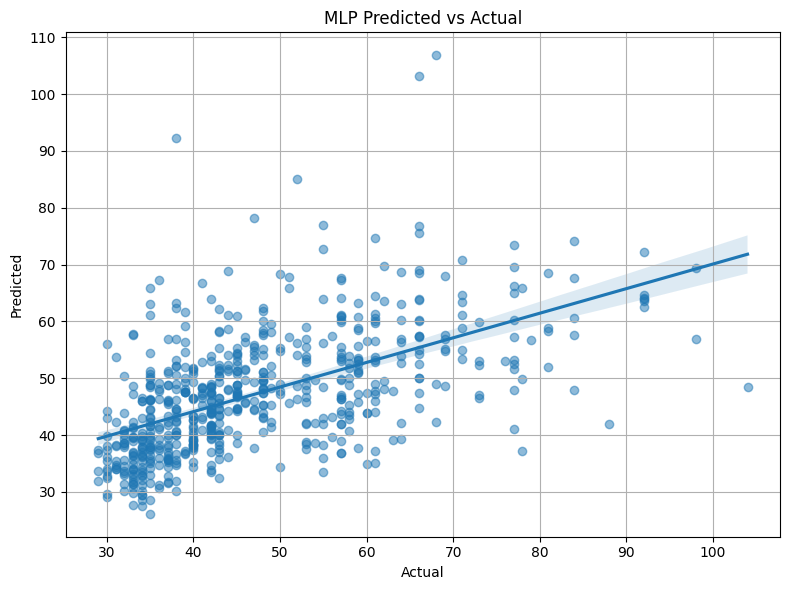

In [169]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

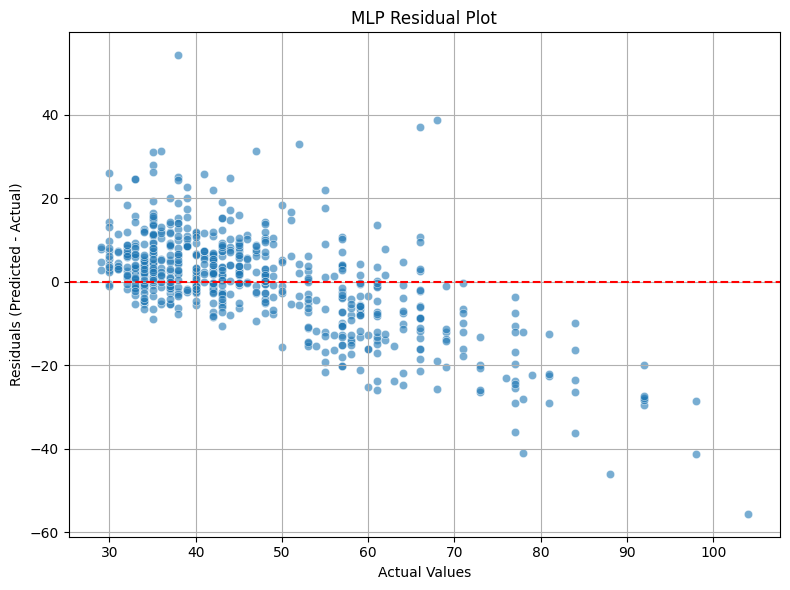

In [170]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only Location

In [171]:
gwas_loc= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,Chr20_52158573,Chr20_52225633,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,0,1,1,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [172]:
gwas_loc_dupe= gwas_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
gwas_loc_dupe.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,Chr20_52158573,Chr20_52225633,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,0,1,1,0,0,0,0,1,0,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1


In [173]:
gwas_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 25130 entries, Chr1_24345 to landrace
dtypes: int64(25130)
memory usage: 486.2+ MB


In [175]:
gwas_y = gwas_data.iloc[:, 25134:]
gwas_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s101,53
s1014,77


In [176]:
X_tensor = torch.tensor(gwas_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [177]:
print(X_tensor.shape)

torch.Size([2536, 25130])


In [178]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [179]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-23 12:06:38,439] A new study created in memory with name: no-name-8a60d53f-c7d5-4f1e-a5c6-e39603dbf3cd
[I 2025-05-23 12:06:39,172] Trial 0 finished with value: 166.94534301757812 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'dropout1': 0.06940350040558746, 'lr': 0.000284167075780073, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 6, 'weight_decay': 0.0013101871373447178}. Best is trial 0 with value: 166.94534301757812.


Early stopping at epoch 12


[I 2025-05-23 12:06:39,724] Trial 1 finished with value: 161.05628967285156 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'dropout1': 0.07791557788181631, 'lr': 0.008079841465102123, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 5, 'weight_decay': 0.00018355377345843617}. Best is trial 1 with value: 161.05628967285156.


Early stopping at epoch 16


[I 2025-05-23 12:06:45,586] Trial 2 finished with value: 156.0525360107422 and parameters: {'hidden_size1': 300, 'hidden_size2': 100, 'dropout1': 0.05491544345151228, 'lr': 0.0018380030077075119, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 12, 'weight_decay': 0.004607924297518587}. Best is trial 2 with value: 156.0525360107422.


...

Early stopping at epoch 20


[I 2025-05-23 12:07:41,592] Trial 48 finished with value: 136.93072509765625 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.023886145424270686, 'lr': 0.0004886698833812833, 'batch_size': 64, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 13, 'weight_decay': 0.005313411914566408}. Best is trial 28 with value: 127.03614044189453.


Early stopping at epoch 22


[I 2025-05-23 12:07:42,382] Trial 49 finished with value: 172.27810668945312 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.018274087221184735, 'lr': 0.00020443407505066114, 'batch_size': 64, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 14, 'weight_decay': 0.006453091997212069}. Best is trial 28 with value: 127.03614044189453.


Early stopping at epoch 15
Best hyperparameters: {'hidden_size1': 100, 'hidden_size2': 25, 'dropout1': 0.03497093744515707, 'lr': 0.0004006845593889792, 'batch_size': 64, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 10, 'weight_decay': 0.008805016912922988}


In [180]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top10_best_model_onlyloc_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 19 for fold 1
Fold 1 validation loss: 125.8654
Training fold 2
Early stopping at epoch 13 for fold 2
Fold 2 validation loss: 127.5660
Training fold 3
Early stopping at epoch 13 for fold 3
Fold 3 validation loss: 127.2700
Training fold 4
Early stopping at epoch 20 for fold 4
Fold 4 validation loss: 152.2955
Training fold 5
Early stopping at epoch 15 for fold 5
Fold 5 validation loss: 141.9950
Training fold 6
Early stopping at epoch 23 for fold 6
Fold 6 validation loss: 159.8105
Training fold 7
Early stopping at epoch 15 for fold 7
Fold 7 validation loss: 157.1719
Training fold 8
Early stopping at epoch 13 for fold 8
Fold 8 validation loss: 140.1153
Training fold 9
Early stopping at epoch 13 for fold 9
Fold 9 validation loss: 131.1611
Training fold 10
Early stopping at epoch 11 for fold 10
Fold 10 validation loss: 158.4824

Average validation loss across all folds: 142.1733
Checkpoint saved as 'gwas_top10_best_model_onlyloc_mlp_bbd.pth'.


In [181]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [182]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [183]:
# Ensure both trainjg and holdout datasets have the same columns
gwas_loc, X_holdout = gwas_loc_dupe.align(X_holdout, join='inner', axis=1)

In [184]:
X_holdout.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,Chr20_52158573,Chr20_52225633,Chr20_52247340,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,0,1,1,1,0,0,0,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,0,1,1,0,0,0,1,0,0,1
s1026,0,0,0,1,0,1,0,1,1,0,...,2,0,0,0,0,0,0,1,0,1
s1030,0,0,0,1,0,1,0,1,1,2,...,0,0,0,0,1,0,0,0,0,1


In [185]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [186]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 199.8915
RMSE: 14.1383
MAE: 10.0084
R2: -0.0390
Holdout_Loss: 199.8915


In [187]:
pickle.dump(best_mlp_model, open("gwas_top10_best_model_onlyloc_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 45 47.499027
1 39 47.15639
2 62 47.0775
3 47 52.575043
4 42 39.70007
5 40 44.28189


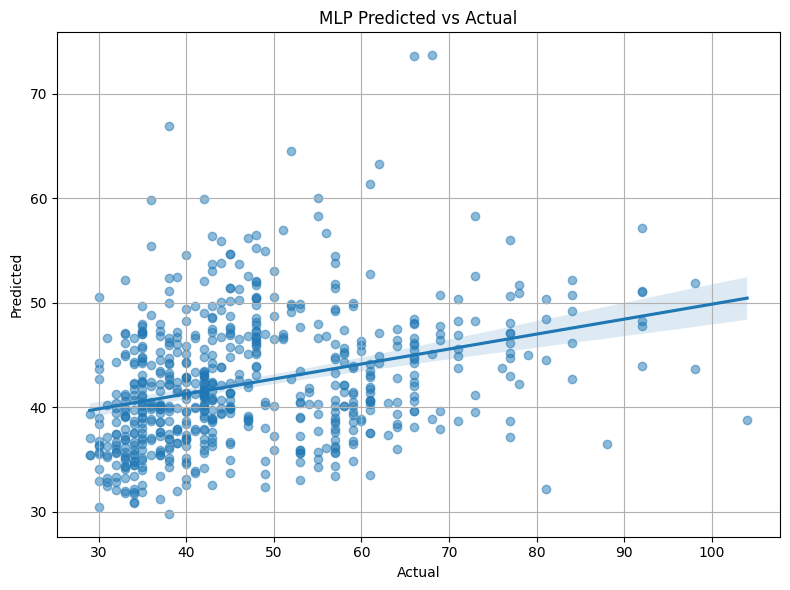

In [188]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

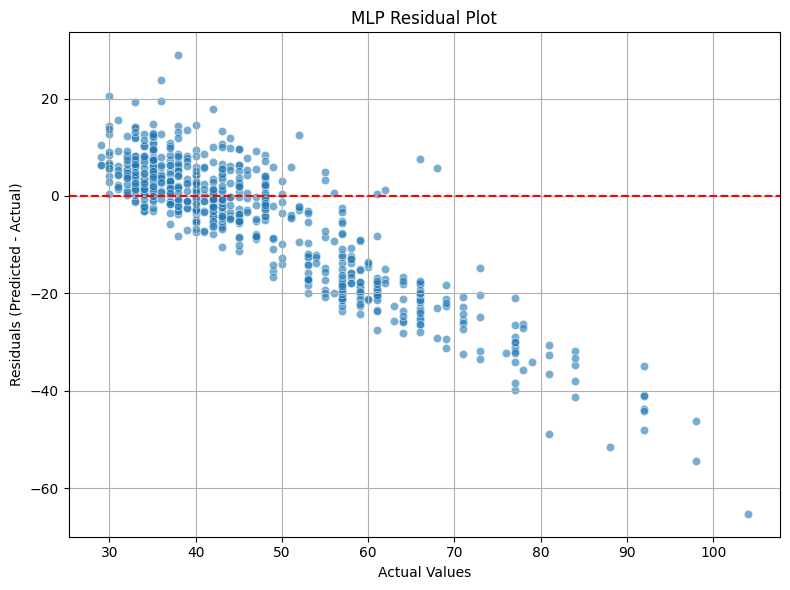

In [189]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [190]:
gwas_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 25135 entries, Chr1_24345 to BBD
dtypes: float64(4), int64(25131)
memory usage: 486.3+ MB


In [191]:
gwas_snps = gwas_data.iloc[:, 0:25123]
gwas_snps.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,Chr20_51891016,Chr20_51891017,Chr20_51977670,Chr20_51998773,Chr20_52020557,Chr20_52102670,Chr20_52108115,Chr20_52158573,Chr20_52225633,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,2,0,0,0,0


In [192]:
gwas_snps_dupe = gwas_data.iloc[:, 0:25123]
gwas_snps_dupe.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,Chr20_51891016,Chr20_51891017,Chr20_51977670,Chr20_51998773,Chr20_52020557,Chr20_52102670,Chr20_52108115,Chr20_52158573,Chr20_52225633,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,1
s100,0,0,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,2,0,0,1
s101,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,2,0,0,0,0


In [193]:
gwas_y = gwas_data.iloc[:, 25134:]
gwas_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s101,53
s1014,77


In [194]:
X_tensor = torch.tensor(gwas_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(gwas_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [195]:
print(X_tensor.shape)

torch.Size([2536, 25123])


In [196]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [197]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-23 12:15:27,432] A new study created in memory with name: no-name-cf7fa02f-edd4-4213-a4e9-f6ea76f9744f
[I 2025-05-23 12:15:28,161] Trial 0 finished with value: 171.8301544189453 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'dropout1': 0.08374433205328932, 'lr': 0.00046492275434360304, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 13, 'weight_decay': 0.00010204542693473963}. Best is trial 0 with value: 171.8301544189453.


Early stopping at epoch 20


[I 2025-05-23 12:15:28,511] Trial 1 finished with value: 142.37742614746094 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.09881353129670006, 'lr': 0.003656003134077934, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 5, 'weight_decay': 0.0005668317435093657}. Best is trial 1 with value: 142.37742614746094.


Early stopping at epoch 6


[I 2025-05-23 12:15:30,339] Trial 2 finished with value: 152.80435180664062 and parameters: {'hidden_size1': 300, 'hidden_size2': 25, 'dropout1': 0.036598168461057894, 'lr': 0.00011016566568491988, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 9, 'weight_decay': 0.0004943486645100107}. Best is trial 1 with value: 142.37742614746094.


...

Early stopping at epoch 10


[I 2025-05-23 12:17:27,970] Trial 47 finished with value: 154.87071228027344 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'dropout1': 0.06864413630869798, 'lr': 0.0007906546588019599, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 14, 'weight_decay': 0.0009783082334431361}. Best is trial 12 with value: 122.83096313476562.


Early stopping at epoch 16


[I 2025-05-23 12:17:34,026] Trial 48 finished with value: 124.33741760253906 and parameters: {'hidden_size1': 200, 'hidden_size2': 50, 'dropout1': 0.07305694433400475, 'lr': 0.0017373324334554344, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 8, 'weight_decay': 0.0004580199835678047}. Best is trial 12 with value: 122.83096313476562.
[I 2025-05-23 12:17:37,242] Trial 49 finished with value: 127.6927261352539 and parameters: {'hidden_size1': 200, 'hidden_size2': 100, 'dropout1': 0.08006154207153718, 'lr': 0.006013054916958763, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 13, 'weight_decay': 0.0001988395612372352}. Best is trial 12 with value: 122.83096313476562.


Early stopping at epoch 37
Best hyperparameters: {'hidden_size1': 300, 'hidden_size2': 100, 'dropout1': 0.07189652461843965, 'lr': 0.003652696343277737, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 15, 'weight_decay': 6.849942893915371e-05}


In [198]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='gwas_top10_best_model_onlysnps_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 25 for fold 1
Fold 1 validation loss: 121.7869
Training fold 2
Early stopping at epoch 21 for fold 2
Fold 2 validation loss: 125.2911
Training fold 3
Early stopping at epoch 26 for fold 3
Fold 3 validation loss: 126.4006
Training fold 4
Early stopping at epoch 26 for fold 4
Fold 4 validation loss: 151.0940
Training fold 5
Early stopping at epoch 27 for fold 5
Fold 5 validation loss: 146.2962
Training fold 6
Early stopping at epoch 28 for fold 6
Fold 6 validation loss: 157.8834
Training fold 7
Early stopping at epoch 27 for fold 7
Fold 7 validation loss: 157.9153
Training fold 8
Early stopping at epoch 24 for fold 8
Fold 8 validation loss: 133.5889
Training fold 9
Early stopping at epoch 29 for fold 9
Fold 9 validation loss: 126.7077
Training fold 10
Early stopping at epoch 29 for fold 10
Fold 10 validation loss: 163.1350

Average validation loss across all folds: 141.0099
Checkpoint saved as 'gwas_top10_best_model_onlysnps_mlp_bbd.pth'.


In [199]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [200]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [201]:
# Ensure both training and holdout datasets have the same columns
gwas_snps_dupe, X_holdout = gwas_snps_dupe.align(X_holdout, join='inner', axis=1)

In [202]:
X_holdout.head()

,Chr1_24345,Chr1_47731,Chr1_121593,Chr1_123323,Chr1_123617,Chr1_124994,Chr1_130043,Chr1_131286,Chr1_131374,Chr1_132094,...,Chr20_51891016,Chr20_51891017,Chr20_51977670,Chr20_51998773,Chr20_52020557,Chr20_52102670,Chr20_52108115,Chr20_52158573,Chr20_52225633,Chr20_52247340
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,2,0,0,0,0
s101,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
s101,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
s1026,0,0,0,1,0,1,0,1,1,0,...,0,0,0,0,1,0,0,2,0,0
s1030,0,0,0,1,0,1,0,1,1,2,...,0,0,0,0,0,0,0,0,0,0


In [203]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [204]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 202.8373
RMSE: 14.2421
MAE: 10.8009
R2: -0.0543
Holdout_Loss: 202.8374


In [206]:
pickle.dump(best_mlp_model, open("gwas_top10_best_model_onlysnps_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 45 51.77518
1 39 51.996788
2 62 51.996788
3 47 61.71454
4 42 42.665604
5 40 44.84113


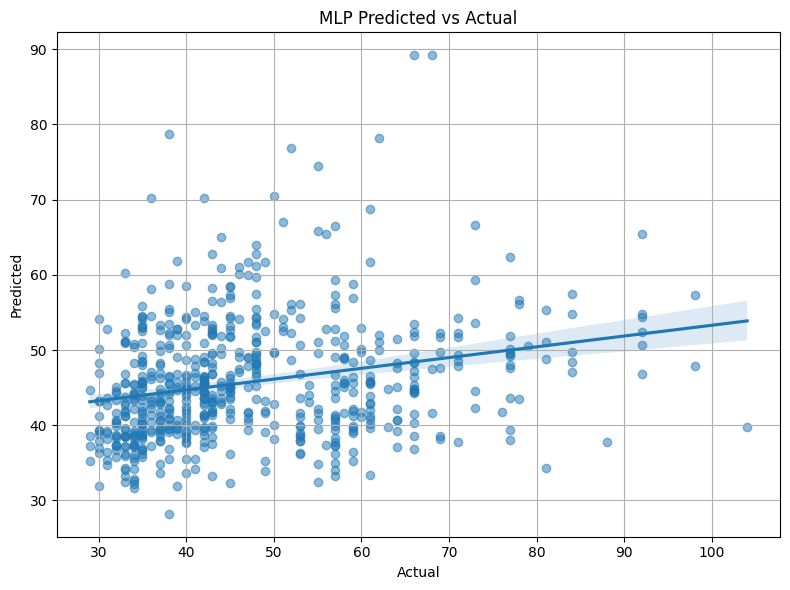

In [208]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

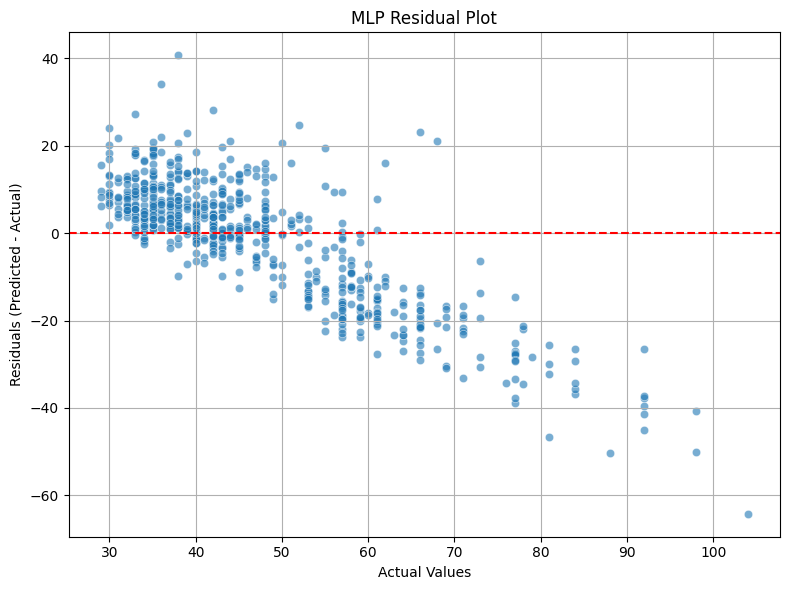

In [209]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

# LASSO regression 

In [102]:
fs_data = pd.read_pickle("pickle_files/fs_bbd_lasso_training_data_new.pkl")

In [103]:
fs_data.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,2,2,0,2,0,2,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,0,0,2,2,0,2,0,2,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,0,0,2,2,0,2,0,2,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014,0,0,0,0,0,2,0,2,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014,0,0,0,0,0,2,0,2,0,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


In [109]:
# Build model with best hyperparameters
def build_model(input_size, params):
    return nn.Sequential(
        nn.Linear(input_size, params['hidden_size1']),
        nn.ReLU(),
        nn.Dropout(params['dropout1']),
        nn.Linear(params['hidden_size1'], params['hidden_size2']),
        nn.ReLU(),
        nn.Linear(params['hidden_size2'], 1)
    )
    return nn.Sequential(*layers)

In [172]:
# 1. Define a training function for Optuna to optimize parameters
def objective(trial):
    # Suggest hyperparameters
    params = {
            #'hidden_size1': trial.suggest_categorical('hidden_size1', [50, 75, 100]),
            #'hidden_size2': trial.suggest_categorical('hidden_size2', [15, 25, 50]),
            #hidden_size3': trial.suggest_categorical('hidden_size3', [25, 50, 75]),
            'hidden_size1': trial.suggest_int('hidden_size1', 32, 96, step=16),
            'hidden_size2': trial.suggest_int('hidden_size2', 16, 48, step=8),
            #'hidden_size3': trial.suggest_int('hidden_size3', 32, 128, step=16),
            'dropout1': trial.suggest_float('dropout1', 0.01, 0.1),
            #'dropout2': trial.suggest_float('dropout2', 0.01, 0.1),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128]),
            'optimizer': trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD']),
            'num_epochs': trial.suggest_categorical('num_epochs', [30, 50, 70]),
            'patience': trial.suggest_int('patience', 5, 15),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
        }
    # Build model
    model = build_model(X_train.shape[1], params).to(device)
    optimizer = getattr(optim, params['optimizer'])(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay']
    )
    loss_function = nn.MSELoss()
    early_stopping = EarlyStopping(patience=params['patience'])

    # Prepare data
    #X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    #y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    #X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    #y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)

    val_losses = []  # <-- Initialize here

    for epoch in range(params['num_epochs']):
        # Training
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = loss_function(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Validation (after each epoch)
        model.eval()
        with torch.no_grad():
            preds = model(X_val).cpu().numpy()
            true = y_val.cpu().numpy()
            val_loss = loss_function(torch.tensor(preds), y_val.cpu())
            val_losses.append(val_loss.item())

        avg_val_loss = np.mean(val_losses[-5:])  # average of last 5 epochs for stability
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    mse = mean_squared_error(true, preds)
    return mse  # Optuna minimizes this

    #HOW TO USE - create study and then optimise

### All features

In [173]:
X_all = fs_data.drop("BBD", axis=1).values
y_all = fs_data["BBD"].values

In [174]:
X_dupe = fs_data.drop("BBD", axis=1)
X_dupe.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,2,2,0,2,0,2,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,0,0,2,2,0,2,0,2,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,0,0,2,2,0,2,0,2,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s1014,0,0,0,0,0,2,0,2,0,0,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1
s1014,0,0,0,0,0,2,0,2,0,0,...,7.78667,73.000,2.60000,0,1,0,0,0,0,1


In [175]:
X_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [176]:
print(X_tensor.shape)

torch.Size([2536, 95])


In [177]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [189]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-23 15:47:04,520] A new study created in memory with name: no-name-365ee08e-88ae-41ae-8bb9-904e2d480524
[I 2025-05-23 15:47:05,421] Trial 0 finished with value: 85.50587463378906 and parameters: {'hidden_size1': 75, 'hidden_size2': 15, 'dropout1': 0.07222505680404706, 'lr': 0.00025278208149927636, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 12, 'weight_decay': 0.0005228279381289365}. Best is trial 0 with value: 85.50587463378906.
[I 2025-05-23 15:47:08,862] Trial 1 finished with value: 66.03182983398438 and parameters: {'hidden_size1': 75, 'hidden_size2': 25, 'dropout1': 0.058412120772733195, 'lr': 0.00017073737857910154, 'batch_size': 64, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 6, 'weight_decay': 0.007976529767527126}. Best is trial 1 with value: 66.03182983398438.
[I 2025-05-23 15:47:13,063] Trial 2 finished with value: 181.56185913085938 and parameters: {'hidden_size1': 100, 'hidden_size2': 25, 'dropout1': 0.06625576137047061, 'lr

Early stopping at epoch 37


[I 2025-05-23 15:47:18,563] Trial 4 finished with value: 1302.17041015625 and parameters: {'hidden_size1': 100, 'hidden_size2': 25, 'dropout1': 0.09295949960379718, 'lr': 0.0003924127055980606, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 13, 'weight_decay': 2.612786322150086e-05}. Best is trial 3 with value: 36.095726013183594.
[I 2025-05-23 15:47:20,935] Trial 5 finished with value: 84.09982299804688 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.025377158568316176, 'lr': 0.008677521439380635, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 9, 'weight_decay': 2.686014017311647e-05}. Best is trial 3 with value: 36.095726013183594.
[I 2025-05-23 15:47:25,345] Trial 6 finished with value: 62.57379150390625 and parameters: {'hidden_size1': 50, 'hidden_size2': 50, 'dropout1': 0.09263699697996805, 'lr': 0.0005016742819179553, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 7, 'weight_decay': 0.0075132

Early stopping at epoch 47


[I 2025-05-23 15:47:30,036] Trial 7 finished with value: 37.460330963134766 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.03803465832789052, 'lr': 0.0003328618262475451, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 10, 'weight_decay': 1.573254198842004e-05}. Best is trial 3 with value: 36.095726013183594.
[I 2025-05-23 15:47:30,979] Trial 8 finished with value: 69.2492904663086 and parameters: {'hidden_size1': 100, 'hidden_size2': 25, 'dropout1': 0.03445313932615239, 'lr': 0.00040052580711166504, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 5, 'weight_decay': 0.0001098270951984302}. Best is trial 3 with value: 36.095726013183594.
[I 2025-05-23 15:47:33,514] Trial 9 finished with value: 194.60438537597656 and parameters: {'hidden_size1': 50, 'hidden_size2': 25, 'dropout1': 0.014910242624770158, 'lr': 0.0007091062685556234, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 15, 'weight_decay': 0.0

...

Early stopping at epoch 39


[I 2025-05-23 15:49:19,277] Trial 45 finished with value: 47.2752571105957 and parameters: {'hidden_size1': 100, 'hidden_size2': 25, 'dropout1': 0.059011712766959205, 'lr': 0.00023759824479143216, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 8, 'weight_decay': 0.0005487409233880257}. Best is trial 26 with value: 34.245201110839844.
[I 2025-05-23 15:49:22,107] Trial 46 finished with value: 40.97044372558594 and parameters: {'hidden_size1': 50, 'hidden_size2': 15, 'dropout1': 0.03182259045578966, 'lr': 0.0020191106148779924, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 11, 'weight_decay': 0.00011438858250925775}. Best is trial 26 with value: 34.245201110839844.
[I 2025-05-23 15:49:23,812] Trial 47 finished with value: 36.82759475708008 and parameters: {'hidden_size1': 75, 'hidden_size2': 50, 'dropout1': 0.011289729457427046, 'lr': 0.005716484816434937, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 8, 'weight_decay': 6

Early stopping at epoch 18


[I 2025-05-23 15:49:27,129] Trial 48 finished with value: 96.89310455322266 and parameters: {'hidden_size1': 50, 'hidden_size2': 15, 'dropout1': 0.05202732519625053, 'lr': 0.002574435916346107, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 12, 'weight_decay': 0.0001752247637413245}. Best is trial 26 with value: 34.245201110839844.
[I 2025-05-23 15:49:28,927] Trial 49 finished with value: 43.40612030029297 and parameters: {'hidden_size1': 75, 'hidden_size2': 15, 'dropout1': 0.046398774076984436, 'lr': 0.003951351420205216, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 5, 'weight_decay': 0.0003237579011864158}. Best is trial 26 with value: 34.245201110839844.


Early stopping at epoch 19
Best hyperparameters: {'hidden_size1': 50, 'hidden_size2': 15, 'dropout1': 0.019253345640520038, 'lr': 0.0011747734778447246, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 6, 'weight_decay': 0.00040757852901879987}


In [190]:
#Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='lasso_allfeats_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 48 for fold 1
Fold 1 validation loss: 34.6316
Training fold 2
Early stopping at epoch 46 for fold 2
Fold 2 validation loss: 37.1482
Training fold 3
Fold 3 validation loss: 41.3307
Training fold 4
Fold 4 validation loss: 52.1216
Training fold 5
Early stopping at epoch 30 for fold 5
Fold 5 validation loss: 41.6108
Training fold 6
Early stopping at epoch 44 for fold 6
Fold 6 validation loss: 43.6951
Training fold 7
Fold 7 validation loss: 59.8358
Training fold 8
Early stopping at epoch 32 for fold 8
Fold 8 validation loss: 34.1420
Training fold 9
Early stopping at epoch 40 for fold 9
Fold 9 validation loss: 44.3111
Training fold 10
Early stopping at epoch 35 for fold 10
Fold 10 validation loss: 52.7732

Average validation loss across all folds: 44.1600
Checkpoint saved as 'lasso_allfeats_mlp_bbd.pth'.


In [180]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [181]:
holdout_data = holdout_data.set_index('Line')

In [182]:
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [183]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [184]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [185]:
X_dupe, X_holdout = X_dupe.align(X_holdout, join='inner', axis=1)

In [186]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Data columns (total 95 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Chr1_57654800      634 non-null    int64  
 1   Chr2_5531677       634 non-null    int64  
 2   Chr2_12189925      634 non-null    int64  
 3   Chr3_3015546       634 non-null    int64  
 4   Chr3_3928140       634 non-null    int64  
 5   Chr3_40005206      634 non-null    int64  
 6   Chr3_40290724      634 non-null    int64  
 7   Chr3_40656738      634 non-null    int64  
 8   Chr4_4857888       634 non-null    int64  
 9   Chr4_4919916       634 non-null    int64  
 10  Chr5_38319375      634 non-null    int64  
 11  Chr5_42876267      634 non-null    int64  
 12  Chr5_43891249      634 non-null    int64  
 13  Chr6_6382229       634 non-null    int64  
 14  Chr6_17486087      634 non-null    int64  
 15  Chr7_1665194       634 non-null    int64  
 16  Chr7_7688773       634 non-

In [187]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [191]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 55.2329
RMSE: 7.4319
MAE: 5.1715
R2: 0.7129
Holdout_Loss: 55.2329


In [122]:
pickle.dump(best_mlp_model, open("lasso_allfeats_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 45 43.267906
1 39 50.835896
2 62 76.26699
3 47 59.555416
4 42 38.762722
5 40 40.374474


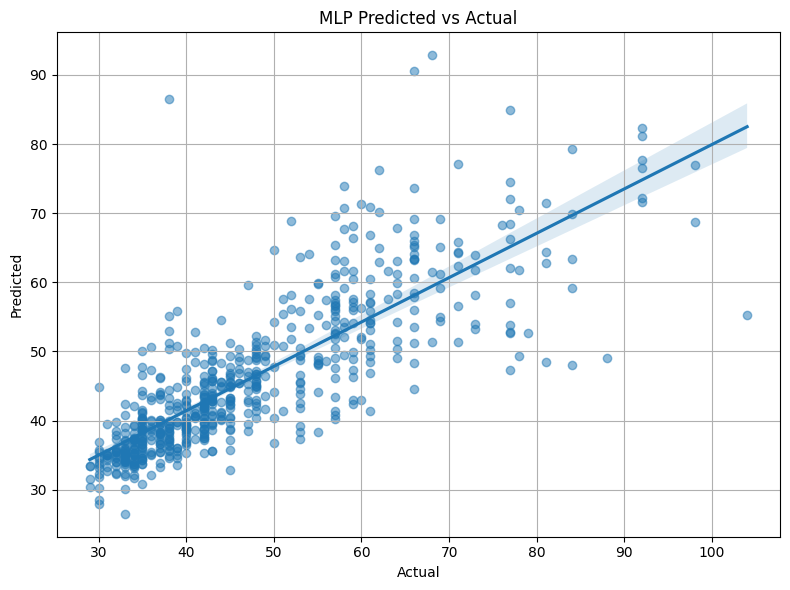

In [203]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

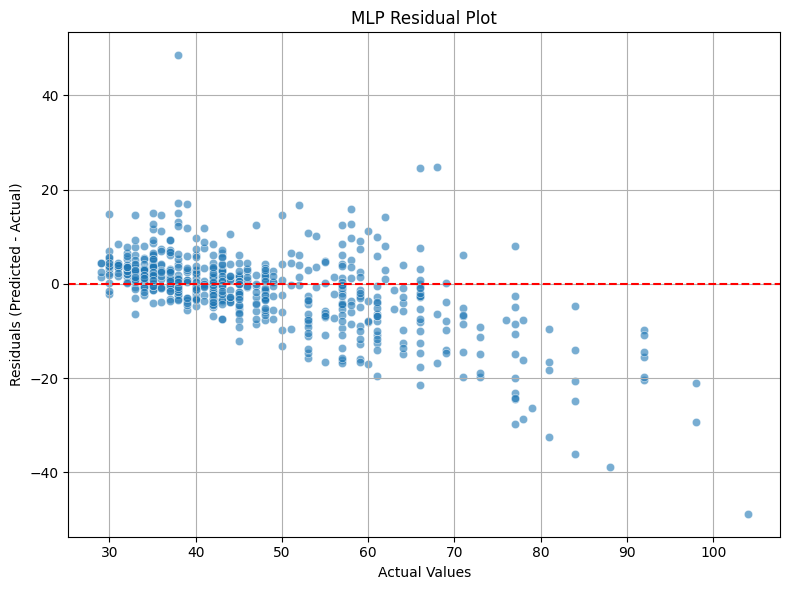

In [204]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [123]:
snps_loc= fs_data.drop(['BBD', 'LL', 'LW', 'PLH', 'VBN'], axis=1)
snps_loc.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,Chr20_16221209,Chr20_40195415,Chr20_42765511,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,2,2,0,2,0,2,...,2,0,0,1,0,0,0,0,0,1
s100,0,0,0,0,2,2,0,2,0,2,...,2,0,0,0,1,0,0,0,0,1
s100,0,0,0,0,2,2,0,2,0,2,...,2,0,0,0,0,1,0,0,0,1
s1014,0,0,0,0,0,2,0,2,0,0,...,0,0,0,1,0,0,0,0,0,1
s1014,0,0,0,0,0,2,0,2,0,0,...,0,0,0,0,1,0,0,0,0,1


In [124]:
snps_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Data columns (total 91 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Chr1_57654800      2536 non-null   int64
 1   Chr2_5531677       2536 non-null   int64
 2   Chr2_12189925      2536 non-null   int64
 3   Chr3_3015546       2536 non-null   int64
 4   Chr3_3928140       2536 non-null   int64
 5   Chr3_40005206      2536 non-null   int64
 6   Chr3_40290724      2536 non-null   int64
 7   Chr3_40656738      2536 non-null   int64
 8   Chr4_4857888       2536 non-null   int64
 9   Chr4_4919916       2536 non-null   int64
 10  Chr5_38319375      2536 non-null   int64
 11  Chr5_42876267      2536 non-null   int64
 12  Chr5_43891249      2536 non-null   int64
 13  Chr6_6382229       2536 non-null   int64
 14  Chr6_17486087      2536 non-null   int64
 15  Chr7_1665194       2536 non-null   int64
 16  Chr7_7688773       2536 non-null   int64
 17  Chr7_9531953     

In [125]:
snps_loc_dupe= fs_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
snps_loc_dupe.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,Chr20_16221209,Chr20_40195415,Chr20_42765511,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,2,2,0,2,0,2,...,2,0,0,1,0,0,0,0,0,1
s100,0,0,0,0,2,2,0,2,0,2,...,2,0,0,0,1,0,0,0,0,1
s100,0,0,0,0,2,2,0,2,0,2,...,2,0,0,0,0,1,0,0,0,1
s1014,0,0,0,0,0,2,0,2,0,0,...,0,0,0,1,0,0,0,0,0,1
s1014,0,0,0,0,0,2,0,2,0,0,...,0,0,0,0,1,0,0,0,0,1


In [126]:
y_all = fs_data["BBD"].values

In [127]:
X_tensor = torch.tensor(snps_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [128]:
print(X_tensor.shape)

torch.Size([2536, 91])


In [129]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [130]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-23 15:22:11,716] A new study created in memory with name: no-name-5092b8f1-5983-4b52-bda3-4a3b4cc051d1
[I 2025-05-23 15:22:15,562] Trial 0 finished with value: 38.90675354003906 and parameters: {'hidden_size1': 96, 'hidden_size2': 32, 'dropout1': 0.08372214840785243, 'lr': 0.0017901796970034131, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 9, 'weight_decay': 0.00015330945591072784}. Best is trial 0 with value: 38.90675354003906.


Early stopping at epoch 42


[I 2025-05-23 15:22:16,501] Trial 1 finished with value: 94.12027740478516 and parameters: {'hidden_size1': 80, 'hidden_size2': 24, 'dropout1': 0.017658356489446723, 'lr': 0.00034783853206422785, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 5, 'weight_decay': 0.004569694589445766}. Best is trial 0 with value: 38.90675354003906.
[I 2025-05-23 15:22:17,857] Trial 2 finished with value: 42.671730041503906 and parameters: {'hidden_size1': 32, 'hidden_size2': 24, 'dropout1': 0.02419083747328455, 'lr': 0.003718023161747816, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 6, 'weight_decay': 0.0007917955378421361}. Best is trial 0 with value: 38.90675354003906.


Early stopping at epoch 41


[I 2025-05-23 15:22:20,299] Trial 3 finished with value: 2077.376953125 and parameters: {'hidden_size1': 64, 'hidden_size2': 40, 'dropout1': 0.027896618721932248, 'lr': 0.0002961238775017841, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 12, 'weight_decay': 9.57931131358385e-05}. Best is trial 0 with value: 38.90675354003906.
[I 2025-05-23 15:22:22,811] Trial 4 finished with value: 1579.617919921875 and parameters: {'hidden_size1': 96, 'hidden_size2': 16, 'dropout1': 0.04933449701922895, 'lr': 0.000513624032053692, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 12, 'weight_decay': 0.0028017658558878453}. Best is trial 0 with value: 38.90675354003906.
[I 2025-05-23 15:22:23,704] Trial 5 finished with value: 56.72459411621094 and parameters: {'hidden_size1': 80, 'hidden_size2': 40, 'dropout1': 0.045233484428710904, 'lr': 0.004557957370850081, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 5, 'weight_decay': 5.8339702837

...

Early stopping at epoch 48


[I 2025-05-23 15:24:29,085] Trial 46 finished with value: 158.79100036621094 and parameters: {'hidden_size1': 64, 'hidden_size2': 32, 'dropout1': 0.03635986435019439, 'lr': 0.0010364364483012127, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 11, 'weight_decay': 2.7308608264410628e-05}. Best is trial 43 with value: 32.6317024230957.
[I 2025-05-23 15:24:32,755] Trial 47 finished with value: 37.836952209472656 and parameters: {'hidden_size1': 80, 'hidden_size2': 32, 'dropout1': 0.060169723275631706, 'lr': 0.0006849675710263414, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 10, 'weight_decay': 4.440742259872483e-05}. Best is trial 43 with value: 32.6317024230957.
[I 2025-05-23 15:24:36,512] Trial 48 finished with value: 40.8944206237793 and parameters: {'hidden_size1': 80, 'hidden_size2': 32, 'dropout1': 0.04761627382304641, 'lr': 0.0025952242063211326, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 12, 'weight_decay': 0.00

Early stopping at epoch 40


[I 2025-05-23 15:24:39,136] Trial 49 finished with value: 37.874603271484375 and parameters: {'hidden_size1': 64, 'hidden_size2': 32, 'dropout1': 0.0577150445338829, 'lr': 0.0016916400585884393, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 9, 'weight_decay': 1.602733611191441e-05}. Best is trial 43 with value: 32.6317024230957.


Early stopping at epoch 50
Best hyperparameters: {'hidden_size1': 64, 'hidden_size2': 32, 'dropout1': 0.05872958519959074, 'lr': 0.0011089492799702236, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 10, 'weight_decay': 3.192421733331128e-05}


In [132]:
best_params = study.best_params

In [133]:
#def cross_validate(X, y, best_params, n_splits, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='lasso_onlyloc_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 43 for fold 1
Fold 1 validation loss: 34.2638
Training fold 2
Early stopping at epoch 54 for fold 2
Fold 2 validation loss: 37.8410
Training fold 3
Fold 3 validation loss: 40.5832
Training fold 4
Early stopping at epoch 61 for fold 4
Fold 4 validation loss: 58.0287
Training fold 5
Early stopping at epoch 53 for fold 5
Fold 5 validation loss: 38.6821
Training fold 6
Early stopping at epoch 39 for fold 6
Fold 6 validation loss: 42.9745
Training fold 7
Early stopping at epoch 61 for fold 7
Fold 7 validation loss: 56.4954
Training fold 8
Early stopping at epoch 50 for fold 8
Fold 8 validation loss: 36.4531
Training fold 9
Early stopping at epoch 53 for fold 9
Fold 9 validation loss: 40.7069
Training fold 10
Early stopping at epoch 46 for fold 10
Fold 10 validation loss: 51.5727

Average validation loss across all folds: 43.7601
Checkpoint saved as 'lasso_onlyloc_mlp_bbd.pth'.


In [134]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [135]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [136]:
# Ensure both trainjg and holdout datasets have the same columns
snps_loc_dupe, X_holdout = snps_loc_dupe.align(X_holdout, join='inner', axis=1)

In [137]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Data columns (total 91 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Chr1_57654800      634 non-null    int64
 1   Chr2_5531677       634 non-null    int64
 2   Chr2_12189925      634 non-null    int64
 3   Chr3_3015546       634 non-null    int64
 4   Chr3_3928140       634 non-null    int64
 5   Chr3_40005206      634 non-null    int64
 6   Chr3_40290724      634 non-null    int64
 7   Chr3_40656738      634 non-null    int64
 8   Chr4_4857888       634 non-null    int64
 9   Chr4_4919916       634 non-null    int64
 10  Chr5_38319375      634 non-null    int64
 11  Chr5_42876267      634 non-null    int64
 12  Chr5_43891249      634 non-null    int64
 13  Chr6_6382229       634 non-null    int64
 14  Chr6_17486087      634 non-null    int64
 15  Chr7_1665194       634 non-null    int64
 16  Chr7_7688773       634 non-null    int64
 17  Chr7_9531953     

In [138]:
X_holdout.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,Chr20_16221209,Chr20_40195415,Chr20_42765511,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,2,0,2,0,0,...,0,0,0,0,0,1,0,0,0,1
s101,2,0,0,2,0,2,0,0,0,2,...,2,0,0,1,0,0,0,0,0,1
s101,2,0,0,2,0,2,0,0,0,2,...,2,0,0,0,0,0,1,0,0,1
s1026,0,0,0,0,0,2,0,2,0,2,...,0,2,0,0,0,0,0,1,0,1
s1030,0,0,0,0,2,0,0,0,0,2,...,1,0,2,0,1,0,0,0,0,1


In [139]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [140]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 57.6322
RMSE: 7.5916
MAE: 5.2821
R2: 0.7004
Holdout_Loss: 57.6322


In [141]:
pickle.dump(best_mlp_model, open("lasso_onlyloc_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 45 42.381416
1 39 57.92036
2 62 79.19153
3 47 57.092083
4 42 42.17102
5 40 40.7606


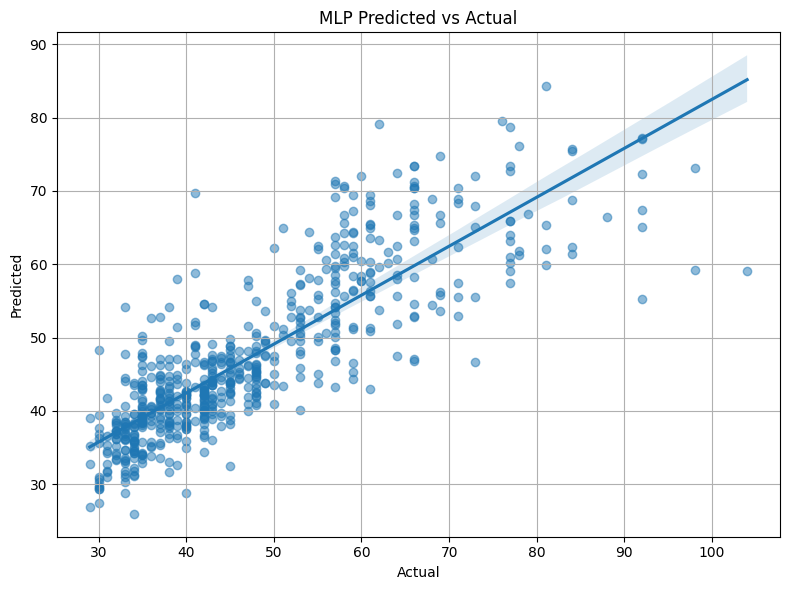

In [142]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

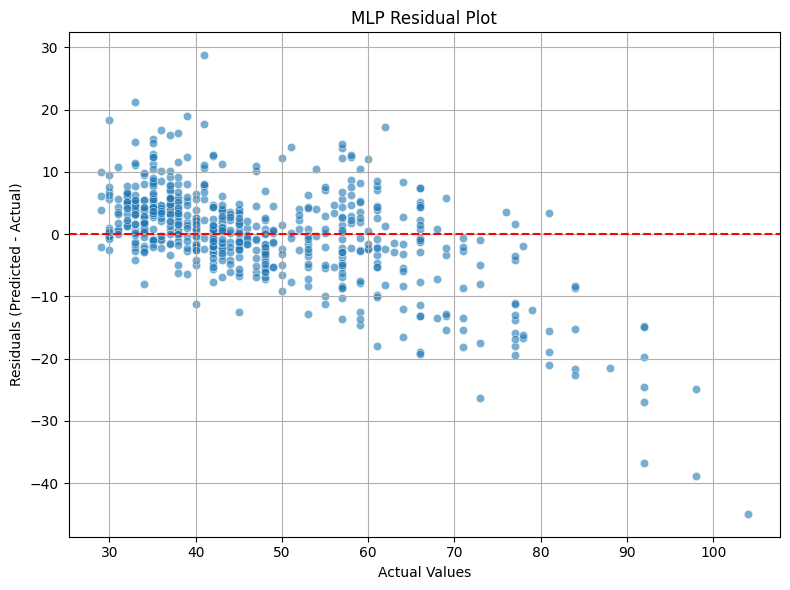

In [143]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [144]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Data columns (total 96 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Chr1_57654800      2536 non-null   int64  
 1   Chr2_5531677       2536 non-null   int64  
 2   Chr2_12189925      2536 non-null   int64  
 3   Chr3_3015546       2536 non-null   int64  
 4   Chr3_3928140       2536 non-null   int64  
 5   Chr3_40005206      2536 non-null   int64  
 6   Chr3_40290724      2536 non-null   int64  
 7   Chr3_40656738      2536 non-null   int64  
 8   Chr4_4857888       2536 non-null   int64  
 9   Chr4_4919916       2536 non-null   int64  
 10  Chr5_38319375      2536 non-null   int64  
 11  Chr5_42876267      2536 non-null   int64  
 12  Chr5_43891249      2536 non-null   int64  
 13  Chr6_6382229       2536 non-null   int64  
 14  Chr6_17486087      2536 non-null   int64  
 15  Chr7_1665194       2536 non-null   int64  
 16  Chr7_7688773       2536 non

In [154]:
only_snps = fs_data.iloc[:, 0:84]
only_snps.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,Chr19_43397236,Chr19_44387341,Chr19_48648920,Chr19_48662429,Chr19_50186921,Chr19_51600918,Chr20_2145196,Chr20_16221209,Chr20_40195415,Chr20_42765511
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s100,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s100,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s1014,0,0,0,0,0,2,0,2,0,0,...,2,0,0,0,0,2,2,0,0,0
s1014,0,0,0,0,0,2,0,2,0,0,...,2,0,0,0,0,2,2,0,0,0


In [155]:
only_snps_dupe = fs_data.iloc[:, 0:84]
only_snps.head()

,Chr1_57654800,Chr2_5531677,Chr2_12189925,Chr3_3015546,Chr3_3928140,Chr3_40005206,Chr3_40290724,Chr3_40656738,Chr4_4857888,Chr4_4919916,...,Chr19_43397236,Chr19_44387341,Chr19_48648920,Chr19_48662429,Chr19_50186921,Chr19_51600918,Chr20_2145196,Chr20_16221209,Chr20_40195415,Chr20_42765511
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s100,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s100,0,0,0,0,2,2,0,2,0,2,...,0,2,0,0,2,2,2,2,0,0
s1014,0,0,0,0,0,2,0,2,0,0,...,2,0,0,0,0,2,2,0,0,0
s1014,0,0,0,0,0,2,0,2,0,0,...,2,0,0,0,0,2,2,0,0,0


In [156]:
y_all = fs_data["BBD"]
y_all.head()

Line
s100     61
s100     37
s100     43
s1014    77
s1014    42
Name: BBD, dtype: int64

In [157]:
# Convert to tensor and move to GPU if available
X_tensor = torch.tensor(only_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [158]:
print(X_tensor.shape)

torch.Size([2536, 84])


In [159]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [160]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-23 15:29:56,424] A new study created in memory with name: no-name-f573515d-ea68-4e65-9f1f-2eeb08fbf1d9
[I 2025-05-23 15:29:57,206] Trial 0 finished with value: 158.87184143066406 and parameters: {'hidden_size1': 96, 'hidden_size2': 48, 'dropout1': 0.04835312391872454, 'lr': 0.0034762267840980515, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 12, 'weight_decay': 0.004627871767627272}. Best is trial 0 with value: 158.87184143066406.


Early stopping at epoch 26


[I 2025-05-23 15:29:58,623] Trial 1 finished with value: 1741.90576171875 and parameters: {'hidden_size1': 32, 'hidden_size2': 16, 'dropout1': 0.012998740218678438, 'lr': 0.0011381978483384978, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 13, 'weight_decay': 0.001278766582100292}. Best is trial 0 with value: 158.87184143066406.
[I 2025-05-23 15:29:58,982] Trial 2 finished with value: 152.77139282226562 and parameters: {'hidden_size1': 32, 'hidden_size2': 40, 'dropout1': 0.03497108919893819, 'lr': 0.0025102115434681325, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 5, 'weight_decay': 1.546751935497903e-05}. Best is trial 2 with value: 152.77139282226562.


Early stopping at epoch 12


[I 2025-05-23 15:29:59,846] Trial 3 finished with value: 2184.659912109375 and parameters: {'hidden_size1': 64, 'hidden_size2': 24, 'dropout1': 0.03447511333454872, 'lr': 0.00036131050371541936, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 6, 'weight_decay': 5.535124363934223e-05}. Best is trial 2 with value: 152.77139282226562.
[I 2025-05-23 15:30:01,103] Trial 4 finished with value: 144.0200958251953 and parameters: {'hidden_size1': 64, 'hidden_size2': 40, 'dropout1': 0.04228112393295121, 'lr': 0.00033045664960174785, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 70, 'patience': 12, 'weight_decay': 0.008885455205254703}. Best is trial 4 with value: 144.0200958251953.


...

Early stopping at epoch 31


[I 2025-05-23 15:31:32,334] Trial 47 finished with value: 141.95396423339844 and parameters: {'hidden_size1': 96, 'hidden_size2': 24, 'dropout1': 0.06374349318300063, 'lr': 0.0004429055420676737, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 10, 'weight_decay': 4.039028263081331e-05}. Best is trial 14 with value: 140.10816955566406.
[I 2025-05-23 15:31:34,603] Trial 48 finished with value: 143.1004180908203 and parameters: {'hidden_size1': 96, 'hidden_size2': 16, 'dropout1': 0.04912822727596151, 'lr': 0.0004028661756693851, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 10, 'weight_decay': 2.253623703347354e-05}. Best is trial 14 with value: 140.10816955566406.


Early stopping at epoch 24


[I 2025-05-23 15:31:37,341] Trial 49 finished with value: 143.7280731201172 and parameters: {'hidden_size1': 96, 'hidden_size2': 24, 'dropout1': 0.0634890395449117, 'lr': 0.0003093420695172363, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 11, 'weight_decay': 3.6864514300853815e-05}. Best is trial 14 with value: 140.10816955566406.


Early stopping at epoch 29
Best hyperparameters: {'hidden_size1': 48, 'hidden_size2': 32, 'dropout1': 0.0570814389467624, 'lr': 0.000709387765951567, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 10, 'weight_decay': 0.00075801655909586}


In [161]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, best_params, n_splits, checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='lasso_onlysnps_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 21 for fold 1
Fold 1 validation loss: 140.9913
Training fold 2
Fold 2 validation loss: 142.5387
Training fold 3
Early stopping at epoch 20 for fold 3
Fold 3 validation loss: 137.7717
Training fold 4
Early stopping at epoch 38 for fold 4
Fold 4 validation loss: 179.0319
Training fold 5
Early stopping at epoch 34 for fold 5
Fold 5 validation loss: 135.1970
Training fold 6
Early stopping at epoch 29 for fold 6
Fold 6 validation loss: 137.9603
Training fold 7
Early stopping at epoch 31 for fold 7
Fold 7 validation loss: 172.9676
Training fold 8
Early stopping at epoch 15 for fold 8
Fold 8 validation loss: 142.7847
Training fold 9
Early stopping at epoch 20 for fold 9
Fold 9 validation loss: 134.8435
Training fold 10
Early stopping at epoch 47 for fold 10
Fold 10 validation loss: 170.3626

Average validation loss across all folds: 149.4449
Checkpoint saved as 'lasso_onlysnps_mlp_bbd.pth'.


In [162]:
best_mlp_model

Sequential(
  (0): Linear(in_features=84, out_features=48, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.0570814389467624, inplace=False)
  (3): Linear(in_features=48, out_features=32, bias=True)
  (4): ReLU()
  (5): Linear(in_features=32, out_features=1, bias=True)
)

In [163]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [164]:
holdout_data = holdout_data.set_index('Line')

In [165]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [166]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [167]:
# Ensure both trainjg and holdout datasets have the same columns
only_snps_dupe, X_holdout = only_snps_dupe.align(X_holdout, join='inner', axis=1)

In [168]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Data columns (total 84 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Chr1_57654800   634 non-null    int64
 1   Chr2_5531677    634 non-null    int64
 2   Chr2_12189925   634 non-null    int64
 3   Chr3_3015546    634 non-null    int64
 4   Chr3_3928140    634 non-null    int64
 5   Chr3_40005206   634 non-null    int64
 6   Chr3_40290724   634 non-null    int64
 7   Chr3_40656738   634 non-null    int64
 8   Chr4_4857888    634 non-null    int64
 9   Chr4_4919916    634 non-null    int64
 10  Chr5_38319375   634 non-null    int64
 11  Chr5_42876267   634 non-null    int64
 12  Chr5_43891249   634 non-null    int64
 13  Chr6_6382229    634 non-null    int64
 14  Chr6_17486087   634 non-null    int64
 15  Chr7_1665194    634 non-null    int64
 16  Chr7_7688773    634 non-null    int64
 17  Chr7_9531953    634 non-null    int64
 18  Chr7_39820318   634 non-null   

In [169]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [170]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 191.0112
RMSE: 13.8207
MAE: 10.3729
R2: 0.0072
Holdout_Loss: 191.0113


In [171]:
pickle.dump(best_mlp_model, open("lasso_onlysnps_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

# ElasticNet

In [7]:
# Build model with best hyperparameters
def build_model(input_size, params):
    return nn.Sequential(
        nn.Linear(input_size, params['hidden_size1']),
        nn.ReLU(),
        nn.Dropout(params['dropout1']),
        nn.Linear(params['hidden_size1'], params['hidden_size2']),
        nn.ReLU(),
        nn.Linear(params['hidden_size2'], 1)
    )
    return nn.Sequential(*layers)

In [81]:
# 1. Define a training function for Optuna to optimize parameters
def objective(trial):
    # Suggest hyperparameters
    params = {
            'hidden_size1': trial.suggest_categorical('hidden_size1', [75, 100, 125]),
            'hidden_size2': trial.suggest_categorical('hidden_size2', [15, 25, 50]),
            #'hidden_size3': trial.suggest_categorical('hidden_size3', [25, 50, 75]),
            #'hidden_size1': trial.suggest_int('hidden_size1', 64, 256, step=32),
            #'hidden_size2': trial.suggest_int('hidden_size2', 32, 128, step=16),
            #'hidden_size3': trial.suggest_int('hidden_size3', 32, 128, step=16),
            'dropout1': trial.suggest_float('dropout1', 0.01, 0.1),
            #'dropout2': trial.suggest_float('dropout2', 0.01, 0.1),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128]),
            'optimizer': trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD']),
            'num_epochs': trial.suggest_categorical('num_epochs', [30, 50, 70]),
            'patience': trial.suggest_int('patience', 5, 15),
            'weight_decay': trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
        }
    # Build model
    model = build_model(X_train.shape[1], params).to(device)
    optimizer = getattr(optim, params['optimizer'])(
        model.parameters(),
        lr=params['lr'],
        weight_decay=params['weight_decay']
    )
    loss_function = nn.MSELoss()
    early_stopping = EarlyStopping(patience=params['patience'])

    # Prepare data
    #X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
    #y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1).to(device)
    #X_val_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    #y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1).to(device)

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)

    val_losses = []  # <-- Initialize here

    for epoch in range(params['num_epochs']):
        # Training
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = loss_function(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Validation (after each epoch)
        model.eval()
        with torch.no_grad():
            preds = model(X_val).cpu().numpy()
            true = y_val.cpu().numpy()
            val_loss = loss_function(torch.tensor(preds), y_val.cpu())
            val_losses.append(val_loss.item())

        avg_val_loss = np.mean(val_losses[-5:])  # average of last 5 epochs for stability
        early_stopping(avg_val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    mse = mean_squared_error(true, preds)
    return mse  # Optuna minimizes this

    #HOW TO USE - create study and then optimise

In [82]:
fs_data = pd.read_pickle("pickle_files/fs_bbd_enet_training_data.pkl")

In [83]:
fs_data.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,0,2,2,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,1,0,2,2,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,1,0,2,2,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014,2,2,0,0,2,0,2,0,2,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014,2,2,0,0,2,0,2,0,2,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


### All covariates

In [84]:
X_all = fs_data.drop("BBD", axis=1).values
y_all = fs_data["BBD"].values

In [85]:
X_dupe = fs_data.drop("BBD", axis=1)
X_dupe.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,0,2,2,0,0,0,0,0,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,1,0,2,2,0,0,0,0,0,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,1,0,2,2,0,0,0,0,0,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s1014,2,2,0,0,2,0,2,0,2,0,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1
s1014,2,2,0,0,2,0,2,0,2,0,...,7.78667,73.000,2.60000,0,1,0,0,0,0,1


In [86]:
X_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [87]:
print(X_tensor.shape)

torch.Size([2536, 206])


In [88]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [89]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-23 14:15:11,983] A new study created in memory with name: no-name-38c6b99b-617a-444e-a39a-495952ec8c36
[I 2025-05-23 14:15:16,665] Trial 0 finished with value: 50.51845169067383 and parameters: {'hidden_size1': 75, 'hidden_size2': 25, 'dropout1': 0.03749052997580377, 'lr': 0.000179545945271341, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 5, 'weight_decay': 2.0639862146396592e-05}. Best is trial 0 with value: 50.51845169067383.
[I 2025-05-23 14:15:17,560] Trial 1 finished with value: 87.46952056884766 and parameters: {'hidden_size1': 125, 'hidden_size2': 50, 'dropout1': 0.05496370618370115, 'lr': 0.00326334431777705, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 50, 'patience': 14, 'weight_decay': 0.0030790463464674634}. Best is trial 0 with value: 50.51845169067383.


Early stopping at epoch 30


[I 2025-05-23 14:15:20,072] Trial 2 finished with value: 173.1979522705078 and parameters: {'hidden_size1': 100, 'hidden_size2': 25, 'dropout1': 0.06831024812062073, 'lr': 0.0011622529602624907, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 30, 'patience': 11, 'weight_decay': 0.0013068806886567862}. Best is trial 0 with value: 50.51845169067383.
[I 2025-05-23 14:15:22,042] Trial 3 finished with value: 78.83442687988281 and parameters: {'hidden_size1': 125, 'hidden_size2': 50, 'dropout1': 0.06475536843711406, 'lr': 0.0010354851810458426, 'batch_size': 64, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 14, 'weight_decay': 0.00771088703639064}. Best is trial 0 with value: 50.51845169067383.


Early stopping at epoch 40


[I 2025-05-23 14:15:26,800] Trial 4 finished with value: 75.22694396972656 and parameters: {'hidden_size1': 75, 'hidden_size2': 50, 'dropout1': 0.025499769805511767, 'lr': 0.006323807009474165, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 6, 'weight_decay': 0.00026881987501664893}. Best is trial 0 with value: 50.51845169067383.


...

Early stopping at epoch 19


[I 2025-05-23 14:17:09,434] Trial 40 finished with value: 43.60454559326172 and parameters: {'hidden_size1': 75, 'hidden_size2': 50, 'dropout1': 0.06392896261276661, 'lr': 0.009671552995382766, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 14, 'weight_decay': 9.484772317802625e-05}. Best is trial 27 with value: 31.41449546813965.


Early stopping at epoch 39


[I 2025-05-23 14:17:12,051] Trial 41 finished with value: 34.2978515625 and parameters: {'hidden_size1': 125, 'hidden_size2': 15, 'dropout1': 0.07131821816390448, 'lr': 0.0008626666077335807, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 12, 'weight_decay': 0.0002060626919143092}. Best is trial 27 with value: 31.41449546813965.
[I 2025-05-23 14:17:14,660] Trial 42 finished with value: 34.132266998291016 and parameters: {'hidden_size1': 125, 'hidden_size2': 15, 'dropout1': 0.07091483665349108, 'lr': 0.0008988750334418082, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 12, 'weight_decay': 0.00020119326579805832}. Best is trial 27 with value: 31.41449546813965.
[I 2025-05-23 14:17:17,271] Trial 43 finished with value: 31.303556442260742 and parameters: {'hidden_size1': 125, 'hidden_size2': 15, 'dropout1': 0.07106522193582025, 'lr': 0.0009060389536748295, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 12, 'weight_decay': 0.

Best hyperparameters: {'hidden_size1': 125, 'hidden_size2': 15, 'dropout1': 0.07106522193582025, 'lr': 0.0009060389536748295, 'batch_size': 64, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 12, 'weight_decay': 0.00021939720784458277}


In [90]:
#Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='enet_allfeats_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Fold 1 validation loss: 31.9436
Training fold 2
Fold 2 validation loss: 37.8287
Training fold 3
Fold 3 validation loss: 47.1387
Training fold 4
Fold 4 validation loss: 49.7309
Training fold 5
Fold 5 validation loss: 38.5544
Training fold 6
Fold 6 validation loss: 45.6681
Training fold 7
Fold 7 validation loss: 54.2026
Training fold 8
Fold 8 validation loss: 32.0557
Training fold 9
Fold 9 validation loss: 41.7151
Training fold 10
Fold 10 validation loss: 42.0718

Average validation loss across all folds: 42.0910
Checkpoint saved as 'enet_allfeats_mlp_bbd.pth'.


In [21]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [22]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [93]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [94]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [95]:
# Ensure both trainjg and holdout datasets have the same columns
X_all_dupe, X_holdout = X_all_dupe.align(X_holdout, join='inner', axis=1)

In [96]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 206 entries, Chr1_1539926 to landrace
dtypes: float64(4), int64(202)
memory usage: 1.0+ MB


In [97]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [98]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 54.7195
RMSE: 7.3973
MAE: 5.0922
R2: 0.7156
Holdout_Loss: 54.7195


In [99]:
pickle.dump(best_mlp_model, open("enet_allfeats_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 45 46.819893
1 39 52.184685
2 62 71.35213
3 47 53.640358
4 42 43.27937
5 40 41.51508


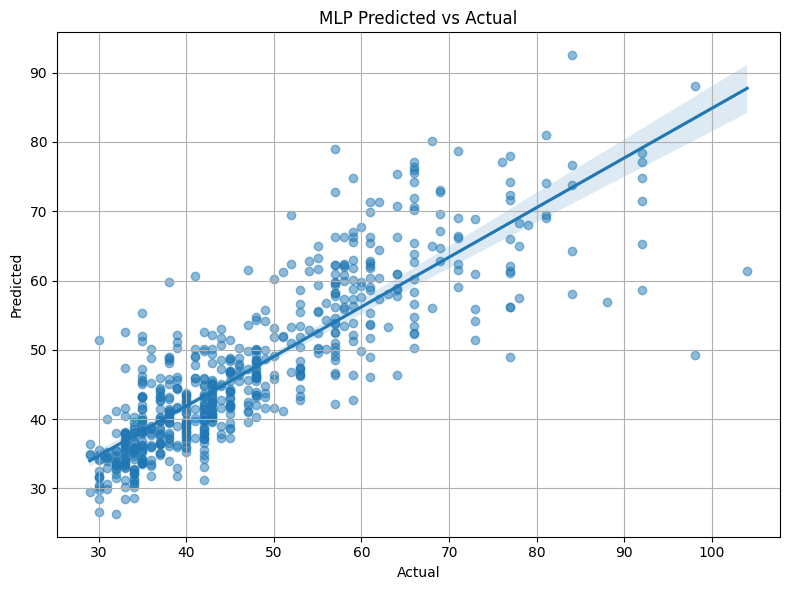

In [100]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

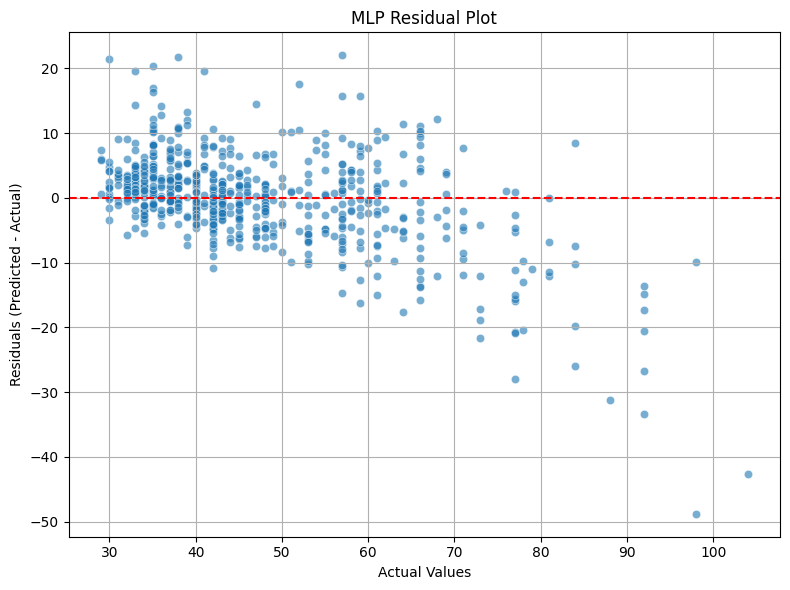

In [101]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only location

In [41]:
snps_loc= fs_data.drop(['BBD', 'LL', 'LW', 'PLH', 'VBN'], axis=1)
snps_loc.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,Chr20_42855517,Chr20_42859801,Chr20_42934531,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,0,2,2,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
s100,0,1,0,2,2,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
s100,0,1,0,2,2,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,0,1,0,0,0,0,0,1
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,0,0,1,0,0,0,0,1


In [42]:
snps_loc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 202 entries, Chr1_1539926 to landrace
dtypes: int64(202)
memory usage: 3.9+ MB


In [43]:
snps_loc_dupe= fs_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
snps_loc_dupe.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,Chr20_42855517,Chr20_42859801,Chr20_42934531,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,0,2,2,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,1
s100,0,1,0,2,2,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,1
s100,0,1,0,2,2,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,1
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,0,1,0,0,0,0,0,1
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,0,0,1,0,0,0,0,1


In [44]:
y_all = fs_data["BBD"].values

In [45]:
X_tensor = torch.tensor(snps_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all, dtype=torch.float32).reshape(-1, 1).to(device)

In [46]:
print(X_tensor.shape)

torch.Size([2536, 202])


In [48]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [49]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-23 13:59:22,177] A new study created in memory with name: no-name-33240577-ee2b-4ab7-aa80-2ba33e3471b5
[I 2025-05-23 13:59:24,191] Trial 0 finished with value: 125.64573669433594 and parameters: {'hidden_size1': 125, 'hidden_size2': 75, 'dropout1': 0.016856670306468882, 'lr': 0.0033052887621417503, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 15, 'weight_decay': 8.049139333980933e-05}. Best is trial 0 with value: 125.64573669433594.
[I 2025-05-23 13:59:25,765] Trial 1 finished with value: 43.09809112548828 and parameters: {'hidden_size1': 150, 'hidden_size2': 75, 'dropout1': 0.057755659925324096, 'lr': 0.005092208982846219, 'batch_size': 128, 'optimizer': 'Adam', 'num_epochs': 50, 'patience': 14, 'weight_decay': 2.2268463003181575e-05}. Best is trial 1 with value: 43.09809112548828.
[I 2025-05-23 13:59:27,742] Trial 2 finished with value: 37.155311584472656 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.08581148864005161, 'lr'

Early stopping at epoch 63


[I 2025-05-23 13:59:28,220] Trial 3 finished with value: 103.280029296875 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.0824594085280411, 'lr': 0.006994572183358351, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 9, 'weight_decay': 6.640991199202933e-05}. Best is trial 2 with value: 37.155311584472656.


Early stopping at epoch 16


[I 2025-05-23 13:59:28,906] Trial 4 finished with value: 68.94380187988281 and parameters: {'hidden_size1': 150, 'hidden_size2': 75, 'dropout1': 0.08468322574810723, 'lr': 0.0027113881185319884, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 6, 'weight_decay': 0.0014440416169004772}. Best is trial 2 with value: 37.155311584472656.


...

Early stopping at epoch 69


[I 2025-05-23 14:01:51,687] Trial 44 finished with value: 48.93871307373047 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.07175785796521081, 'lr': 0.0002933706830672811, 'batch_size': 128, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 6, 'weight_decay': 3.214783021609433e-05}. Best is trial 37 with value: 33.70613098144531.
[I 2025-05-23 14:01:57,823] Trial 45 finished with value: 37.47743225097656 and parameters: {'hidden_size1': 100, 'hidden_size2': 25, 'dropout1': 0.06953315403659396, 'lr': 0.00022569799162519647, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 6, 'weight_decay': 6.187132436886245e-05}. Best is trial 37 with value: 33.70613098144531.
[I 2025-05-23 14:02:03,686] Trial 46 finished with value: 1791.0308837890625 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.06080375272599502, 'lr': 0.00018148962212138572, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 5, 'weight_dec

Early stopping at epoch 36


[I 2025-05-23 14:02:11,510] Trial 49 finished with value: 2044.3697509765625 and parameters: {'hidden_size1': 125, 'hidden_size2': 50, 'dropout1': 0.044211750983973154, 'lr': 0.00047797077391736697, 'batch_size': 128, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 5, 'weight_decay': 3.5565661259594006e-05}. Best is trial 37 with value: 33.70613098144531.


Best hyperparameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.0539210053956559, 'lr': 0.00025265232602165864, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 70, 'patience': 6, 'weight_decay': 1.8442636310005575e-05}


In [50]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='enet_onlyloc_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 60 for fold 1
Fold 1 validation loss: 37.4615
Training fold 2
Fold 2 validation loss: 37.6409
Training fold 3
Fold 3 validation loss: 45.8007
Training fold 4
Early stopping at epoch 69 for fold 4
Fold 4 validation loss: 54.3601
Training fold 5
Fold 5 validation loss: 39.6900
Training fold 6
Early stopping at epoch 69 for fold 6
Fold 6 validation loss: 45.3327
Training fold 7
Early stopping at epoch 59 for fold 7
Fold 7 validation loss: 56.7599
Training fold 8
Fold 8 validation loss: 35.1465
Training fold 9
Early stopping at epoch 46 for fold 9
Fold 9 validation loss: 48.5071
Training fold 10
Fold 10 validation loss: 42.3556

Average validation loss across all folds: 44.3055
Checkpoint saved as 'enet_onlyloc_mlp_bbd.pth'.


In [51]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [52]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [53]:
# Ensure both trainjg and holdout datasets have the same columns
snps_loc_dupe, X_holdout = snps_loc_dupe.align(X_holdout, join='inner', axis=1)

In [54]:
X_holdout.info()

<class 'pandas.core.frame.DataFrame'>
Index: 634 entries, s1014 to s98
Columns: 202 entries, Chr1_1539926 to landrace
dtypes: int64(202)
memory usage: 1005.5+ KB


In [55]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [57]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 54.7958
RMSE: 7.4024
MAE: 4.9927
R2: 0.7152
Holdout_Loss: 54.7958


In [58]:
pickle.dump(best_mlp_model, open("enet_onlyloc_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 45 44.22764
1 39 50.718475
2 62 68.00591
3 47 50.46631
4 42 39.35858
5 40 44.134174


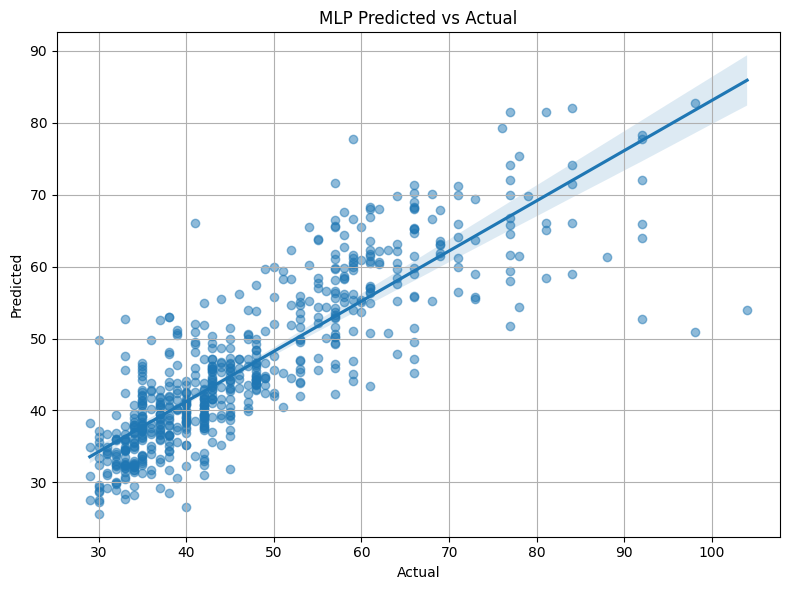

In [59]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

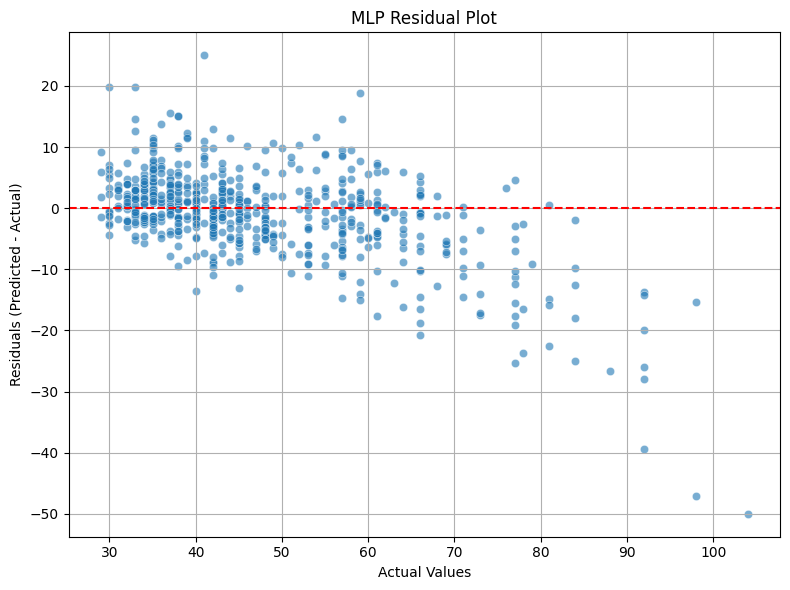

In [60]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

### Only SNPs

In [61]:
fs_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 207 entries, Chr1_1539926 to BBD
dtypes: float64(4), int64(203)
memory usage: 4.0+ MB


In [66]:
X_snps = fs_data.iloc[:, 0:195]
X_snps.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,Chr19_48727283,Chr19_50186921,Chr19_51600918,Chr20_2145196,Chr20_16221209,Chr20_40195415,Chr20_42765511,Chr20_42855517,Chr20_42859801,Chr20_42934531
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s100,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s100,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,2,2,0,0,0,0,0,0
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,2,2,0,0,0,0,0,0


In [67]:
X_snps_dupe = fs_data.iloc[:, 0:195]
X_snps_dupe.head()

,Chr1_1539926,Chr1_50820261,Chr1_57654800,Chr2_1645814,Chr2_2820871,Chr2_5531677,Chr2_6609281,Chr2_11827558,Chr2_12080089,Chr2_12189925,...,Chr19_48727283,Chr19_50186921,Chr19_51600918,Chr20_2145196,Chr20_16221209,Chr20_40195415,Chr20_42765511,Chr20_42855517,Chr20_42859801,Chr20_42934531
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s100,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s100,0,1,0,2,2,0,0,0,0,0,...,0,2,2,2,2,0,0,0,0,0
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,2,2,0,0,0,0,0,0
s1014,2,2,0,0,2,0,2,0,2,0,...,0,0,2,2,0,0,0,0,0,0


In [69]:
y_all = fs_data.iloc[:, 206:]
y_all.head()

,BBD
Line,
s100,61
s100,37
s100,43
s1014,77
s1014,42


In [70]:
X_tensor = torch.tensor(X_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_all.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [71]:
print(X_tensor.shape)

torch.Size([2536, 195])


In [72]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [73]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-23 14:08:30,085] A new study created in memory with name: no-name-c0089830-d2b2-4092-a0e1-6a666d8bf672
[I 2025-05-23 14:08:32,624] Trial 0 finished with value: 127.33857727050781 and parameters: {'hidden_size1': 100, 'hidden_size2': 50, 'dropout1': 0.016079341351649193, 'lr': 0.00018000437524825157, 'batch_size': 32, 'optimizer': 'RMSprop', 'num_epochs': 30, 'patience': 10, 'weight_decay': 5.7204488122220334e-05}. Best is trial 0 with value: 127.33857727050781.


Early stopping at epoch 29


[I 2025-05-23 14:08:34,974] Trial 1 finished with value: 1477.3236083984375 and parameters: {'hidden_size1': 125, 'hidden_size2': 50, 'dropout1': 0.05714261194206836, 'lr': 0.0006577479077913612, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 50, 'patience': 11, 'weight_decay': 2.7630207022825614e-05}. Best is trial 0 with value: 127.33857727050781.
[I 2025-05-23 14:08:37,591] Trial 2 finished with value: 127.43463897705078 and parameters: {'hidden_size1': 125, 'hidden_size2': 25, 'dropout1': 0.025437007991193403, 'lr': 0.00017411989332098932, 'batch_size': 32, 'optimizer': 'Adam', 'num_epochs': 30, 'patience': 5, 'weight_decay': 0.0013093677894301643}. Best is trial 0 with value: 127.33857727050781.


Early stopping at epoch 28


[I 2025-05-23 14:08:42,174] Trial 3 finished with value: 127.04081726074219 and parameters: {'hidden_size1': 125, 'hidden_size2': 75, 'dropout1': 0.08299923398480039, 'lr': 0.0046643808561049735, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 11, 'weight_decay': 1.1466582479146654e-05}. Best is trial 3 with value: 127.04081726074219.


...

Early stopping at epoch 48


[I 2025-05-23 14:11:02,676] Trial 47 finished with value: 126.72645568847656 and parameters: {'hidden_size1': 125, 'hidden_size2': 50, 'dropout1': 0.09588578886924809, 'lr': 0.004066701475886176, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 5, 'weight_decay': 0.00971345329303128}. Best is trial 22 with value: 125.73344421386719.
[I 2025-05-23 14:11:04,489] Trial 48 finished with value: 126.85966491699219 and parameters: {'hidden_size1': 125, 'hidden_size2': 75, 'dropout1': 0.08170874070990304, 'lr': 0.009836553030218855, 'batch_size': 64, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 8, 'weight_decay': 9.414123585095744e-05}. Best is trial 22 with value: 125.73344421386719.


Early stopping at epoch 38


[I 2025-05-23 14:11:08,331] Trial 49 finished with value: 125.83586120605469 and parameters: {'hidden_size1': 100, 'hidden_size2': 25, 'dropout1': 0.09054616369065115, 'lr': 0.005064080500961984, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 9, 'weight_decay': 6.107609740100406e-05}. Best is trial 22 with value: 125.73344421386719.


Early stopping at epoch 46
Best hyperparameters: {'hidden_size1': 125, 'hidden_size2': 75, 'dropout1': 0.07475013156185326, 'lr': 0.0029491654163181875, 'batch_size': 32, 'optimizer': 'SGD', 'num_epochs': 70, 'patience': 7, 'weight_decay': 0.0001945724646310582}


In [74]:
# 5. Rebuild the final best model and crossvalidate
best_params = study.best_params
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='enet_onlysnps_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 14 for fold 1
Fold 1 validation loss: 127.9641
Training fold 2
Early stopping at epoch 11 for fold 2
Fold 2 validation loss: 134.3717
Training fold 3
Early stopping at epoch 13 for fold 3
Fold 3 validation loss: 131.7597
Training fold 4
Early stopping at epoch 22 for fold 4
Fold 4 validation loss: 157.7282
Training fold 5
Early stopping at epoch 20 for fold 5
Fold 5 validation loss: 128.7814
Training fold 6
Early stopping at epoch 18 for fold 6
Fold 6 validation loss: 124.8563
Training fold 7
Early stopping at epoch 13 for fold 7
Fold 7 validation loss: 167.4651
Training fold 8
Early stopping at epoch 27 for fold 8
Fold 8 validation loss: 114.9655
Training fold 9
Early stopping at epoch 25 for fold 9
Fold 9 validation loss: 118.7024
Training fold 10
Early stopping at epoch 16 for fold 10
Fold 10 validation loss: 149.7407

Average validation loss across all folds: 135.6335
Checkpoint saved as 'enet_onlysnps_mlp_bbd.pth'.


In [75]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [76]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [77]:
# Ensure both trainjg and holdout datasets have the same columns
X_snps_dupe, X_holdout = X_snps_dupe.align(X_holdout, join='inner', axis=1)

In [78]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [79]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 190.1497
RMSE: 13.7895
MAE: 10.7029
R2: 0.0116
Holdout_Loss: 190.1497


In [80]:
pickle.dump(best_mlp_model, open("enet_onlysnps_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

# XGBoost

In [9]:
tt_data = pd.read_pickle("fs_bbd_xgboost_training_data.pkl")
tt_data.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,154.700,5.66667,1,0,0,0,0,0,1,61
s100,0,0,1,0,0,0,0,0,0,0,...,130.000,1.80000,0,1,0,0,0,0,1,37
s100,0,0,1,0,0,0,0,0,0,0,...,116.000,3.40000,0,0,1,0,0,0,1,43
s1014,0,0,2,0,2,0,0,0,0,0,...,111.733,8.66667,1,0,0,0,0,0,1,77
s1014,0,0,2,0,2,0,0,0,0,0,...,73.000,2.60000,0,1,0,0,0,0,1,42


## All covariates

In [39]:
tt_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2536 entries, s100 to s99
Columns: 1012 entries, Chr2_12189925 to BBD
dtypes: float64(4), int64(1008)
memory usage: 19.6+ MB


In [40]:
tt_y = tt_data.iloc[:, 1011:]
tt_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s1014,77
s1014,42


In [41]:
tt_all= tt_data.drop(['BBD'], axis=1)
tt_all.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,7.78667,73.000,2.60000,0,1,0,0,0,0,1


In [42]:
tt_all_dupe= tt_data.drop(['BBD'], axis=1)
tt_all_dupe.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,6.26667,154.700,5.66667,1,0,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,7.19333,130.000,1.80000,0,1,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,4.00000,116.000,3.40000,0,0,1,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,7.76667,111.733,8.66667,1,0,0,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,7.78667,73.000,2.60000,0,1,0,0,0,0,1


In [43]:
X_tensor = torch.tensor(tt_all.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(tt_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [44]:
print(X_tensor.shape)

torch.Size([2536, 1011])


In [45]:
# Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [46]:
#Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-29 12:56:34,546] A new study created in memory with name: no-name-009955ff-25c1-401d-a8fc-dc366125fcbb
[I 2025-05-29 12:56:37,656] Trial 0 finished with value: 54.08932876586914 and parameters: {'hidden_size1': 100, 'dropout1': 0.030465258438040245, 'lr': 0.007509982477612428, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 1.082211330938127e-05, 'n_layers': 1}. Best is trial 0 with value: 54.08932876586914.


Early stopping at epoch 37


[I 2025-05-29 12:56:41,091] Trial 1 finished with value: 48.97298812866211 and parameters: {'hidden_size1': 200, 'dropout1': 0.07081748944164659, 'lr': 0.0017305994646466005, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.00010850563001058281, 'n_layers': 1}. Best is trial 1 with value: 48.97298812866211.


Early stopping at epoch 41


[I 2025-05-29 12:56:44,270] Trial 2 finished with value: 70.31307220458984 and parameters: {'hidden_size1': 100, 'dropout1': 0.045167148208930495, 'lr': 0.004826072971141898, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 2.8387939301794237e-05, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout2': 0.08777656564015733}. Best is trial 1 with value: 48.97298812866211.


...

Early stopping at epoch 52


[I 2025-05-29 13:00:01,537] Trial 47 finished with value: 48.1910285949707 and parameters: {'hidden_size1': 300, 'dropout1': 0.04852941524810944, 'lr': 0.0001965705043716498, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 0.0032729835494359682, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 27 with value: 43.65640640258789.
[I 2025-05-29 13:00:04,566] Trial 48 finished with value: 50.83025360107422 and parameters: {'hidden_size1': 200, 'dropout1': 0.06195117868531537, 'lr': 0.0006715238558525212, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0018465417373422196, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout2': 0.010464880644849451}. Best is trial 27 with value: 43.65640640258789.


Early stopping at epoch 50


[I 2025-05-29 13:00:14,538] Trial 49 finished with value: 90.26383209228516 and parameters: {'hidden_size1': 300, 'dropout1': 0.08789615460082702, 'lr': 0.0020977932025879184, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.005693854406085323, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 75, 'dropout2': 0.06853174122937672}. Best is trial 27 with value: 43.65640640258789.


Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.07789898197234837, 'lr': 0.0002620246252091033, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0010263359608432378, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 25, 'dropout2': 0.010838486306316897}


In [47]:
#Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='xgboost_allfeats_mlp_bbd_test.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 80 for fold 1
Fold 1 validation loss: 43.1425
Training fold 2
Early stopping at epoch 86 for fold 2
Fold 2 validation loss: 52.7951
Training fold 3
Early stopping at epoch 88 for fold 3
Fold 3 validation loss: 46.6831
Training fold 4
Early stopping at epoch 87 for fold 4
Fold 4 validation loss: 71.4075
Training fold 5
Early stopping at epoch 63 for fold 5
Fold 5 validation loss: 57.6573
Training fold 6
Early stopping at epoch 97 for fold 6
Fold 6 validation loss: 55.0399
Training fold 7
Fold 7 validation loss: 72.6180
Training fold 8
Early stopping at epoch 89 for fold 8
Fold 8 validation loss: 44.5216
Training fold 9
Early stopping at epoch 77 for fold 9
Fold 9 validation loss: 58.5249
Training fold 10
Early stopping at epoch 59 for fold 10
Fold 10 validation loss: 47.0697

Average validation loss across all folds: 54.9460
Checkpoint saved as 'xgboost_allfeats_mlp_bbd_test.pth'.


In [48]:
best_mlp_model

Sequential(
  (0): Linear(in_features=1011, out_features=300, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.07789898197234837, inplace=False)
  (3): Linear(in_features=300, out_features=150, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.010838486306316897, inplace=False)
  (6): Linear(in_features=150, out_features=25, bias=True)
  (7): ReLU()
  (8): Linear(in_features=25, out_features=1, bias=True)
)

In [49]:
print("Best hyperparameters found by Optuna:")
for key, value in best_params.items():
    print(f"{key}: {value}")

Best hyperparameters found by Optuna:
hidden_size1: 300
dropout1: 0.07789898197234837
lr: 0.0002620246252091033
batch_size: 64
optimizer: Adam
weight_decay: 0.0010263359608432378
n_layers: 3
hidden_size2: 150
hidden_size3: 25
dropout2: 0.010838486306316897
num_epochs: 100
patience: 10


In [50]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [51]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [52]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [53]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [54]:
# Ensure both trainjg and holdout datasets have the same columns
tt_all_dupe, X_holdout = tt_all_dupe.align(X_holdout, join='inner', axis=1)

In [55]:
X_holdout.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,2,0,2,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,2,1,0,0,0,0,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,2,1,0,0,0,0,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,0,0,1,0,0,0,0,0,1,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,1,2,0,0,0,0,2,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [56]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [57]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 70.5065
RMSE: 8.3968
MAE: 5.6929
R2: 0.6335
Holdout_Loss: 70.5065


In [37]:
pickle.dump(best_mlp_model, open("xgboost_allfeats_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 45 44.45566
1 39 51.22125
2 62 67.95807
3 47 65.25396
4 42 45.60777
5 40 34.10341


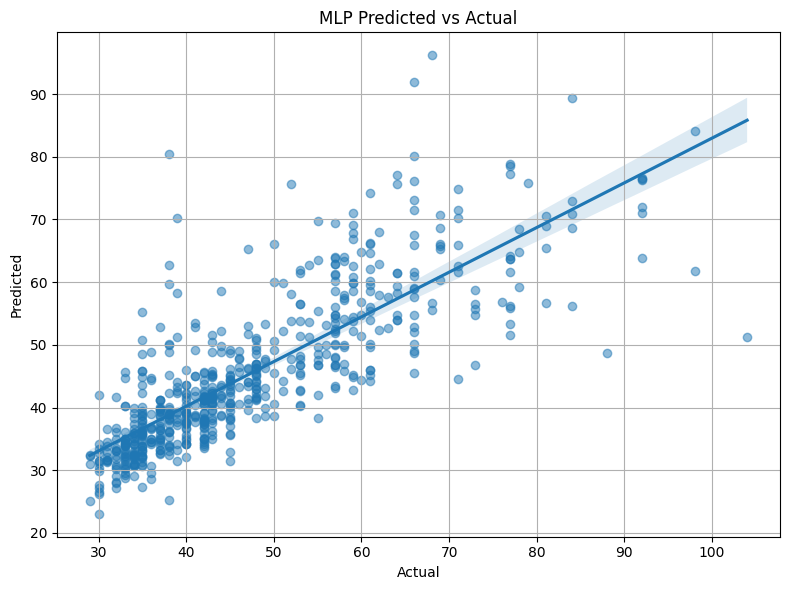

In [58]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

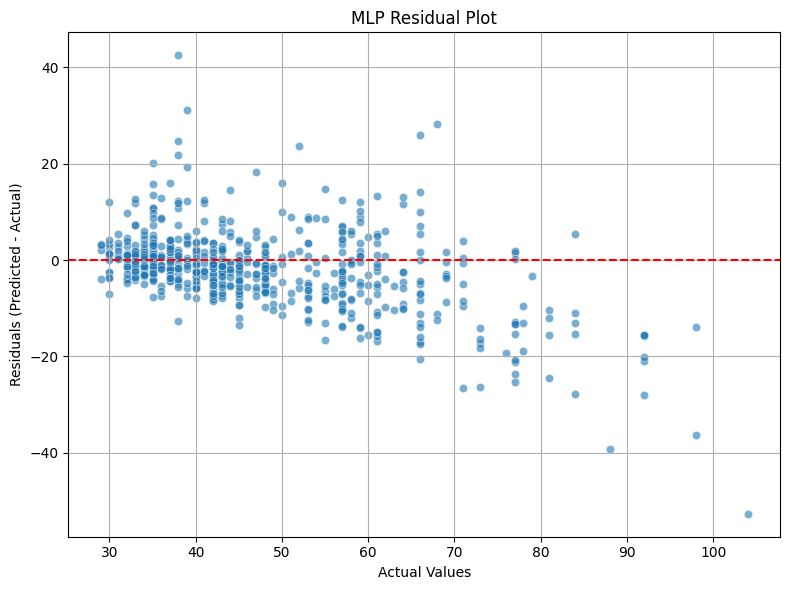

In [59]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

## Only location

In [63]:
tt_loc= tt_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
tt_loc.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,Chr18_26757646,Chr15_27699994,Chr16_11070224,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,0,0,2,1,0,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,0,0,2,0,1,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,0,0,2,0,0,1,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,0,2,2,1,0,0,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,0,2,2,0,1,0,0,0,0,1


In [64]:
tt_loc_dupe= tt_data.drop(['BBD', 'LL',	'LW',	'PLH', 'VBN'], axis=1)
tt_loc_dupe.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,Chr18_26757646,Chr15_27699994,Chr16_11070224,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,0,0,2,1,0,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,0,0,2,0,1,0,0,0,0,1
s100,0,0,1,0,0,0,0,0,0,0,...,0,0,2,0,0,1,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,0,2,2,1,0,0,0,0,0,1
s1014,0,0,2,0,2,0,0,0,0,0,...,0,2,2,0,1,0,0,0,0,1


In [65]:
tt_y = tt_data.iloc[:, 1011:]
tt_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s1014,77
s1014,42


In [67]:
X_tensor = torch.tensor(tt_loc.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(tt_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [68]:
print(X_tensor.shape)

torch.Size([2536, 1007])


In [69]:
#Split your data into train and validation sets for hyperparamter tuning
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [70]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-29 13:08:14,218] A new study created in memory with name: no-name-546ae7f9-4b6b-4cb5-9722-61d4cf378f55
[I 2025-05-29 13:08:17,559] Trial 0 finished with value: 53.963565826416016 and parameters: {'hidden_size1': 300, 'dropout1': 0.03466371972585915, 'lr': 0.0035734736882765007, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 5.716914238954178e-05, 'n_layers': 1}. Best is trial 0 with value: 53.963565826416016.


Early stopping at epoch 40


[I 2025-05-29 13:08:21,697] Trial 1 finished with value: 59.56887435913086 and parameters: {'hidden_size1': 200, 'dropout1': 0.07571989177778955, 'lr': 0.0005554206677824726, 'batch_size': 64, 'optimizer': 'RMSprop', 'weight_decay': 6.907766023100396e-05, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 53.963565826416016.


Early stopping at epoch 83


[I 2025-05-29 13:08:25,928] Trial 2 finished with value: 100.89505004882812 and parameters: {'hidden_size1': 300, 'dropout1': 0.012173437040851116, 'lr': 0.007808758524068963, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.00273441664690506, 'n_layers': 1}. Best is trial 0 with value: 53.963565826416016.
[I 2025-05-29 13:08:29,488] Trial 3 finished with value: 44.80982208251953 and parameters: {'hidden_size1': 300, 'dropout1': 0.08600174647459805, 'lr': 0.0002242736423829182, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 9.602883876451108e-05, 'n_layers': 3, 'hidden_size2': 100, 'hidden_size3': 50, 'dropout2': 0.02310069489724104}. Best is trial 3 with value: 44.80982208251953.
[I 2025-05-29 13:08:34,931] Trial 4 finished with value: 44.427059173583984 and parameters: {'hidden_size1': 300, 'dropout1': 0.0831882365370799, 'lr': 0.00032070050263111825, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 1.465591838954662e-05, 'n_layers': 3, 'hidden_size2': 150, 'hid

...

Early stopping at epoch 79


[I 2025-05-29 13:12:42,909] Trial 48 finished with value: 43.176029205322266 and parameters: {'hidden_size1': 200, 'dropout1': 0.07723470184925552, 'lr': 0.0002061998511229705, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 1.0955187311764616e-05, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 33 with value: 38.74674606323242.


Early stopping at epoch 76


[I 2025-05-29 13:12:49,071] Trial 49 finished with value: 44.02779769897461 and parameters: {'hidden_size1': 200, 'dropout1': 0.06469751162134152, 'lr': 0.0005871651053153118, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 0.0001328788652917479, 'n_layers': 1}. Best is trial 33 with value: 38.74674606323242.


Early stopping at epoch 74
Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.0748192111853964, 'lr': 0.00030145172661593447, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 8.821984212323114e-05, 'n_layers': 3, 'hidden_size2': 50, 'hidden_size3': 50, 'dropout2': 0.023400840512229928}


In [71]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='xgboost_onlyloc_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 47 for fold 1
Fold 1 validation loss: 42.3225
Training fold 2
Early stopping at epoch 86 for fold 2
Fold 2 validation loss: 36.0226
Training fold 3
Early stopping at epoch 69 for fold 3
Fold 3 validation loss: 40.3298
Training fold 4
Early stopping at epoch 67 for fold 4
Fold 4 validation loss: 67.1792
Training fold 5
Early stopping at epoch 81 for fold 5
Fold 5 validation loss: 44.6981
Training fold 6
Early stopping at epoch 60 for fold 6
Fold 6 validation loss: 50.6870
Training fold 7
Early stopping at epoch 59 for fold 7
Fold 7 validation loss: 65.3088
Training fold 8
Early stopping at epoch 69 for fold 8
Fold 8 validation loss: 37.7168
Training fold 9
Early stopping at epoch 61 for fold 9
Fold 9 validation loss: 58.9434
Training fold 10
Early stopping at epoch 65 for fold 10
Fold 10 validation loss: 38.0811

Average validation loss across all folds: 48.1289
Checkpoint saved as 'xgboost_onlyloc_mlp_bbd.pth'.


In [72]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data.head()

,Line,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
new_line,,,,,,,,,,,,,,,,,,,,,
s1014_HeNan_2015,s1014,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101_BeiJing_2013,s101,0,0,1,0,0,1,1,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101_HeiLongJiang_2014,s101,0,0,1,0,0,1,1,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026_HeiLongJiang_2015,s1026,2,0,1,0,0,0,1,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030_HeNan_2014,s1030,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [73]:
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [74]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [75]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [76]:
# Ensure both trainjg and holdout datasets have the same columns
tt_loc, X_holdout = tt_loc_dupe.align(X_holdout, join='inner', axis=1)

In [77]:
X_holdout.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,Chr18_26757646,Chr15_27699994,Chr16_11070224,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,2,0,2,0,0,0,0,0,...,0,2,2,0,0,1,0,0,0,1
s101,0,2,1,0,0,0,0,0,0,0,...,0,0,2,1,0,0,0,0,0,1
s101,0,2,1,0,0,0,0,0,0,0,...,0,0,2,0,0,0,1,0,0,1
s1026,0,0,1,0,0,0,0,0,1,0,...,0,0,2,0,0,0,0,1,0,1
s1030,0,0,1,2,0,0,0,0,2,0,...,0,0,0,0,1,0,0,0,0,1


In [78]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [79]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 59.2996
RMSE: 7.7006
MAE: 5.1933
R2: 0.6918
Holdout_Loss: 59.2996


In [80]:
pickle.dump(best_mlp_model, open("xgboost_onlyloc_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set

0 45 47.949837
1 39 56.803417
2 62 77.18655
3 47 55.762512
4 42 42.83668
5 40 45.36219


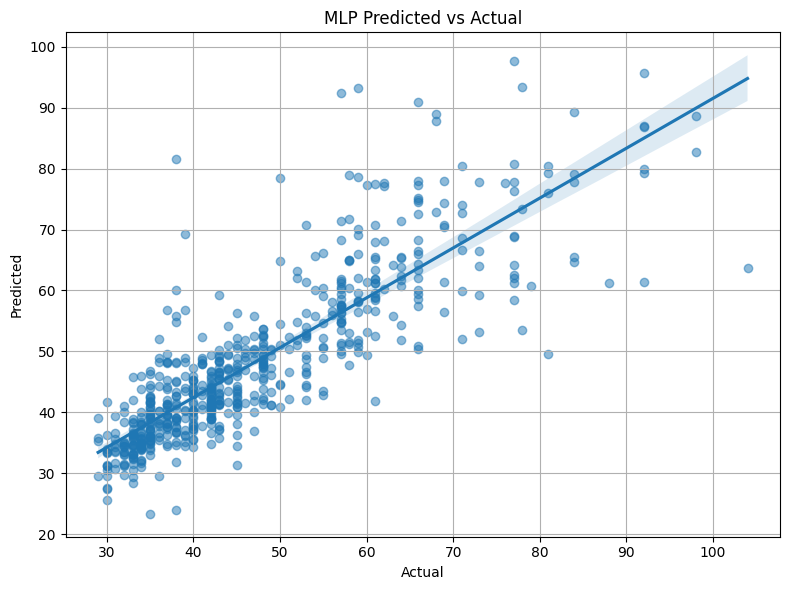

In [81]:
# Flatten y_holdout and predictions
y_holdout = y_holdout.ravel()
mlp_preds = predictions.cpu().numpy().ravel()  # if predictions is a torch tensor

# Prepare data for plot
plot_x, plot_y = [], []

for counter, actual in enumerate(y_holdout):
    if counter <= 5:  # Print first 5 examples
        print(counter, actual, mlp_preds[counter])
    if mlp_preds[counter] > 1:
        plot_x.append(actual)
        plot_y.append(mlp_preds[counter])

# Create DataFrame for plotting
plot_df = pd.DataFrame({'actual': plot_x, 'predicted': plot_y})

# Plot
plt.figure(figsize=(8, 6))
sns.regplot(x="actual", y="predicted", data=plot_df, scatter_kws={'alpha': 0.5})
plt.title('MLP Predicted vs Actual')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True)
plt.tight_layout()
plt.show()

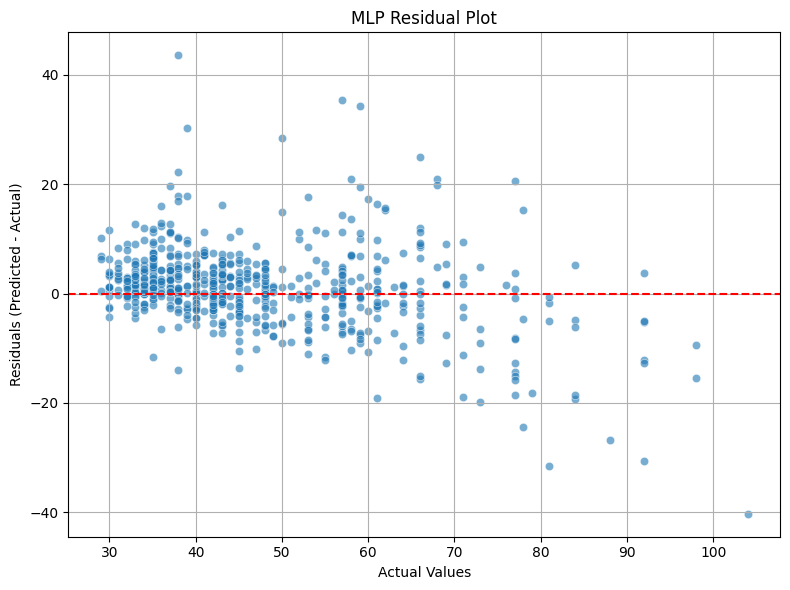

In [82]:
# Convert lists to numpy arrays
actual = np.array(plot_x)
predicted = np.array(plot_y)

# Compute residuals
residuals = predicted - actual

# Plot residuals
plt.figure(figsize=(8, 6))
sns.scatterplot(x=actual, y=residuals, alpha=0.6)

# Add a horizontal line at y = 0
plt.axhline(y=0, color='red', linestyle='--')

# Add labels and title
plt.xlabel("Actual Values")
plt.ylabel("Residuals (Predicted - Actual)")
plt.title("MLP Residual Plot")

plt.grid(True)
plt.tight_layout()
plt.show()

## Only SNPs

In [10]:
tt_snps = tt_data.iloc[:, 0:1000]
tt_snps.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,Chr18_25050552,Chr19_5385197,Chr5_20019218,Chr1_1875859,Chr7_30016631,Chr18_54729653,Chr5_31526068,Chr18_26757646,Chr15_27699994,Chr16_11070224
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s100,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s100,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s1014,0,0,2,0,2,0,0,0,0,0,...,0,0,0,2,0,0,0,0,2,2
s1014,0,0,2,0,2,0,0,0,0,0,...,0,0,0,2,0,0,0,0,2,2


In [11]:
tt_snps_dupe = tt_data.iloc[:, 0:1000]
tt_snps_dupe.head()

,Chr2_12189925,Chr2_12050481,Chr15_49431637,Chr16_31795219,Chr9_47292800,Chr11_32206331,Chr13_31137465,Chr16_37299582,Chr3_5964319,Chr10_47470748,...,Chr18_25050552,Chr19_5385197,Chr5_20019218,Chr1_1875859,Chr7_30016631,Chr18_54729653,Chr5_31526068,Chr18_26757646,Chr15_27699994,Chr16_11070224
Line,,,,,,,,,,,,,,,,,,,,,
s100,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s100,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s100,0,0,1,0,0,0,0,0,0,0,...,0,1,0,2,1,0,0,0,0,2
s1014,0,0,2,0,2,0,0,0,0,0,...,0,0,0,2,0,0,0,0,2,2
s1014,0,0,2,0,2,0,0,0,0,0,...,0,0,0,2,0,0,0,0,2,2


In [12]:
tt_y = tt_data.iloc[:, 1011:]
tt_y.head()

,BBD
Line,
s100,61
s100,37
s100,43
s1014,77
s1014,42


In [13]:
X_tensor = torch.tensor(tt_snps.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(tt_y.values, dtype=torch.float32).reshape(-1, 1).to(device)

In [14]:
print(X_tensor.shape)

torch.Size([2536, 1000])


In [15]:
X_train, X_val, y_train, y_val = train_test_split(X_tensor, y_tensor, test_size=0.1, random_state=42)

In [16]:
# Create Optuna study
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)  # Try n different combinations

# 4. Print the best hyperparameters
print("Best hyperparameters:", study.best_params)

[I 2025-05-29 18:15:10,799] A new study created in memory with name: no-name-bdbe19dd-9667-433e-9330-c5e9b46883b7
[I 2025-05-29 18:15:13,873] Trial 0 finished with value: 144.8275146484375 and parameters: {'hidden_size1': 100, 'dropout1': 0.06999597960396893, 'lr': 0.00039282747271456763, 'batch_size': 128, 'optimizer': 'Adam', 'weight_decay': 1.0377656475068512e-05, 'n_layers': 1}. Best is trial 0 with value: 144.8275146484375.


Early stopping at epoch 33


[I 2025-05-29 18:15:15,050] Trial 1 finished with value: 155.54750061035156 and parameters: {'hidden_size1': 200, 'dropout1': 0.029345199816021628, 'lr': 0.0016918685050116718, 'batch_size': 32, 'optimizer': 'RMSprop', 'weight_decay': 0.0008628266742444896, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 0 with value: 144.8275146484375.


Early stopping at epoch 13


[I 2025-05-29 18:15:20,521] Trial 2 finished with value: 1767.89208984375 and parameters: {'hidden_size1': 300, 'dropout1': 0.0874869972469543, 'lr': 0.00032027579827968706, 'batch_size': 64, 'optimizer': 'SGD', 'weight_decay': 0.002488597567948535, 'n_layers': 3, 'hidden_size2': 150, 'hidden_size3': 50, 'dropout2': 0.018289335701912768}. Best is trial 0 with value: 144.8275146484375.
[I 2025-05-29 18:15:21,272] Trial 3 finished with value: 158.87750244140625 and parameters: {'hidden_size1': 300, 'dropout1': 0.08477187352677858, 'lr': 0.0027793053272401405, 'batch_size': 64, 'optimizer': 'Adam', 'weight_decay': 0.0006520195528819978, 'n_layers': 1}. Best is trial 0 with value: 144.8275146484375.


...

Early stopping at epoch 22


[I 2025-05-29 18:18:34,431] Trial 48 finished with value: 154.9106903076172 and parameters: {'hidden_size1': 300, 'dropout1': 0.03548789133277584, 'lr': 0.0013233458576878017, 'batch_size': 32, 'optimizer': 'Adam', 'weight_decay': 7.955181565439535e-05, 'n_layers': 2, 'hidden_size2': 50}. Best is trial 24 with value: 138.1167449951172.


Early stopping at epoch 11


[I 2025-05-29 18:18:36,833] Trial 49 finished with value: 138.20272827148438 and parameters: {'hidden_size1': 300, 'dropout1': 0.08096032800890704, 'lr': 0.007915699590692556, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 1.3874035094105049e-05, 'n_layers': 2, 'hidden_size2': 150}. Best is trial 24 with value: 138.1167449951172.


Early stopping at epoch 28
Best hyperparameters: {'hidden_size1': 300, 'dropout1': 0.03653996844308448, 'lr': 0.009998008558309056, 'batch_size': 32, 'optimizer': 'SGD', 'weight_decay': 0.0017878101015117913, 'n_layers': 2, 'hidden_size2': 50}


In [17]:
# 5. Rebuild the final best model and crossvalidate
best_params = complete_params(study.best_params)
#def cross_validate(X, y, num_epochs, n_splits, batch_size,checkpoint_path)
best_mlp_model, average_loss = cross_validate(X_tensor, y_tensor, best_params, 10, checkpoint_path='xgboost_onlysnps_mlp_bbd.pth') # add the epochs and batch from best parameters

Training fold 1
Early stopping at epoch 12 for fold 1
Fold 1 validation loss: 138.2663
Training fold 2
Early stopping at epoch 12 for fold 2
Fold 2 validation loss: 140.3301
Training fold 3
Early stopping at epoch 13 for fold 3
Fold 3 validation loss: 124.2335
Training fold 4
Early stopping at epoch 15 for fold 4
Fold 4 validation loss: 160.9316
Training fold 5
Early stopping at epoch 12 for fold 5
Fold 5 validation loss: 132.6416
Training fold 6
Early stopping at epoch 15 for fold 6
Fold 6 validation loss: 151.1387
Training fold 7
Early stopping at epoch 11 for fold 7
Fold 7 validation loss: 176.8531
Training fold 8
Early stopping at epoch 13 for fold 8
Fold 8 validation loss: 131.9930
Training fold 9
Early stopping at epoch 15 for fold 9
Fold 9 validation loss: 139.8074
Training fold 10
Early stopping at epoch 13 for fold 10
Fold 10 validation loss: 157.9532

Average validation loss across all folds: 145.4148
Checkpoint saved as 'xgboost_onlysnps_mlp_bbd.pth'.


In [18]:
holdout_data = pd.read_pickle("pickle_files/holdout_data_bbd.pkl")
holdout_data = holdout_data.set_index('Line')
holdout_data.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace,BBD
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,79.0000,3.40000,0,0,1,0,0,0,1,45
s101,0,0,1,0,0,1,1,0,0,0,...,52.7333,6.33333,1,0,0,0,0,0,1,39
s101,0,0,1,0,0,1,1,0,0,0,...,95.7000,4.20000,0,0,0,1,0,0,1,62
s1026,2,0,1,0,0,0,1,0,0,0,...,40.6000,6.66667,0,0,0,0,1,0,1,47
s1030,0,0,0,0,0,0,0,0,0,0,...,102.8000,0.00000,0,1,0,0,0,0,1,42


In [19]:
X_holdout = holdout_data.iloc[:, 0:251240]
X_holdout.head()

,Chr1_15246,Chr1_17750,Chr1_23692,Chr1_24276,Chr1_24345,Chr1_24393,Chr1_24696,Chr1_47480,Chr1_47731,Chr1_48047,...,LW,PLH,VBN,BeiJing_2013,HeNan_2014,HeNan_2015,HeiLongJiang_2014,HeiLongJiang_2015,improved_cultivar,landrace
Line,,,,,,,,,,,,,,,,,,,,,
s1014,0,0,0,0,0,0,0,0,0,0,...,6.94667,79.0000,3.40000,0,0,1,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,6.53333,52.7333,6.33333,1,0,0,0,0,0,1
s101,0,0,1,0,0,1,1,0,0,0,...,10.22000,95.7000,4.20000,0,0,0,1,0,0,1
s1026,2,0,1,0,0,0,1,0,0,0,...,8.84600,40.6000,6.66667,0,0,0,0,1,0,1
s1030,0,0,0,0,0,0,0,0,0,0,...,8.33333,102.8000,0.00000,0,1,0,0,0,0,1


In [20]:
y_holdout = holdout_data.iloc[:, 251240:]
y_holdout.head()

,BBD
Line,
s1014,45
s101,39
s101,62
s1026,47
s1030,42


In [22]:
tt_snps_dupe, X_holdout = tt_snps_dupe.align(X_holdout, join='inner', axis=1)

In [23]:
X_holdout = X_holdout.to_numpy()
y_holdout = y_holdout.to_numpy()

In [24]:
predictions, metrics = evaluate_on_holdout(X_holdout, y_holdout, best_mlp_model)


Evaluation Metrics on Holdout Set:
MSE: 208.8338
RMSE: 14.4511
MAE: 10.3647
R2: -0.0855
Holdout_Loss: 208.8338


In [25]:
pickle.dump(best_mlp_model, open("xgboost_onlysnps_mlp_bbd.pickle.dat", "wb"))
#with open("test_model.pickle.dat", "rb") as f:
#    loaded_model = pickle.load(f)
# loaded_model.eval() #move the model to eval mode and then also move to gpu before evaluating on holdout set